In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

print('Libraries loaded. Random seed fixed at', RANDOM_STATE)

Libraries loaded. Random seed fixed at 42


1  Dataset Selection

The dataset I chose

I use the diamonds dataset: 53,940 diamonds listed for sale, each described by its weight, its
three quality grades, its physical measurements and its price.

Where it comes from.
The dataset originates with the ggplot2 package for R, and the file I read here is the same
diamonds.csv used in exercise 7 of the tutorials. The package documentation describes it as the
prices and attributes of almost 54,000 diamonds, and the underlying listings are generally
reported to have been collected from an online diamond retailer's search engine around 2008.
The package itself does not name the retailer or the exact collection date, so the provenance
is well documented at the level of the variables and only loosely documented at the level of
the original source. That uncertainty is itself a limitation and I return to it below.

Why it was collected.
It was assembled as a teaching dataset. It is large enough to be realistic, it mixes continuous
measurements with ordered quality grades, and it carries a price that depends on all of them,
so it is used to demonstrate regression, visualisation and exploratory analysis. That origin
matters for me: it was not collected to answer a scientific question, so nobody had an
incentive to clean it beyond what a teaching example needs. As section 2 shows, it still
contains physically impossible records.

Who collected it.
The dataset is distributed by the ggplot2 authors (Hadley Wickham and contributors). The
listings themselves were produced by a commercial retailer, and the quality grades were
assigned by human gemmological graders, not by an instrument.

What each feature represents

Four of the ten columns are physical measurements of the stone. carat is its weight, where one
carat is 0.2 grams, and x, y and z are its length, width and depth in millimetres. Two more are
cutting proportions expressed as percentages: depth is the total depth percentage, defined as
100 * 2z / (x + y), and table is the width of the flat top facet as a percentage of the widest
point. price is the listed price in US dollars.

The remaining three are ordered quality grades assigned by a grader. cut runs Fair, Good, Very
Good, Premium, Ideal. color describes the body colour of the stone and runs from J, the most
tinted, to D, which is colourless. clarity describes the inclusions inside the stone and runs
I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF, where I1 is the most included and IF is flawless.

The three grades are genuinely ordinal, so I encode them as ranks rather than as dummy
variables. cut_rank runs 0 (Fair) to 4 (Ideal), color_rank runs 0 (J) to 6 (D) and clarity_rank
runs 0 (I1) to 7 (IF), so in every case a larger number means a better stone. This keeps the
analysis matrix numerical without inventing eight extra binary columns that would distort the
distances every method in this notebook relies on.

How the dataset meets the requirements

It has 53,940 rows (at least 1000 required), ten features after encoding (at least 8 required),
of which seven are genuinely numerical measurements and three are ordered grades, so it is
mostly numerical. It is real-world commercial data, and it carries no pre-labelled anomaly
column - nothing in the file says which diamonds are unusual. I check all of this in code below
rather than asserting it.

In [2]:
path = "C:\\Users\\idane\\PythonProjects\\diamonds.csv"
diamonds = pd.read_csv(path, index_col=0)

CUT_ORDER     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
COLOR_ORDER   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
CLARITY_ORDER = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

def load_diamonds():
    df = diamonds.copy().reset_index(drop=True)
    df['cut_rank']     = pd.Categorical(df['cut'],     CUT_ORDER,     ordered=True).codes
    df['color_rank']   = pd.Categorical(df['color'],   COLOR_ORDER,   ordered=True).codes
    df['clarity_rank'] = pd.Categorical(df['clarity'], CLARITY_ORDER, ordered=True).codes
    return df

MEASURED_FEATURES = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
GRADE_FEATURES    = ['cut_rank', 'color_rank', 'clarity_rank']
FEATURES          = MEASURED_FEATURES + GRADE_FEATURES

diamonds_df = load_diamonds()
print('Rows:', len(diamonds_df), '| columns in the raw file:', diamonds.shape[1])
print('Features used for the analysis:', len(FEATURES))
diamonds_df[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']].head()

Rows: 53940 | columns in the raw file: 10
Features used for the analysis: 10


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Checking the requirements.
This cell checks the five dataset requirements of the assignment in code rather than asserting
them in words.

In [3]:
requirement_check = pd.DataFrame([
    ('at least 1000 rows',        len(diamonds_df) >= 1000,  f'{len(diamonds_df):,} rows'),
    ('at least 8 features',       len(FEATURES) >= 8,        f'{len(FEATURES)} features'),
    ('mostly numerical',          len(MEASURED_FEATURES) > len(GRADE_FEATURES),
                                  f'{len(MEASURED_FEATURES)} measured + {len(GRADE_FEATURES)} ordered grades'),
    ('real-world dataset',        True,                      'commercial retail listings'),
    ('no pre-labelled anomaly column',
     not any(c.lower() in ('anomaly', 'outlier', 'label', 'target', 'is_fraud')
             for c in diamonds.columns),
     'columns: ' + ', '.join(diamonds.columns)),
], columns=['requirement', 'satisfied', 'evidence'])

display(requirement_check)

,requirement,satisfied,evidence
0,at least 1000 rows,True,"53,940 rows"
1,at least 8 features,True,10 features
2,mostly numerical,True,7 measured + 3 ordered grades
3,real-world dataset,True,commercial retail listings
4,no pre-labelled anomaly column,True,"columns: carat, cut, color, clarity, depth, ta..."


Possible limitations and biases in the data

I can see six limitations, and each one changes how much weight I put on the results later.

The prices are a snapshot from one seller.
They are list prices from a single retailer at a single moment around 2008, not transaction
prices and not a market average. Anything I conclude about price is a statement about that
seller's catalogue, not about the diamond market.

The price looks truncated at the top.
The maximum price is $18,823, and in section 2.3 I check the density approaching it: the counts
stay roughly flat per price band all the way to $18,800 and then stop, rather than thinning out
as a market-generated distribution would. That pattern suggests the original search returned
only stones under about $19,000. If so, the most expensive diamonds are missing entirely, and
any method that looks for anomalies in the upper price range is working on a censored sample.

The quality grades are human judgements.
Cut, colour and clarity are assigned by graders, and different laboratories are known to grade
differently. The file records no certifying body, so part of the variation in those three
columns is grader disagreement rather than a real difference between stones.

Treating the grades as evenly spaced ranks is an approximation.
When I encode clarity as 0 to 7 I am asserting that the step from I1 to SI2 is the same size as
the step from VVS1 to IF. That is almost certainly false in value terms. I accept it because
every method here needs numbers, but it means the grade columns carry more measurement error
than the millimetre measurements do.

Selection bias towards sellable stones.
Only diamonds that a retailer chose to list appear. Stones that are damaged, unusually shaped
or hard to sell are under-represented, so the dataset describes the commercial population and
not the population of diamonds.

The dataset contains real data-entry errors.
I did not know this when I chose it; I found it in section 2. Twenty stones have a physically
impossible dimension of zero, and a handful more have a measurement inflated by roughly a
factor of ten. These are a genuine limitation, and they turn out to be the most interesting
part of the anomaly detection section, because they let me ask which methods find a true error
and which ones find a merely unusual diamond.

2  Exploratory Data Analysis

2.1  Structural analysis

In [4]:
print('Rows:', diamonds_df.shape[0], ' Columns in the raw file:', diamonds.shape[1])
print('Duplicated rows:', int(diamonds_df.duplicated().sum()),
      f'({100 * diamonds_df.duplicated().mean():.3f}% of the file)')
print()

structure = pd.DataFrame({
    'dtype':        diamonds_df[FEATURES].dtypes.astype(str),
    'missing':      diamonds_df[FEATURES].isna().sum(),
    'n_unique':     diamonds_df[FEATURES].nunique(),
    'zeros':        (diamonds_df[FEATURES] == 0).sum(),
})
display(structure)
print('Total missing values in the whole table:', int(diamonds_df.isna().sum().sum()))

Rows: 53940  Columns in the raw file: 10
Duplicated rows: 146 (0.271% of the file)



,dtype,missing,n_unique,zeros
carat,float64,0,273,0
depth,float64,0,184,0
table,float64,0,127,0
price,int64,0,11602,0
x,float64,0,554,8
y,float64,0,552,7
z,float64,0,375,20
cut_rank,int8,0,5,1610
color_rank,int8,0,7,2808
clarity_rank,int8,0,8,741


Total missing values in the whole table: 0


This cell reports the statistical summary of the ten analysis features.

In [5]:
summary = diamonds_df[FEATURES].describe().T
summary['range'] = summary['max'] - summary['min']
display(summary[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range']].round(3))

,count,mean,std,min,25%,50%,75%,max,range
carat,53940.0,0.798,0.474,0.2,0.40,0.70,1.04,5.01,4.81
depth,53940.0,61.749,1.433,43.0,61.00,61.80,62.50,79.00,36.00
table,53940.0,57.457,2.234,43.0,56.00,57.00,59.00,95.00,52.00
price,53940.0,3932.800,3989.440,326.0,950.00,2401.00,5324.25,18823.00,18497.00
x,53940.0,5.731,1.122,0.0,4.71,5.70,6.54,10.74,10.74
y,53940.0,5.735,1.142,0.0,4.72,5.71,6.54,58.90,58.90
z,53940.0,3.539,0.706,0.0,2.91,3.53,4.04,31.80,31.80
cut_rank,53940.0,2.904,1.117,0.0,2.00,3.00,4.00,4.00,4.00
color_rank,53940.0,3.406,1.701,0.0,2.00,3.00,5.00,6.00,6.00
clarity_rank,53940.0,3.051,1.647,0.0,2.00,3.00,4.00,7.00,7.00


The table already contains a warning sign. The minimum of x, y and z is 0.0, and a diamond with
a physical dimension of zero millimetres cannot exist. There are no missing values anywhere in
the file, so these zeros are not NaN in disguise - somebody wrote a real number that happens to
be impossible. I come back to them in section 2.4.

The scales are also wildly different. price runs from 326 to 18,823 while z runs from 0 to
about 31. The lecture notes make the point that PCA depends on scale and may otherwise mainly
discover units rather than structure, and the same is true of every distance-based method in
this notebook, so I standardise before analysing. I show exactly what happens if I do not in
sections 3 and 6.

In [6]:
raw_matrix = diamonds_df[FEATURES].to_numpy(dtype=float)
scaler = StandardScaler().fit(raw_matrix)
scaled_matrix = scaler.transform(raw_matrix)

print('Analysis matrix:', scaled_matrix.shape)
print('Mean of every standardised column (should be ~0):', np.round(scaled_matrix.mean(axis=0), 10)[:5], '...')
print('Std  of every standardised column (should be ~1):', np.round(scaled_matrix.std(axis=0), 10)[:5], '...')

Analysis matrix: (53940, 10)
Mean of every standardised column (should be ~0): [ 0.  0.  0. -0.  0.] ...
Std  of every standardised column (should be ~1): [1. 1. 1. 1. 1.] ...


2.2  Correlation matrix

The lecture on abnormality detection lists three ways to look at the relation between features:
Pearson, Spearman and Kendall for numeric pairs, and Cramer's V for categorical ones. I use all
of them, because they answer slightly different questions and here they disagree in an
informative way.

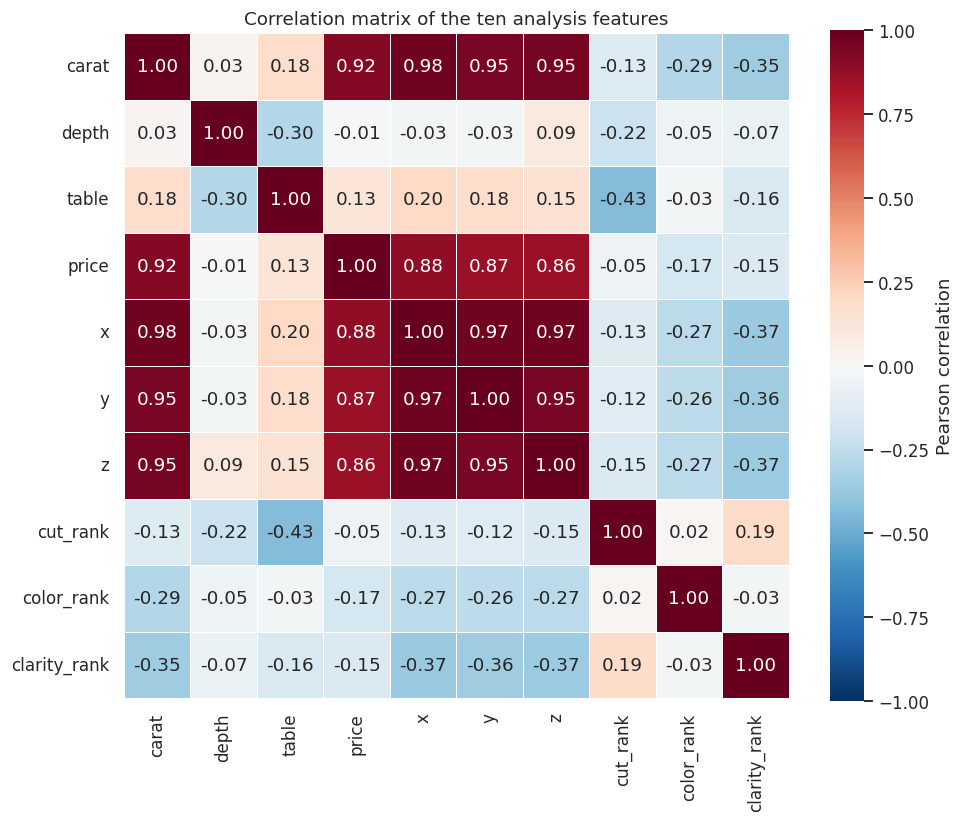

Strongest correlated pairs:
  carat          - x              r = +0.9751
  x              - y              r = +0.9747
  x              - z              r = +0.9708
  carat          - z              r = +0.9534
  y              - z              r = +0.9520
  carat          - y              r = +0.9517
  carat          - price          r = +0.9216
  price          - x              r = +0.8844


In [7]:
correlation = diamonds_df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson correlation'}, ax=ax)
ax.set_title('Correlation matrix of the ten analysis features')
plt.tight_layout()
plt.show()

abs_corr = correlation.abs().to_numpy().copy()
np.fill_diagonal(abs_corr, 0)
upper = np.triu_indices_from(abs_corr, k=1)
strongest = np.argsort(abs_corr[upper])[::-1][:8]
print('Strongest correlated pairs:')
for rank in strongest:
    i, j = upper[0][rank], upper[1][rank]
    print(f'  {FEATURES[i]:14s} - {FEATURES[j]:14s} r = {correlation.iloc[i, j]:+.4f}')

This cell compares Pearson, Spearman and Kendall on four pairs of features, and computes
Cramer's V between the three quality grades. Pearson measures linear association and the other
two measure monotone association, so comparing them shows whether a relationship is straight or
merely increasing.

In [8]:
flavour_rows = []
for left, right in [('carat', 'price'), ('carat', 'x'), ('x', 'y'), ('depth', 'table')]:
    flavour_rows.append({
        'pair':     f'{left} - {right}',
        'pearson':  diamonds_df[left].corr(diamonds_df[right]),
        'spearman': diamonds_df[left].corr(diamonds_df[right], method='spearman'),
        'kendall':  diamonds_df[left].corr(diamonds_df[right], method='kendall'),
    })
display(pd.DataFrame(flavour_rows).set_index('pair').round(4))

print('Pearson on the logarithms, log(carat) vs log(price):',
      round(float(np.log(diamonds_df['carat']).corr(np.log(diamonds_df['price']))), 4))

def cramers_v(first, second):
    table = pd.crosstab(first, second)
    chi2 = stats.chi2_contingency(table)[0]
    n_obs = table.to_numpy().sum()
    rows, cols = table.shape
    return np.sqrt((chi2 / n_obs) / min(rows - 1, cols - 1))

print("\nCramer's V between the three quality grades:")
for left, right in [('cut', 'color'), ('cut', 'clarity'), ('color', 'clarity')]:
    print(f'  {left:8s} vs {right:8s} V = {cramers_v(diamonds_df[left], diamonds_df[right]):.4f}')

,pearson,spearman,kendall
pair,,,
carat - price,0.9216,0.9629,0.8341
carat - x,0.9751,0.9961,0.9606
x - y,0.9747,0.9979,0.9682
depth - table,-0.2958,-0.2451,-0.1787


Pearson on the logarithms, log(carat) vs log(price): 0.9659

Cramer's V between the three quality grades:
  cut      vs color    V = 0.0379
  cut      vs clarity  V = 0.1427
  color    vs clarity  V = 0.0795


What the correlation structure shows

There is one dominant block.
carat, x, y, z and price all correlate above 0.86 with each other, and carat with x reaches
0.975. This is not a surprise once I say it out loud: carat is weight, and x, y, z are the
dimensions that produce that weight, so five columns are really measuring one underlying thing,
the size of the stone. Price follows size closely because size is what a buyer pays for. This
block is the redundancy that PCA will exploit in section 3.

Carat and price are monotone but not linear.
Pearson gives 0.9216 while Spearman gives 0.9629. Whenever Spearman is clearly higher than
Pearson the relationship is increasing but curved. Taking logarithms of both confirms it: the
Pearson correlation of log(carat) with log(price) is 0.9659, so price grows roughly as a power
of weight rather than in proportion to it. This matters later, because PCA is a linear method
and can only capture the straight-line part of this relationship.

The three quality grades are almost unrelated to each other.
Cramer's V is 0.038 between cut and colour, 0.143 between cut and clarity and 0.080 between
colour and clarity. Each grade carries its own information, which is why they will need their
own principal components rather than collapsing into the size block.

depth and table sit outside everything.
depth correlates at most 0.095 with any dimension and table at most 0.195. These are shape
ratios rather than sizes: a small stone and a large stone can be cut to the same proportions.
Their only notable relation is with each other and with cut quality, which makes sense because
both describe how the stone was cut.

2.3  Distribution analysis

For each major feature I look at the histogram, the boxplot, the skewness and the kurtosis
together, because each one hides something the others reveal.

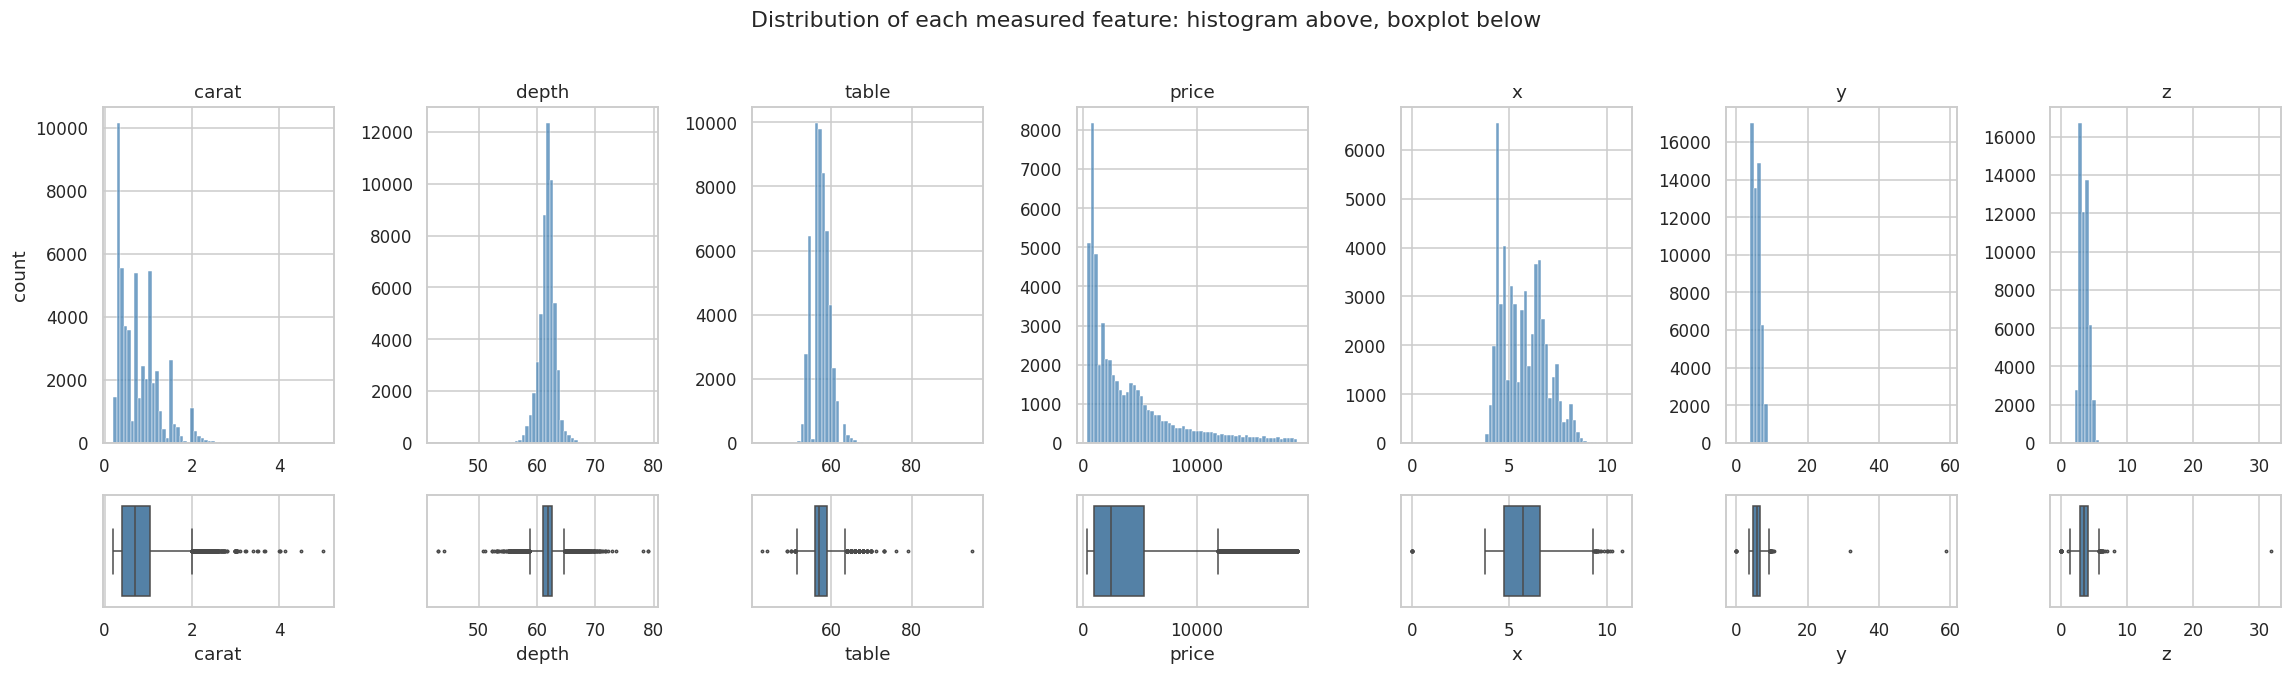

In [9]:
fig, axes = plt.subplots(2, 7, figsize=(21, 6),
                         gridspec_kw={'height_ratios': [3, 1]})
for col, feature in enumerate(MEASURED_FEATURES):
    values = diamonds_df[feature]
    sns.histplot(values, bins=60, ax=axes[0, col], color='steelblue',
                 edgecolor='white', linewidth=0.3)
    axes[0, col].set_title(feature)
    axes[0, col].set_xlabel('')
    axes[0, col].set_ylabel('count' if col == 0 else '')
    sns.boxplot(x=values, ax=axes[1, col], color='steelblue', fliersize=1.5)
    axes[1, col].set_xlabel(feature)
plt.suptitle('Distribution of each measured feature: histogram above, boxplot below', y=1.02)
plt.tight_layout()
plt.show()

This cell plots the counts of the three ordered grades. A histogram of a variable with five to
eight levels is really a bar chart, so that is what I draw.

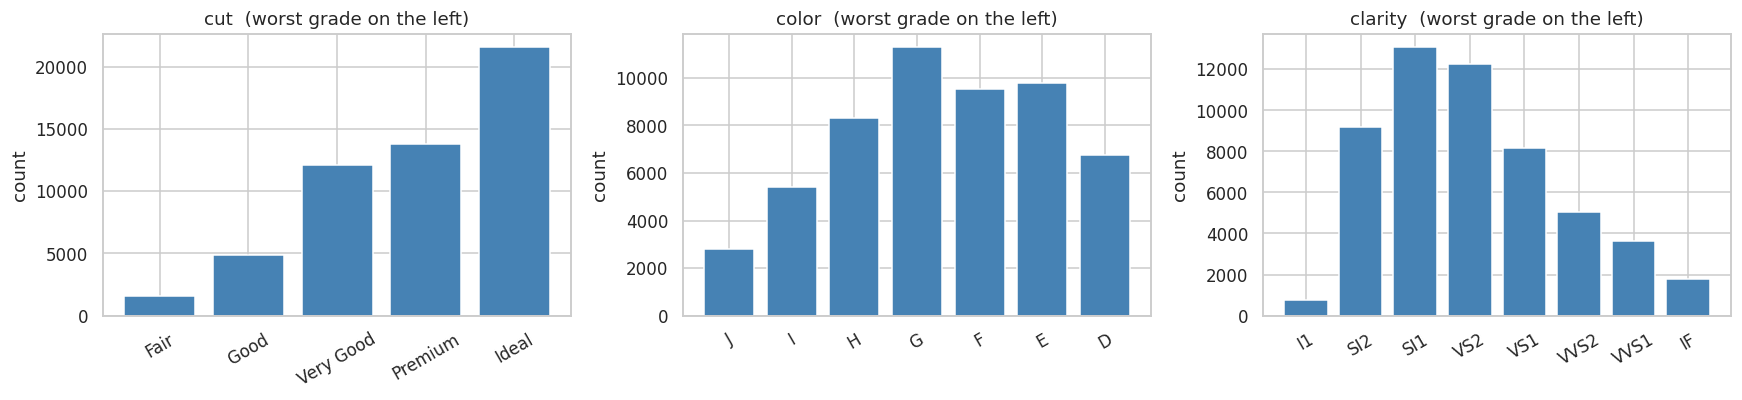

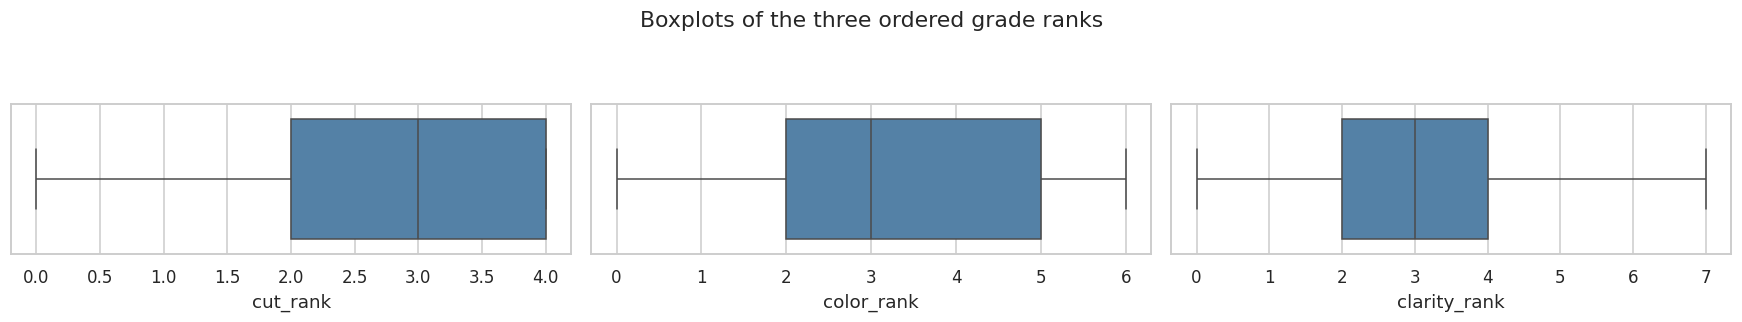

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, (column, order) in zip(axes, [('cut', CUT_ORDER), ('color', COLOR_ORDER),
                                      ('clarity', CLARITY_ORDER)]):
    counts = diamonds_df[column].value_counts().reindex(order)
    ax.bar(range(len(order)), counts.to_numpy(), color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=30)
    ax.set_title(f'{column}  (worst grade on the left)')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 2.6))
for ax, feature_name in zip(axes, GRADE_FEATURES):
    sns.boxplot(x=diamonds_df[feature_name], ax=ax, color='steelblue', fliersize=1.5)
    ax.set_xlabel(feature_name)
plt.suptitle('Boxplots of the three ordered grade ranks', y=1.12)
plt.tight_layout()
plt.show()

This cell computes the skewness and the excess kurtosis of every feature and plots them
together.

,skewness,excess_kurtosis,p99,max,max_over_p99
feature,,,,,
carat,1.117,1.256,2.18,5.01,2.298
depth,-0.082,5.739,65.60,79.00,1.204
table,0.797,2.801,64.00,95.00,1.484
price,1.618,2.177,17378.22,18823.00,1.083
x,0.379,-0.618,8.36,10.74,1.285
y,2.434,91.206,8.34,58.90,7.062
z,1.522,47.082,5.15,31.80,6.175
cut_rank,-0.717,-0.398,4.00,4.00,1.000
color_rank,-0.189,-0.867,6.00,6.00,1.000


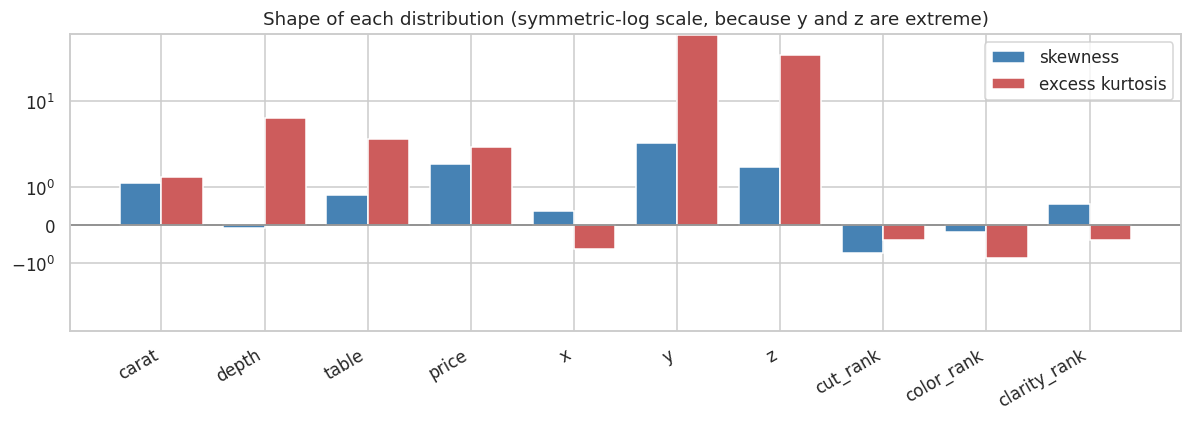

In [11]:
shape_rows = []
for feature in FEATURES:
    values = diamonds_df[feature].astype(float)
    shape_rows.append({
        'feature':          feature,
        'skewness':         stats.skew(values),
        'excess_kurtosis':  stats.kurtosis(values, fisher=True),
        'p99':              values.quantile(0.99),
        'max':              values.max(),
        'max_over_p99':     values.max() / values.quantile(0.99) if values.quantile(0.99) > 0 else np.nan,
    })
shape_stats = pd.DataFrame(shape_rows).set_index('feature')
display(shape_stats.round(3))

fig, ax = plt.subplots(figsize=(11, 4))
positions = np.arange(len(shape_stats))
ax.bar(positions - 0.2, shape_stats['skewness'], 0.4, label='skewness', color='steelblue')
ax.bar(positions + 0.2, shape_stats['excess_kurtosis'], 0.4, label='excess kurtosis',
       color='indianred')
ax.axhline(0, color='grey', lw=1)
ax.set_xticks(positions)
ax.set_xticklabels(shape_stats.index, rotation=30, ha='right')
ax.set_yscale('symlog')
ax.set_title('Shape of each distribution (symmetric-log scale, because y and z are extreme)')
ax.legend()
plt.tight_layout()
plt.show()

What the distributions show

price and carat are strongly right-skewed.
Skewness is 1.618 for price and 1.117 for carat, and both histograms show a dense pile of small
cheap stones with a thin tail running to the right. Taking logarithms almost removes it: the
skewness of log(price) is 0.115. So the natural scale for price is multiplicative, not
additive.

carat shows clear rounding spikes.
The histogram has visible bars exactly at 0.3, 0.5, 0.7, 1.0, 1.5 and 2.0 carats. Stones are
cut to hit those round weights because the price per carat jumps at them, so this is a real
commercial effect and not a recording artefact. It does mean the feature is not really
continuous.

y and z have absurd kurtosis.
Excess kurtosis is 91.2 for y and 47.1 for z. Nothing else comes close: the next largest is
depth at 5.7, carat and table sit between 1 and 3, and x and the three grade ranks are actually
negative, meaning flatter than a normal. A value that large cannot come from the shape of a
distribution; it comes from individual records. The max_over_p99 column makes it concrete: for
y the maximum is 7.06 times the 99th percentile, while for x, a column measuring the same kind
of quantity, the ratio is only 1.29. Whatever is wrong is wrong with y and z and not with the
width of diamonds in general.

depth and table are tight but have long thin tails on both sides.
depth has a standard deviation of only 1.43 around a mean of 61.7, yet it ranges from 43 to 79.
Since depth is a cutting proportion, values that far out describe stones cut far outside normal
practice.

The grades are unbalanced.
Ideal is the most common cut with 21,551 stones while Fair has only 1,610, and clarity IF has
1,790 against SI1 with 13,065. Unbalanced categories matter for clustering: a method that looks
for equally sized groups will not find these.

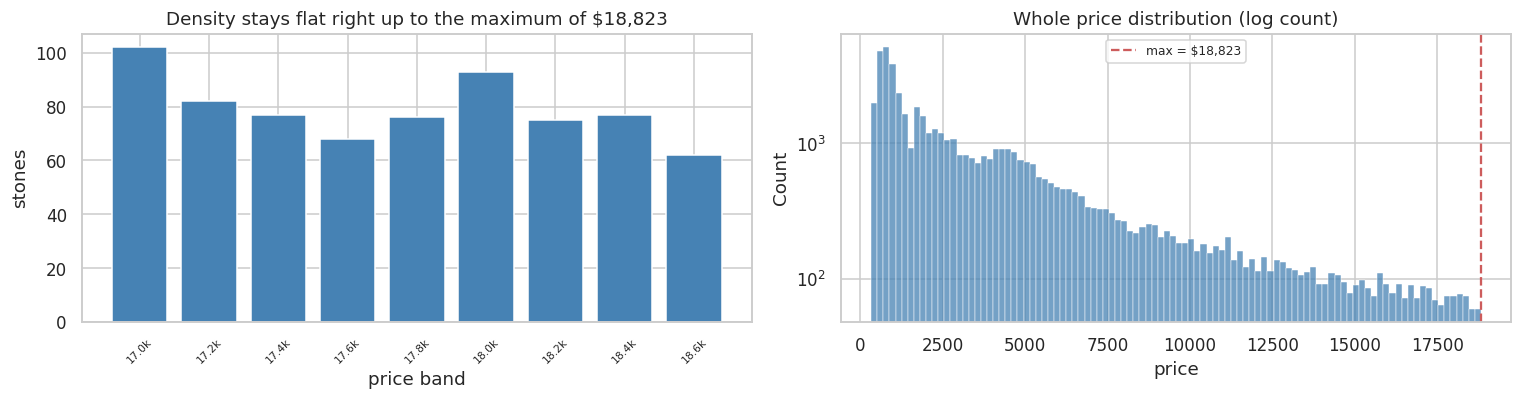

Stones per $200 band approaching the maximum:
price
(17000, 17200]    102
(17200, 17400]     82
(17400, 17600]     77
(17600, 17800]     68
(17800, 18000]     76
(18000, 18200]     93
(18200, 18400]     75
(18400, 18600]     77
(18600, 18800]     62

Stones priced above $18,800: 5


In [12]:
top_band = diamonds_df[diamonds_df['price'] > 17000]
band_counts = pd.cut(top_band['price'], bins=range(17000, 19000, 200)).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
axes[0].bar(range(len(band_counts)), band_counts.to_numpy(), color='steelblue',
            edgecolor='white')
axes[0].set_xticks(range(len(band_counts)))
axes[0].set_xticklabels([f'{int(i.left / 1000)}.{int(i.left % 1000 / 100)}k'
                         for i in band_counts.index], rotation=45, fontsize=7)
axes[0].set_xlabel('price band')
axes[0].set_ylabel('stones')
axes[0].set_title(f'Density stays flat right up to the maximum of '
                  f'${diamonds_df["price"].max():,}')

sns.histplot(diamonds_df['price'], bins=100, ax=axes[1], color='steelblue',
             edgecolor='white', linewidth=0.3)
axes[1].axvline(diamonds_df['price'].max(), color='indianred', ls='--', lw=1.5,
                label=f'max = ${diamonds_df["price"].max():,}')
axes[1].set_yscale('log')
axes[1].set_title('Whole price distribution (log count)')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Stones per $200 band approaching the maximum:')
print(band_counts.to_string())
print('\nStones priced above $18,800:', int((diamonds_df['price'] > 18800).sum()))

The counts stay between roughly 60 and 100 stones per $200 band all the way up to $18,800 and
then fall off a cliff, with only a handful of stones above that. A price distribution generated
by a market thins out gradually towards its upper end; one that stays flat and then stops is
the signature of a filter, most likely a search that returned only stones under $19,000. This
supports the truncation limitation I raised in section 1, and it matters for the anomaly
detection later: the most expensive diamonds are not in this file at all, so I never observe
the true upper tail of price.

2.4  Outlier exploration

The abnormality detection lecture separates a long tail from outliers, and this dataset
contains both. Confusing them would lead me to the wrong conclusion, so I separate them first
and then look for measurement artefacts and data-entry problems.

In [13]:
rule_rows = []
for feature in MEASURED_FEATURES:
    values = diamonds_df[feature].astype(float)
    mad = stats.median_abs_deviation(values, scale='normal')
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    rule_rows.append({
        'feature':        feature,
        'mean_std_>3':    int((np.abs((values - values.mean()) / values.std()) > 3).sum()),
        'median_MAD_>3':  int((np.abs((values - values.median()) / mad) > 3).sum()) if mad > 0 else -1,
        'IQR_1.5_fence':  int(((values < q1 - 1.5 * iqr) | (values > q3 + 1.5 * iqr)).sum()),
    })
display(pd.DataFrame(rule_rows).set_index('feature'))

,mean_std_>3,median_MAD_>3,IQR_1.5_fence
feature,,,
carat,439,681,1889
depth,685,2261,2545
table,336,2560,605
price,1206,5386,3540
x,43,15,32
y,34,16,29
z,55,32,49


The three rules disagree badly. For table the mean/std rule flags 336 stones and the median/MAD
rule flags 2,560, a factor of eight. The reason is that table is tightly peaked, so its MAD is
very small and dividing by it makes ordinary stones look extreme. For x, y and z the ordering
reverses: MAD flags fewer than mean/std, because there the standard deviation is the one being
inflated, by the very extreme values I am trying to find.

This is the first concrete lesson of the section. A univariate rule does not have a single
correct answer here, and which stones I call unusual depends on which estimator of spread I
pick, before I have chosen an algorithm at all.

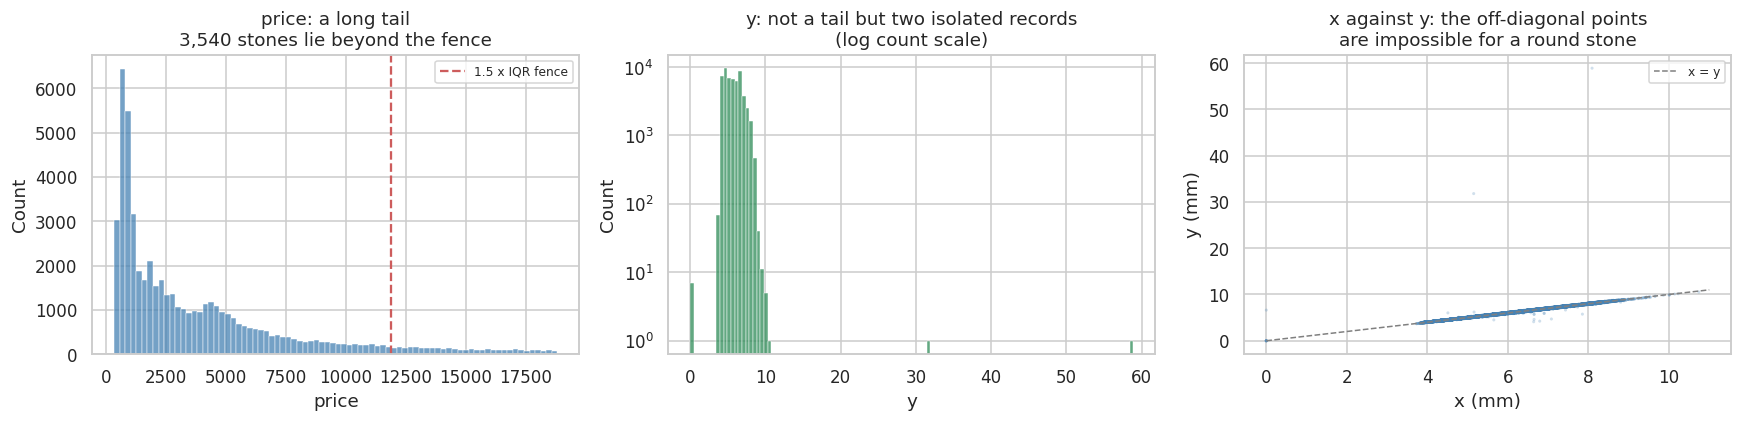

price skewness: 1.618 | stones beyond the price IQR fence: 3540
y skewness    : 2.434 | records with y > 20 mm: 2
y skewness after removing those records: 0.375


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(diamonds_df['price'], bins=80, ax=axes[0], color='steelblue',
             edgecolor='white', linewidth=0.3)
axes[0].axvline(diamonds_df['price'].quantile(0.75)
                + 1.5 * (diamonds_df['price'].quantile(0.75) - diamonds_df['price'].quantile(0.25)),
                color='indianred', ls='--', lw=1.5, label='1.5 x IQR fence')
axes[0].set_title('price: a long tail\n3,540 stones lie beyond the fence')
axes[0].legend(fontsize=8)

sns.histplot(diamonds_df['y'], bins=120, ax=axes[1], color='seagreen',
             edgecolor='white', linewidth=0.3)
axes[1].set_yscale('log')
axes[1].set_title('y: not a tail but two isolated records\n(log count scale)')

axes[2].scatter(diamonds_df['x'], diamonds_df['y'], s=4, alpha=0.25,
                color='steelblue', edgecolors='none')
axes[2].plot([0, 11], [0, 11], color='grey', lw=1, ls='--', label='x = y')
axes[2].set_xlabel('x (mm)')
axes[2].set_ylabel('y (mm)')
axes[2].set_title('x against y: the off-diagonal points\nare impossible for a round stone')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('price skewness:', round(float(stats.skew(diamonds_df['price'])), 3),
      '| stones beyond the price IQR fence:',
      int((diamonds_df['price'] > diamonds_df['price'].quantile(0.75)
           + 1.5 * (diamonds_df['price'].quantile(0.75) - diamonds_df['price'].quantile(0.25))).sum()))
print('y skewness    :', round(float(stats.skew(diamonds_df['y'])), 3),
      '| records with y > 20 mm:', int((diamonds_df['y'] > 20).sum()))
print('y skewness after removing those records:',
      round(float(stats.skew(diamonds_df.loc[diamonds_df['y'] <= 20, 'y'])), 3))

This is the long-tail-versus-outlier distinction made concrete. The price distribution has a
genuine long tail: 3,540 stones sit beyond the usual fence, which is 6.6 percent of the file,
and they are all perfectly ordinary expensive diamonds. Removing them would be throwing away
the data, not cleaning it.

The skewness of y is a completely different animal. It is 2.434, but if I remove the two
records where y exceeds 20 mm the skewness falls to 0.375. A statistic that is driven by two
rows out of 53,940 is not describing a distribution, it is describing two mistakes.

In [15]:
measurable = diamonds_df[(diamonds_df['x'] > 0) & (diamonds_df['y'] > 0) & (diamonds_df['z'] > 0)].copy()
measurable['depth_recomputed'] = 100 * 2 * measurable['z'] / (measurable['x'] + measurable['y'])
measurable['depth_gap'] = (measurable['depth_recomputed'] - measurable['depth']).abs()

print('Stones whose y is within 5% of x:',
      f"{100 * ((measurable['y'] / measurable['x'] - 1).abs() < 0.05).mean():.2f}%",
      '-> these really are round stones')
print('Median gap between the recomputed depth and the recorded depth:',
      round(float(measurable['depth_gap'].median()), 4), 'percentage points')
print('Share of stones where the two agree to within 1 point:',
      f"{100 * (measurable['depth_gap'] <= 1).mean():.3f}%")
print()
print('The records that break the formula:')
display(measurable.nlargest(6, 'depth_gap')[
    ['carat', 'price', 'depth', 'depth_recomputed', 'x', 'y', 'z']].round(2))

Stones whose y is within 5% of x: 99.95% -> these really are round stones
Median gap between the recomputed depth and the recorded depth: 0.0266 percentage points
Share of stones where the two agree to within 1 point: 99.852%

The records that break the formula:


,carat,price,depth,depth_recomputed,x,y,z
48410,0.51,1970,61.8,619.28,5.12,5.15,31.80
14635,1.07,5909,60.6,16.10,6.62,6.67,1.07
20694,1.53,8971,61.9,20.50,7.43,7.50,1.53
21654,1.41,9752,60.7,19.41,7.31,7.22,1.41
49905,0.50,2180,63.7,100.70,5.01,5.04,5.06
24067,2.00,12210,58.9,24.06,8.09,58.90,8.06


This cell classifies the defective records into the error types they actually represent.

In [16]:
zero_dimension = diamonds_df[(diamonds_df['x'] == 0) | (diamonds_df['y'] == 0) | (diamonds_df['z'] == 0)]

carat_copied_into_z = diamonds_df[np.isclose(diamonds_df['z'], diamonds_df['carat'], atol=1e-9)
                                  & (diamonds_df['z'] > 0)]

dimensions = diamonds_df[['x', 'y', 'z']]
largest_dimension = dimensions.max(axis=1)
smallest_nonzero = dimensions.replace(0, np.nan).min(axis=1)
decimal_shifted = diamonds_df[(largest_dimension / smallest_nonzero > 3) & smallest_nonzero.notna()]

cube_shaped = measurable[measurable['z'] / ((measurable['x'] + measurable['y']) / 2) > 0.9]

print(f'A. impossible zero dimension       : {len(zero_dimension):3d} stones')
print(f'B. carat value copied into z       : {len(carat_copied_into_z):3d} stones')
print(f'C. a dimension inflated ~10x       : {len(decimal_shifted):3d} stones')
print(f'D. cube-like, impossible proportions: {len(cube_shaped):3d} stones')

defective_rows = sorted(set(zero_dimension.index) | set(carat_copied_into_z.index)
                        | set(decimal_shifted.index) | set(cube_shaped.index))
print(f'\nTotal rows carrying a defensible data error: {len(defective_rows)} '
      f'({100 * len(defective_rows) / len(diamonds_df):.3f}% of the file)')

print('\nError class B - the carat value was written into the z column:')
display(carat_copied_into_z[['carat', 'cut', 'price', 'depth', 'x', 'y', 'z']])
print('Error class C - a decimal point in the wrong place:')
display(decimal_shifted.loc[[i for i in decimal_shifted.index if i not in carat_copied_into_z.index],
                            ['carat', 'price', 'depth', 'x', 'y', 'z']])

A. impossible zero dimension       :  20 stones
B. carat value copied into z       :   3 stones
C. a dimension inflated ~10x       :   6 stones
D. cube-like, impossible proportions:   2 stones

Total rows carrying a defensible data error: 27 (0.050% of the file)

Error class B - the carat value was written into the z column:


,carat,cut,price,depth,x,y,z
14635,1.07,Ideal,5909,60.6,6.62,6.67,1.07
20694,1.53,Ideal,8971,61.9,7.43,7.50,1.53
21654,1.41,Ideal,9752,60.7,7.31,7.22,1.41


Error class C - a decimal point in the wrong place:


,carat,price,depth,x,y,z
24067,2.00,12210,58.9,8.09,58.90,8.06
48410,0.51,1970,61.8,5.12,5.15,31.80
49189,0.51,2075,61.8,5.15,31.80,5.12


This cell measures how much a single bad record distorts the correlation matrix that PCA is
built on.

In [17]:
without_worst = measurable.drop(measurable['y'].idxmax())
print('corr(x, y) using every record        :', round(float(measurable['x'].corr(measurable['y'])), 4))
print('corr(x, y) without the single y=58.9 :', round(float(without_worst['x'].corr(without_worst['y'])), 4))

well_formed = measurable[measurable['depth_gap'] <= 1]
print()
print('R^2 of recorded depth on the exact formula, all records      :',
      round(float(np.corrcoef(measurable['depth_recomputed'], measurable['depth'])[0, 1] ** 2), 4))
print(f'R^2 after removing the {len(measurable) - len(well_formed)} records that break it :',
      round(float(np.corrcoef(well_formed['depth_recomputed'], well_formed['depth'])[0, 1] ** 2), 6))

corr(x, y) using every record        : 0.9749
corr(x, y) without the single y=58.9 : 0.9934

R^2 of recorded depth on the exact formula, all records      : 0.2506
R^2 after removing the 80 records that break it : 0.998706


What the outlier exploration found

Heavy tails.
price and carat have genuine heavy right tails containing thousands of legitimate stones. These
are a property of the diamond market, where a few large stones cost far more than the many
small ones, and no method should treat them as errors by default.

Extreme values that are not tails.
The excess kurtosis of 91.2 in y comes from two records. This is the distinction the lecture
draws between a long tail and an outlier, and here the same dataset supplies a textbook example
of each.

Measurement artefacts.
99.95 percent of the stones have y within five percent of x, which confirms that these are
round stones and gives me a physical rule to test against. The recorded depth reproduces the
formula 100 * 2z / (x + y) to within 0.027 percentage points at the median, and 99.85 percent
of stones satisfy it to within one point. So depth is not an independent measurement at all -
it is a derived column, and the file contains the same information three and a half times over.

Duplicate records.
There are 146 exactly duplicated rows, 0.271 percent of the file. Two stones can genuinely
share every recorded attribute, so this is not automatically an error - but rows 49556 and
49557 are an identical pair that also has all three dimensions equal to zero, so at least some
duplicates are the same faulty record entered twice. I keep them, and they turn out to matter
in section 5.3: a broken record that appears twice has a near neighbour at distance zero, which
makes it look locally dense and lets it hide from LOF at small neighbourhood sizes.

Data-entry problems.
I found 27 rows, 0.050 percent of the file, that are defective for reasons that have nothing to
do with statistics:

The first class is 20 stones with a dimension of exactly zero. One of them, a 2.25 carat stone
priced at $18,034, has all three dimensions zero. These are missing measurements recorded as a
number rather than as missing, which is the most dangerous kind of missing data because every
arithmetic operation silently accepts it.

The second class is 3 stones with the carat value copied into the z column. Row 14635 is a 1.07
carat stone with z = 1.07 mm, row 20694 is 1.53 carat with z = 1.53, and row 21654 is 1.41 with
z = 1.41. A 1.07 carat round stone is about 4 mm deep, so somebody pasted the wrong column.
This error is invisible to any univariate check, because 1.07 is a perfectly ordinary value for
z on its own.

The third class is 3 stones with a misplaced decimal point: y = 58.90 where x = 8.09, and two
stones with a dimension of 31.80 where the others are near 5.1. The fourth is 2 stones that are
cube-shaped, with depth roughly equal to width, which no cut diamond is.

These four classes overlap, which is why they list 20, 3, 6 and 2 records while the union is 27
rather than 31. Four rows are counted twice: the three carat-in-z stones (14635, 20694, 21654)
are each also caught by the decimal-shift rule, since a z of 1.07 mm next to an x of 6.62 mm is
exactly the ratio that rule looks for; and row 48410, with a dimension of 31.80 mm, is caught
both as a decimal shift and as cube-like proportions.

Why this matters for the rest of the notebook.
These 27 rows are 0.05 percent of the data and they already distort the statistics everything
else depends on. Removing the single worst record lifts the correlation between x and y from
0.9749 to 0.9934. The relationship between depth and its own defining formula has an R^2 of
only 0.2506 across all records, but 0.9987 once the 80 records that break it are set aside. PCA
is computed from exactly this covariance matrix, so a handful of typos is quietly steering the
principal axes.

I deliberately keep these rows in for the rest of the analysis. Removing them first would be
using the answer to set up the question: the whole point of sections 5 and 6 is to ask which
anomaly detection method finds them without being told they exist.

3  Dimensionality Reduction

3.1  Principal Component Analysis

Following the lecture, PCA finds the eigenvectors of the covariance matrix, ordered by their
eigenvalues. Geometrically it finds the principal axes of the data ellipsoid, and the explained
variance ratio of component i is lambdai divided by the sum of all the eigenvalues. Because the
features here are measured in carats, millimetres, dollars and grade ranks, I standardise first -
otherwise, as the lecture puts it, PCA would mainly discover units rather than structure. I
show that concretely at the end of this section.

In [18]:
pca_full = PCA(random_state=RANDOM_STATE).fit(scaled_matrix)

explained_ratio = pca_full.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

variance_table = pd.DataFrame({
    'eigenvalue':          pca_full.explained_variance_,
    'explained_variance':  explained_ratio,
    'cumulative_variance': cumulative_ratio,
}, index=[f'PC{i}' for i in range(1, len(explained_ratio) + 1)])
display(variance_table.round(4))

for threshold in (0.80, 0.90, 0.95, 0.99):
    needed = int(np.searchsorted(cumulative_ratio, threshold) + 1)
    print(f'Components needed to reach {int(threshold * 100)}% of the variance: {needed}')
print('Components with an eigenvalue above 1 (Kaiser rule):',
      int((pca_full.explained_variance_ > 1).sum()))

,eigenvalue,explained_variance,cumulative_variance
PC1,5.0070,0.5007,0.5007
PC2,1.4374,0.1437,0.6444
PC3,1.2339,0.1234,0.7678
PC4,0.9862,0.0986,0.8664
PC5,0.7705,0.0770,0.9435
PC6,0.3582,0.0358,0.9793
PC7,0.1278,0.0128,0.9921
PC8,0.0402,0.0040,0.9961
PC9,0.0270,0.0027,0.9988
PC10,0.0120,0.0012,1.0000


Components needed to reach 80% of the variance: 4
Components needed to reach 90% of the variance: 5
Components needed to reach 95% of the variance: 6
Components needed to reach 99% of the variance: 7
Components with an eigenvalue above 1 (Kaiser rule): 3


This cell plots the scree curve and the cumulative explained variance on one figure.

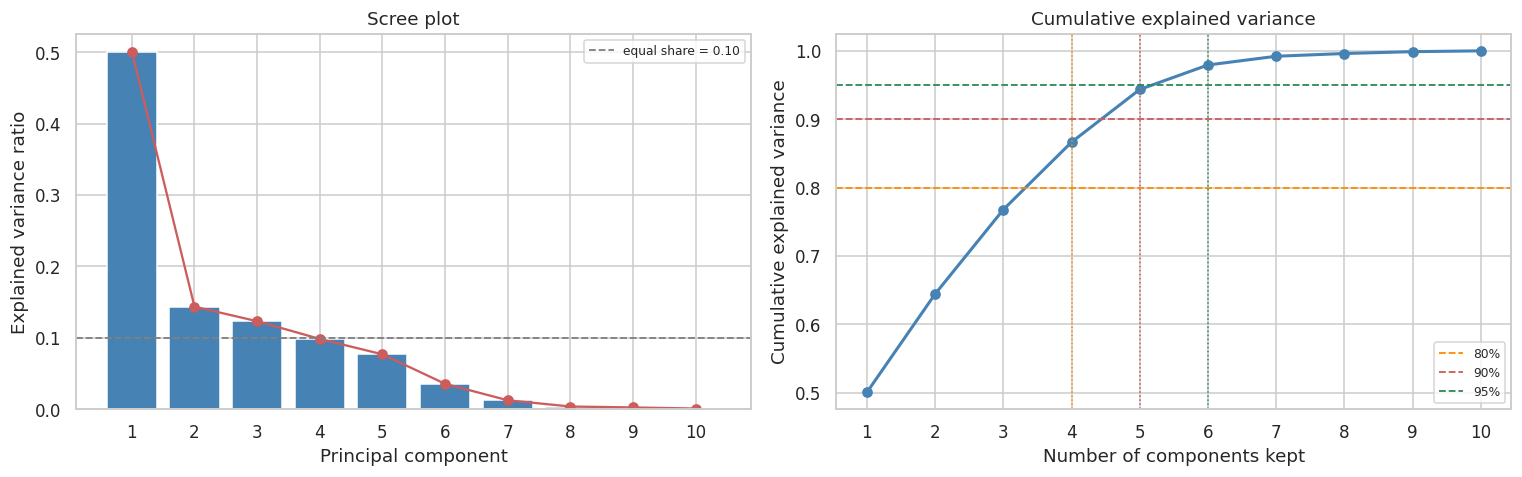

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
components = np.arange(1, len(explained_ratio) + 1)

axes[0].bar(components, explained_ratio, color='steelblue', edgecolor='white')
axes[0].plot(components, explained_ratio, 'o-', color='indianred', lw=1.5)
axes[0].axhline(1 / len(FEATURES), color='grey', ls='--', lw=1.2,
                label=f'equal share = {1 / len(FEATURES):.2f}')
axes[0].set_xticks(components)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')
axes[0].legend(fontsize=8)

axes[1].plot(components, cumulative_ratio, 'o-', color='steelblue', lw=2)
for level, colour in [(0.80, 'darkorange'), (0.90, 'indianred'), (0.95, 'seagreen')]:
    axes[1].axhline(level, color=colour, ls='--', lw=1.2, label=f'{int(level * 100)}%')
    axes[1].axvline(np.searchsorted(cumulative_ratio, level) + 1, color=colour, ls=':', lw=1)
axes[1].set_xticks(components)
axes[1].set_xlabel('Number of components kept')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_title('Cumulative explained variance')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

This cell reports the loadings, which show how much each original variable contributes to each
component.

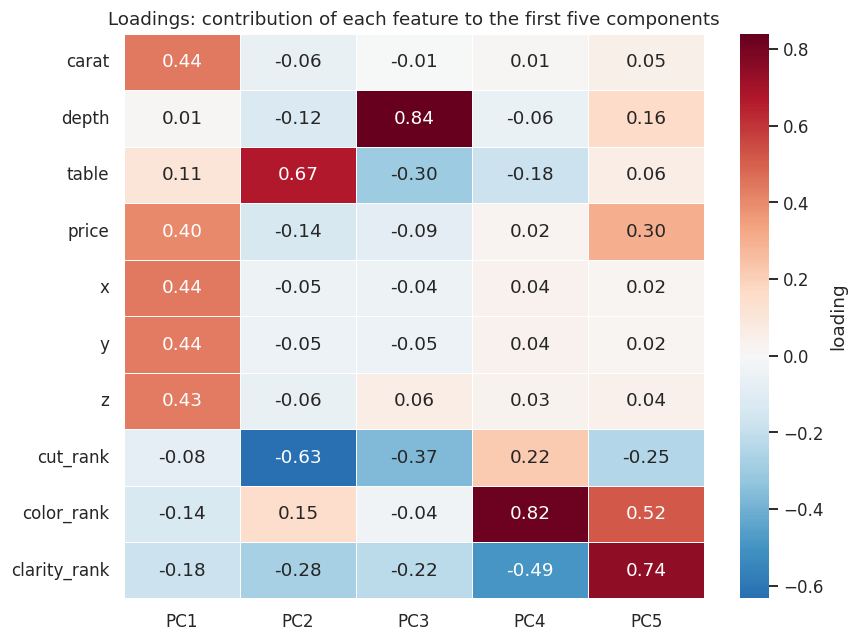

PC1 is dominated by: x (+0.44), carat (+0.44), y (+0.44)
PC2 is dominated by: table (+0.67), cut_rank (-0.63), clarity_rank (-0.28)
PC3 is dominated by: depth (+0.84), cut_rank (-0.37), table (-0.30)
PC4 is dominated by: color_rank (+0.82), clarity_rank (-0.49), cut_rank (+0.22)
PC5 is dominated by: clarity_rank (+0.74), color_rank (+0.52), price (+0.30)


In [20]:
loadings = pd.DataFrame(pca_full.components_[:5].T, index=FEATURES,
                        columns=[f'PC{i}' for i in range(1, 6)])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={'label': 'loading'}, ax=ax)
ax.set_title('Loadings: contribution of each feature to the first five components')
plt.tight_layout()
plt.show()

for component in loadings.columns:
    ranked = loadings[component].abs().sort_values(ascending=False)
    top_three = ', '.join(f'{name} ({loadings.loc[name, component]:+.2f})'
                          for name in ranked.index[:3])
    print(f'{component} is dominated by: {top_three}')

This cell projects every stone onto the components and plots the first four.

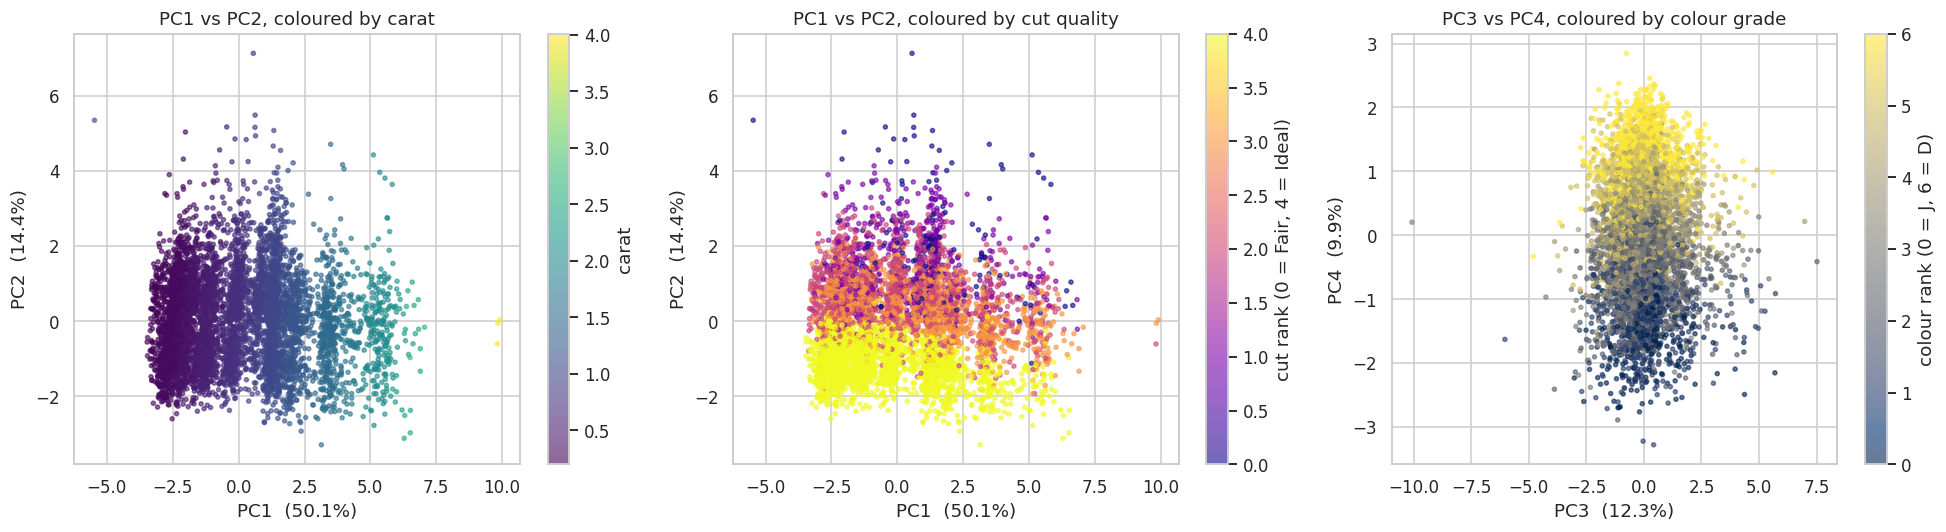

In [21]:
scores = pca_full.transform(scaled_matrix)

plot_sample = np.random.RandomState(RANDOM_STATE).choice(len(scores), 6000, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

first = axes[0].scatter(scores[plot_sample, 0], scores[plot_sample, 1],
                        c=diamonds_df['carat'].to_numpy()[plot_sample],
                        s=7, alpha=0.6, cmap='viridis')
plt.colorbar(first, ax=axes[0], label='carat')
axes[0].set_title('PC1 vs PC2, coloured by carat')

second = axes[1].scatter(scores[plot_sample, 0], scores[plot_sample, 1],
                         c=diamonds_df['cut_rank'].to_numpy()[plot_sample],
                         s=7, alpha=0.6, cmap='plasma')
plt.colorbar(second, ax=axes[1], label='cut rank (0 = Fair, 4 = Ideal)')
axes[1].set_title('PC1 vs PC2, coloured by cut quality')

third = axes[2].scatter(scores[plot_sample, 2], scores[plot_sample, 3],
                        c=diamonds_df['color_rank'].to_numpy()[plot_sample],
                        s=7, alpha=0.6, cmap='cividis')
plt.colorbar(third, ax=axes[2], label='colour rank (0 = J, 6 = D)')
axes[2].set_title('PC3 vs PC4, coloured by colour grade')

for ax, (a, b) in zip(axes, [(1, 2), (1, 2), (3, 4)]):
    ax.set_xlabel(f'PC{a}  ({explained_ratio[a - 1] * 100:.1f}%)')
    ax.set_ylabel(f'PC{b}  ({explained_ratio[b - 1] * 100:.1f}%)')
plt.tight_layout()
plt.show()

This cell draws the biplot, which puts the projected stones and the feature directions on the
same axes.

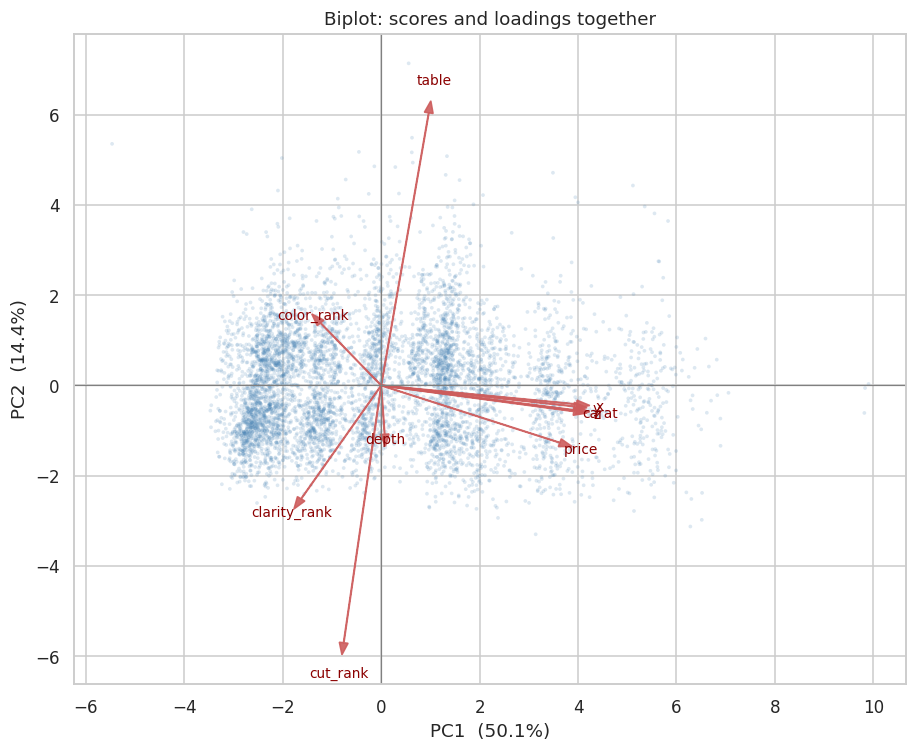

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(scores[plot_sample, 0], scores[plot_sample, 1], s=6, alpha=0.18,
           color='steelblue', edgecolors='none')

arrow_scale = 9
for feature_name in FEATURES:
    row = FEATURES.index(feature_name)
    dx, dy = pca_full.components_[0, row] * arrow_scale, pca_full.components_[1, row] * arrow_scale
    ax.arrow(0, 0, dx, dy, color='indianred', width=0.012, head_width=0.18, alpha=0.9)
    ax.text(dx * 1.12, dy * 1.12, feature_name, color='darkred', fontsize=9,
            ha='center', va='center')

ax.axhline(0, color='grey', lw=0.8)
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel(f'PC1  ({explained_ratio[0] * 100:.1f}%)')
ax.set_ylabel(f'PC2  ({explained_ratio[1] * 100:.1f}%)')
ax.set_title('Biplot: scores and loadings together')
plt.tight_layout()
plt.show()

This cell plots the three dimensional projection onto the first three components.

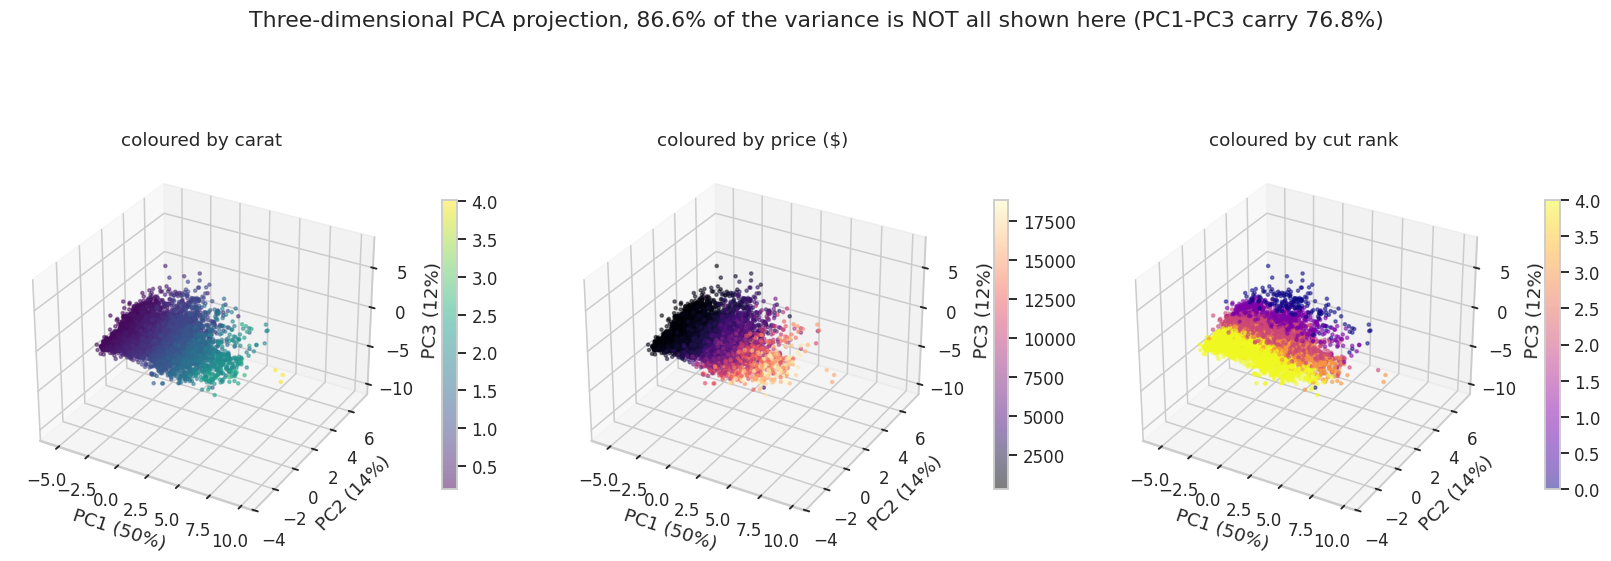

In [23]:
fig = plt.figure(figsize=(15, 5.5))

for position, (colour_by, cmap_name, label) in enumerate(
        [('carat', 'viridis', 'carat'),
         ('price', 'magma', 'price ($)'),
         ('cut_rank', 'plasma', 'cut rank')], start=1):
    ax = fig.add_subplot(1, 3, position, projection='3d')
    picture = ax.scatter(scores[plot_sample, 0], scores[plot_sample, 1], scores[plot_sample, 2],
                         c=diamonds_df[colour_by].to_numpy()[plot_sample],
                         s=4, alpha=0.5, cmap=cmap_name)
    ax.set_xlabel(f'PC1 ({explained_ratio[0] * 100:.0f}%)')
    ax.set_ylabel(f'PC2 ({explained_ratio[1] * 100:.0f}%)')
    ax.set_zlabel(f'PC3 ({explained_ratio[2] * 100:.0f}%)')
    ax.set_title(f'coloured by {label}')
    fig.colorbar(picture, ax=ax, shrink=0.55, pad=0.1)

plt.suptitle('Three-dimensional PCA projection, 86.6% of the variance is NOT all shown here '
             '(PC1-PC3 carry 76.8%)', y=1.02)
plt.tight_layout()
plt.show()

This cell measures how much information is lost, by reconstructing the data from k components
and comparing the result with the original.

,cumulative_variance,reconstruction_MSE,mean_abs_error
components,,,
1,0.5007,0.4993,0.4622
2,0.6444,0.3556,0.3776
3,0.7678,0.2322,0.3052
4,0.8664,0.1336,0.2397
5,0.9435,0.0565,0.1430
6,0.9793,0.0207,0.0671
7,0.9921,0.0079,0.0218
8,0.9961,0.0039,0.0206
9,0.9988,0.0012,0.0109


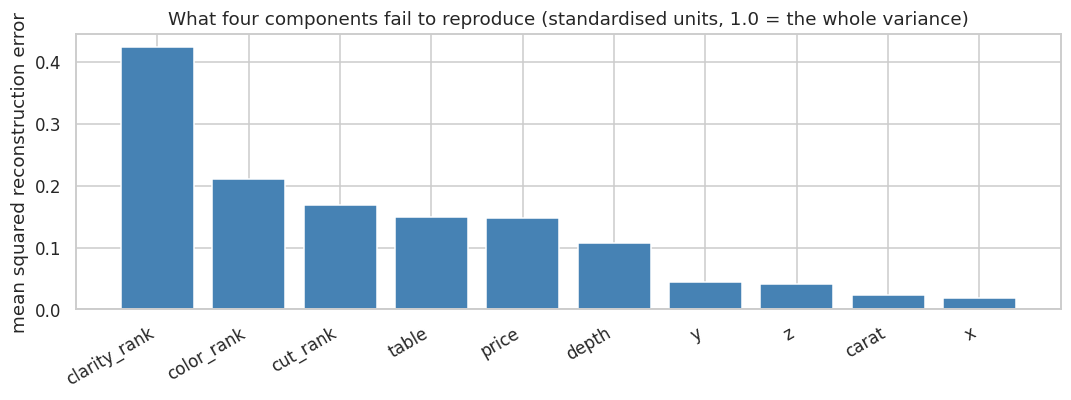

In [24]:
reconstruction_rows = []
for k in range(1, len(FEATURES) + 1):
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE).fit(scaled_matrix)
    rebuilt = pca_k.inverse_transform(pca_k.transform(scaled_matrix))
    reconstruction_rows.append({
        'components':          k,
        'cumulative_variance': cumulative_ratio[k - 1],
        'reconstruction_MSE':  float(((scaled_matrix - rebuilt) ** 2).mean()),
        'mean_abs_error':      float(np.abs(scaled_matrix - rebuilt).mean()),
    })
reconstruction = pd.DataFrame(reconstruction_rows).set_index('components')
display(reconstruction.round(4))

pca_four = PCA(n_components=4, random_state=RANDOM_STATE).fit(scaled_matrix)
rebuilt_four = pca_four.inverse_transform(pca_four.transform(scaled_matrix))
per_feature_error = pd.Series(((scaled_matrix - rebuilt_four) ** 2).mean(axis=0),
                              index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(per_feature_error.index, per_feature_error.to_numpy(), color='steelblue',
       edgecolor='white')
ax.set_ylabel('mean squared reconstruction error')
ax.set_title('What four components fail to reproduce (standardised units, 1.0 = the whole variance)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

This cell shows what PCA does when the features are not standardised.

In [25]:
pca_unscaled = PCA(random_state=RANDOM_STATE).fit(raw_matrix)
print('WITHOUT standardising:')
print('  PC1 explains', f'{pca_unscaled.explained_variance_ratio_[0]:.6f}', 'of the variance')
print('  its largest loading is on:',
      FEATURES[int(np.argmax(np.abs(pca_unscaled.components_[0])))])
print('  variance of price in raw units:', f'{raw_matrix[:, FEATURES.index("price")].var():,.0f}')
print('  variance of z     in raw units:', f'{raw_matrix[:, FEATURES.index("z")].var():,.3f}')
print()
print('WITH standardising:')
print('  PC1 explains', f'{explained_ratio[0]:.4f}', 'of the variance')
print('  its largest loading is on:', FEATURES[int(np.argmax(np.abs(pca_full.components_[0])))])

WITHOUT standardising:
  PC1 explains 0.999999 of the variance
  its largest loading is on: price
  variance of price in raw units: 15,915,334
  variance of z     in raw units: 0.498

WITH standardising:
  PC1 explains 0.5007 of the variance
  its largest loading is on: x


This cell refits PCA on 30 bootstrap resamples and checks whether the loadings move. The
lecture lists ignoring stability across samples as a common mistake.

In [26]:
bootstrap_rng = np.random.RandomState(RANDOM_STATE)
bootstrap_pc1, bootstrap_variance = [], []
for _ in range(30):
    resample = bootstrap_rng.choice(len(scaled_matrix), len(scaled_matrix), replace=True)
    pca_boot = PCA(n_components=4, random_state=RANDOM_STATE).fit(scaled_matrix[resample])
    direction = pca_boot.components_[0]
    if np.dot(direction, pca_full.components_[0]) < 0:
        direction = -direction
    bootstrap_pc1.append(direction)
    bootstrap_variance.append(pca_boot.explained_variance_ratio_[0])

bootstrap_pc1 = np.array(bootstrap_pc1)
stability = pd.DataFrame({
    'full_sample_loading': pca_full.components_[0],
    'bootstrap_mean':      bootstrap_pc1.mean(axis=0),
    'bootstrap_std':       bootstrap_pc1.std(axis=0),
}, index=FEATURES)
display(stability.round(4))
print('PC1 explained variance across 30 bootstraps: mean',
      round(float(np.mean(bootstrap_variance)), 4),
      ' std', round(float(np.std(bootstrap_variance)), 5))
print('Largest standard deviation of any PC1 loading:',
      round(float(stability['bootstrap_std'].max()), 5))

,full_sample_loading,bootstrap_mean,bootstrap_std
carat,0.4406,0.4406,0.0010
depth,0.0077,0.0073,0.0023
table,0.1073,0.1073,0.0028
price,0.4032,0.4039,0.0014
x,0.4413,0.4413,0.0011
y,0.4350,0.4352,0.0035
z,0.4349,0.4344,0.0022
cut_rank,-0.0847,-0.0841,0.0023
color_rank,-0.1370,-0.1364,0.0018
clarity_rank,-0.1808,-0.1803,0.0022


PC1 explained variance across 30 bootstraps: mean 0.5008  std 0.00193
Largest standard deviation of any PC1 loading: 0.00352


This cell measures how much local structure the projection keeps, by counting how many of each
stone's twenty nearest neighbours in the full space are still among its twenty nearest in the
reduced one.

In [27]:
from scipy.spatial import cKDTree

neighbourhood_sample = np.random.RandomState(RANDOM_STATE).choice(len(scaled_matrix), 5000,
                                                                  replace=False)
full_space = scaled_matrix[neighbourhood_sample]

def neighbour_sets(points, k=20):
    tree = cKDTree(points)
    _, indices = tree.query(points, k=k + 1)
    return [set(row[1:]) for row in indices]

neighbours_full = neighbour_sets(full_space)
print('Fraction of each stone\'s 20 nearest neighbours that survive the projection:')
for k in [2, 3, 4, 5]:
    projected = PCA(n_components=k, random_state=RANDOM_STATE).fit_transform(full_space)
    neighbours_low = neighbour_sets(projected)
    overlap = np.mean([len(a & b) / 20 for a, b in zip(neighbours_full, neighbours_low)])
    print(f'  keeping {k} components ({cumulative_ratio[k - 1] * 100:4.1f}% of the variance): '
          f'{overlap:.3f}')

Fraction of each stone's 20 nearest neighbours that survive the projection:
  keeping 2 components (64.4% of the variance): 0.135


  keeping 3 components (76.8% of the variance): 0.283


  keeping 4 components (86.6% of the variance): 0.491
  keeping 5 components (94.3% of the variance): 0.760


Discussion of the PCA results

How many components are needed to adequately represent the data?
Four, on the 80 percent rule: PC1 to PC4 carry 86.6 percent of the variance while three carry
only 76.8 percent. Five reach 94.4 percent and six reach 97.9 percent.

The other rules disagree, and by a measurable amount. The Kaiser rule keeps components with an
eigenvalue above 1 and selects three, because PC4's eigenvalue is 0.9862, just below the cut.
That is the same thing as saying PC4 explains 9.86 percent, marginally less than the 10 percent
an uninformative component would receive, which is why PC4 sits a fraction below the equal-
share line drawn on the scree plot. So PC4 is genuinely borderline: it fails the equal-share
test by 0.14 of a percentage point and is needed to pass the 80 percent test.

I keep four, because the reconstruction table shows a real gain from the fourth component - the
error falls from 0.2322 to 0.1336, a drop of 42 percent - and because PC4 is interpretable as a
colour-against-clarity axis. The defensible range is three to five depending on the rule, and
four is the choice I make inside it.

How much information is lost?
With four components the reconstruction error is 0.1336 in standardised units, meaning about 13
percent of the total variance cannot be rebuilt. But that average hides where the loss falls.
Reconstructing from four components loses almost nothing on x (0.018) and carat (0.023), and
loses 42 percent of clarity_rank and 21 percent of color_rank. So a four component summary
describes the size of a stone almost perfectly and its quality grades badly. If I later care
about clarity, this compression has thrown away exactly the thing I need.

Which variables are strongly correlated, and how does that affect the results? The block carat,
x, y, z and price correlates above 0.86 internally. PCA responds by building PC1 almost
entirely out of them: their loadings are +0.441, +0.441, +0.435, +0.435 and +0.403, essentially
the same weight on each. That is PCA doing its job. Five correlated columns collapse into a
single axis, which is why PC1 alone reaches 50.1 percent when an uninformative component would
get 10 percent. The correlation between PC1 and carat is 0.986.

Interpreting the major components.
PC1 is size and value: everything to do with how big the stone is and what it costs. PC2 is
cutting style, with table at +0.671 against cut_rank at -0.633; a wide top facet goes with a
poorer cut grade, and its correlation with cut_rank is -0.759. PC3 is depth proportion, with
depth at +0.839 and a correlation of 0.932 with the raw column, so this component is
essentially the depth variable on its own. PC4 is colour against clarity, with color_rank at
+0.818 and clarity_rank at -0.493. The order is informative. After the size block is absorbed
by PC1, PCA has to spend three further components carrying table/cut, depth, and colour/clarity -
features that, as the Cramer's V values in section 2 showed, share almost nothing with the
size block or with each other. PC3 is the starkest case: it is essentially the depth column on
its own, correlating 0.932 with it.

Does the reduced dataset represent the data more effectively, and how redundant is the
original? Partly, and the answer differs by feature. There is genuine redundancy: five of the
ten columns measure size, so the first component replaces them at a cost of very little
accuracy. In that region the reduced dataset is clearly the better representation, and it is
also easier to reason about, since "size" is a more useful variable than four nearly identical
millimetre measurements. But the other five columns are close to independent, and PCA cannot
compress what does not correlate. That is why the curve needs six components to pass 95
percent. Overall the data is redundant in one large block and irreducible everywhere else.

There is also a kind of redundancy that PCA cannot exploit, and section 2 found it. depth is
defined as 100 * 2z / (x + y), and section 2 confirmed that 99.85 percent of the stones satisfy
it to within one percentage point, so for almost the whole file it is a deterministic function
of three other columns and carries no new information at all. Yet its linear correlation with
x, y and z is between -0.029 and +0.095, so PCA sees it as an independent direction and spends
an entire component, 12.3 percent of the variance, reproducing it. PCA removes linear
redundancy only. A ratio is invisible to it. A genuinely minimal representation has to drop
depth by hand, using the domain knowledge that it is derived - no eigenvalue would ever tell
me.

The six aspects the brief asks me to discuss

Local versus global structure.
PCA maximises global variance and nothing else, and the neighbourhood measurement above shows
what that costs. The two-dimensional picture that carries 64.4 percent of the variance keeps
only 13.5 percent of each stone's twenty nearest neighbours. Four components, at 86.6 percent
of the variance, still recover under half of them, at 49.1 percent, and it takes five
components to reach 76.0 percent. The gap between those two columns is the whole point: a
projection can hold most of the variance and still scramble who is next to whom, because
variance is a global quantity and neighbourhood is a local one. This matters directly for
section 5, since LOF is built entirely out of local neighbourhoods, and it is the reason I run
every anomaly method on the full ten-dimensional matrix rather than on the projection.

Cluster separation.
The projections show no separated groups at all: PC1 versus PC2 is one continuous wedge that
gets wider as stones get larger. Colouring by carat shows a smooth gradient rather than a
boundary, and colouring by cut_rank shows the one visible split in the data, a thin arm of
poorly cut stones running off to one side. That is a warning I take seriously into section 4.
The variation here is continuous, and a continuous cloud can be partitioned but not naturally
divided.

Stability.
Refitting PCA on 30 bootstrap resamples moves the PC1 loadings by a standard deviation of at
most 0.0035, and the explained variance of PC1 has a standard deviation of 0.0019 around a mean
of 0.5008. With 53,940 rows the covariance matrix is estimated very precisely, so the axes are
stable and I can quote them without hedging. This is the one part of the analysis I am
confident is not an artefact of the particular sample.

Computational cost.
PCA on this matrix is a single eigendecomposition of a 10 x 10 covariance matrix and takes a
fraction of a second. Cost grows linearly in the number of rows and cubically in the number of
features, so it is negligible here and would stay cheap up to thousands of features. It is by
far the cheapest method in this notebook, which is why I run it first.

Interpretability.
The components are interpretable in this dataset, which is not guaranteed. PC1 means size, PC3
means depth. But interpretability came from the loadings table and from knowing what a diamond
is, not from PCA itself, and PC4 mixing colour positively with clarity negatively has no
natural meaning I can defend - it is the arbitrary remainder after the structured variance has
been used up. PC4 therefore gets no name.

Redundancy.
Covered above: one heavily redundant block of five size columns, four almost independent
columns, and one column that is perfectly redundant in a way PCA is structurally unable to
detect.

A word on scaling

Without standardising, PC1 explains 99.9999 percent of the variance and loads entirely on
price. That is not a finding about diamonds, it is a finding about dollars: the variance of
price in raw units is about 15.9 million, while the variance of z is about 0.5. PCA maximises
variance, so it simply returned the column with the largest numbers. This is the clearest
possible demonstration of the lecture's warning that unscaled PCA discovers units rather than
structure, and it is why every method from here on runs on the standardised matrix.

4  Clustering Analysis

I apply the three methods from the lecture: K-Means, which is centroid based, DBSCAN, which is
density based, and hierarchical clustering, which builds a tree. The lecture makes the point
that neither dominates and that the method should be matched to the geometry, so a large part
of this section is about which geometry this dataset actually has.

Section 3 already gave me a warning. The PCA projection showed one continuous wedge rather than
separated groups, so I go in expecting the clusters to be partitions of a continuum rather than
natural kinds. The lecture lists "assuming every dataset must contain clusters" as a common
mistake, and I try not to make it.

4.1  K-Means

Mathematical intuition.
K-Means minimises the total squared distance from each point to its assigned centroid, that is
the sum over i of ||xi - mu_c(i)||^2. It alternates two steps: assign every point to its
nearest centroid, then recompute each centroid as the mean of the points assigned to it. Each
step can only reduce the objective, so the algorithm converges, but only to a local optimum -
the lecture stresses that convergence is local and initialisation matters. I use K-Means++
initialisation with ten restarts for exactly that reason.

Assumptions.
It assumes clusters are roughly spherical in the chosen distance, of broadly similar size and
spread, and that using the mean as the centre is meaningful. Because the objective is squared
Euclidean distance, it also assumes the features are on comparable scales, which is why I
standardised.

,inertia,silhouette,davies_bouldin,calinski_harabasz
k,,,,
2,346461.7196,0.3212,1.2550,30037.1004
3,298958.7093,0.2528,1.4795,21689.7796
4,273267.8984,0.2366,1.5661,17509.2438
5,248730.5970,0.2323,1.4580,15757.2915
6,230270.0735,0.1801,1.6122,14480.9715
7,216541.7529,0.1746,1.5634,13402.1587
8,206306.1816,0.1812,1.5235,12439.5195
9,197860.4114,0.1688,1.5669,11636.7566
10,188500.9811,0.1696,1.5016,11154.6833


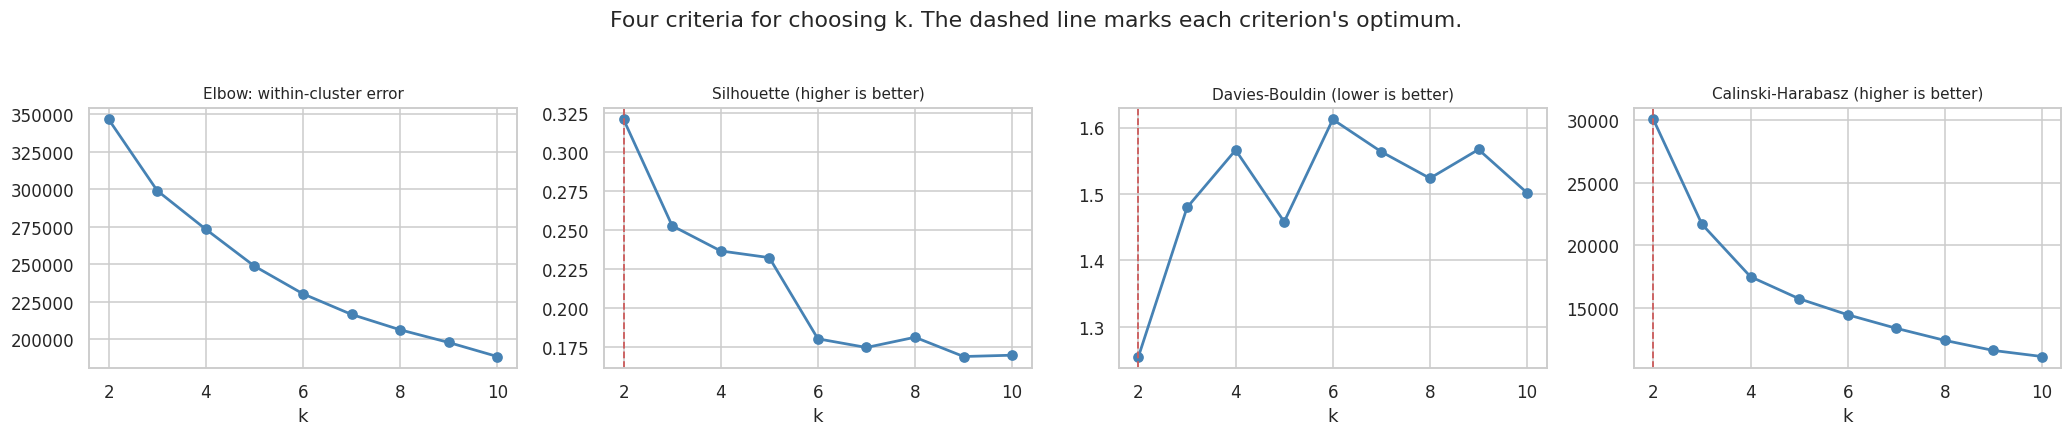

silhouette prefers k = 2
Davies-Bouldin prefers k = 2
Calinski-Harabasz prefers k = 2

Drop in inertia from adding each cluster:
k
3     47503.0
4     25691.0
5     24537.0
6     18461.0
7     13728.0
8     10236.0
9      8446.0
10     9359.0


In [28]:
silhouette_sample = np.random.RandomState(RANDOM_STATE).choice(len(scaled_matrix), 10000,
                                                               replace=False)
selection_rows = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(scaled_matrix)
    selection_rows.append({
        'k':                  k,
        'inertia':            kmeans.inertia_,
        'silhouette':         silhouette_score(scaled_matrix[silhouette_sample],
                                               kmeans.labels_[silhouette_sample]),
        'davies_bouldin':     davies_bouldin_score(scaled_matrix, kmeans.labels_),
        'calinski_harabasz':  calinski_harabasz_score(scaled_matrix, kmeans.labels_),
    })
model_selection = pd.DataFrame(selection_rows).set_index('k')
display(model_selection.round(4))

fig, axes = plt.subplots(1, 4, figsize=(19, 3.8))
for ax, (column, title, best) in zip(axes, [
        ('inertia', 'Elbow: within-cluster error', None),
        ('silhouette', 'Silhouette (higher is better)', 'max'),
        ('davies_bouldin', 'Davies-Bouldin (lower is better)', 'min'),
        ('calinski_harabasz', 'Calinski-Harabasz (higher is better)', 'max')]):
    ax.plot(model_selection.index, model_selection[column], 'o-', color='steelblue', lw=1.8)
    if best == 'max':
        ax.axvline(model_selection[column].idxmax(), color='indianred', ls='--', lw=1.2)
    elif best == 'min':
        ax.axvline(model_selection[column].idxmin(), color='indianred', ls='--', lw=1.2)
    ax.set_xlabel('k')
    ax.set_title(title, fontsize=10)
plt.suptitle('Four criteria for choosing k. The dashed line marks each criterion\'s optimum.',
             y=1.04)
plt.tight_layout()
plt.show()

print('silhouette prefers k =', int(model_selection['silhouette'].idxmax()))
print('Davies-Bouldin prefers k =', int(model_selection['davies_bouldin'].idxmin()))
print('Calinski-Harabasz prefers k =', int(model_selection['calinski_harabasz'].idxmax()))
print('\nDrop in inertia from adding each cluster:')
print((-model_selection['inertia'].diff()).dropna().round(0).to_string())

All three criteria agree on k = 2, and the silhouette at that point is only 0.321, which is
weak. The elbow gives no help either: the inertia falls by 47,503 going to k = 3, then by
25,691, 24,537 and 18,461, a smooth decay with no bend. The lecture describes the elbow as
"diminishing returns, not a magical answer", and here there is not even a clear elbow.

This says the data does not contain a natural number of clusters. The agreement of the three
metrics on the smallest possible k, combined with a low silhouette, is the signature of a
continuum being cut in half rather than of two real groups.

I nevertheless fit k = 4 and examine it, for a specific reason: the question the brief asks is
whether the clusters have a meaningful real-world interpretation, and k = 2 only separates big
stones from small ones, which I already knew from PC1. Four is a deliberate choice for
interpretability, not a metric-driven one.

In [29]:
CHOSEN_K = 4
kmeans_model = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_STATE).fit(scaled_matrix)
diamonds_df['kmeans_cluster'] = kmeans_model.labels_

cluster_profile = diamonds_df.groupby('kmeans_cluster').agg(
    n=('carat', 'size'),
    carat=('carat', 'mean'),
    price=('price', 'mean'),
    x_mm=('x', 'mean'),
    depth=('depth', 'mean'),
    table=('table', 'mean'),
    cut_rank=('cut_rank', 'mean'),
    color_rank=('color_rank', 'mean'),
    clarity_rank=('clarity_rank', 'mean'))
display(cluster_profile.round(2))

print('Share of each cut grade inside each cluster:')
display(pd.crosstab(diamonds_df['kmeans_cluster'], diamonds_df['cut'],
                    normalize='index').round(3))

,n,carat,price,x_mm,depth,table,cut_rank,color_rank,clarity_rank
kmeans_cluster,,,,,,,,,
0,23497,0.40,1113.20,4.71,61.57,56.88,3.30,3.79,3.84
1,16317,0.99,4981.19,6.38,61.24,57.78,3.12,3.20,2.52
2,6644,1.74,12261.30,7.68,61.73,58.11,2.76,2.40,2.41
3,7482,0.79,3105.61,5.78,63.45,58.00,1.31,3.54,2.30


Share of each cut grade inside each cluster:


cut,Fair,Good,Ideal,Premium,Very Good
kmeans_cluster,,,,,
0,0.002,0.030,0.552,0.229,0.187
1,0.009,0.038,0.411,0.357,0.185
2,0.034,0.096,0.281,0.359,0.229
3,0.160,0.394,0.001,0.025,0.421


This cell shows the clusters on the PCA projection, as the assignment requires, and in the
original carat and price plane.

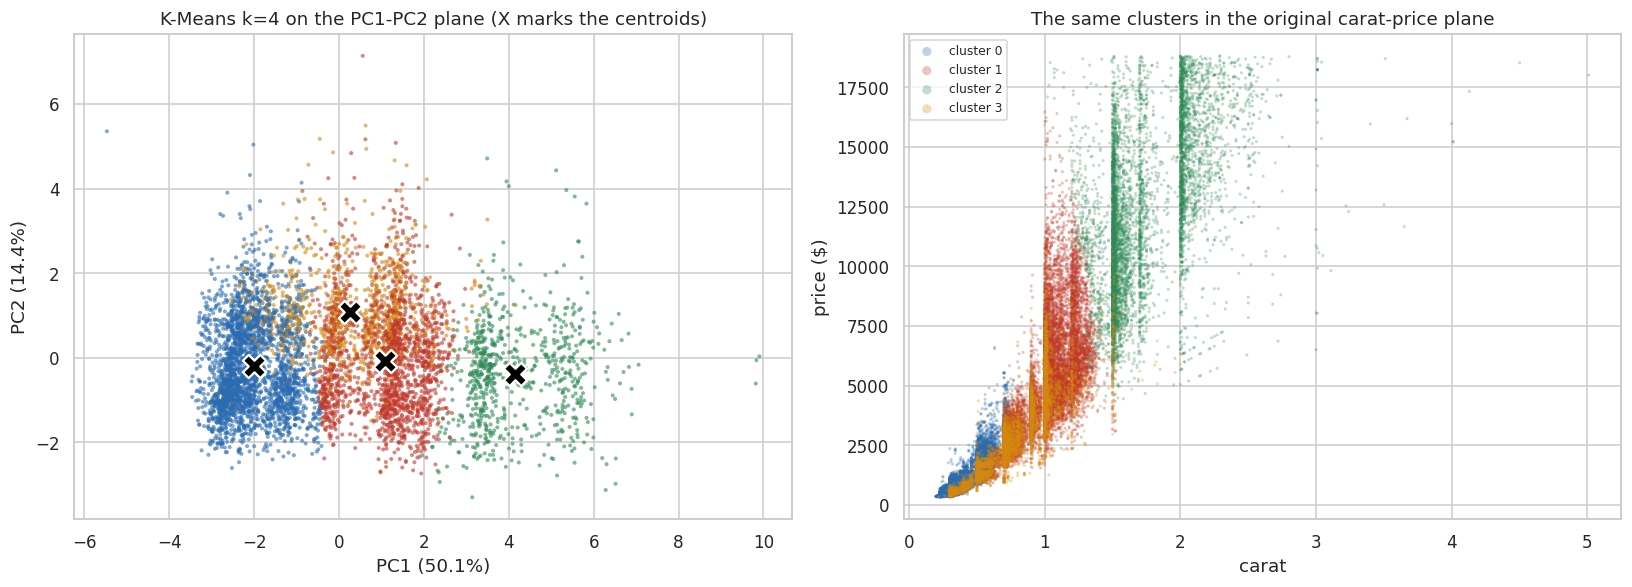

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

palette = np.array(['#2b6cb0', '#c0392b', '#2e8b57', '#d68910'])
axes[0].scatter(scores[plot_sample, 0], scores[plot_sample, 1],
                c=palette[kmeans_model.labels_[plot_sample]], s=7, alpha=0.6,
                edgecolors='none')
centroids_in_pc = pca_full.transform(kmeans_model.cluster_centers_)
axes[0].scatter(centroids_in_pc[:, 0], centroids_in_pc[:, 1], marker='X', s=230,
                c='black', edgecolors='white', linewidths=1.5, zorder=5)
axes[0].set_xlabel(f'PC1 ({explained_ratio[0] * 100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_ratio[1] * 100:.1f}%)')
axes[0].set_title('K-Means k=4 on the PC1-PC2 plane (X marks the centroids)')

for cluster_id in range(CHOSEN_K):
    members = diamonds_df['kmeans_cluster'] == cluster_id
    axes[1].scatter(diamonds_df.loc[members, 'carat'], diamonds_df.loc[members, 'price'],
                    s=4, alpha=0.3, color=palette[cluster_id], label=f'cluster {cluster_id}',
                    edgecolors='none')
axes[1].set_xlabel('carat')
axes[1].set_ylabel('price ($)')
axes[1].set_title('The same clusters in the original carat-price plane')
axes[1].legend(fontsize=8, markerscale=3)
plt.tight_layout()
plt.show()

This cell refits K-Means with five different seeds and on three half samples, and measures the
agreement between the partitions with the adjusted Rand index.

In [31]:
stability_rows = []
reference_labels = kmeans_model.labels_
for seed in range(1, 6):
    other = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=seed).fit_predict(scaled_matrix)
    stability_rows.append({'comparison': f'seed {seed} vs seed {RANDOM_STATE}',
                           'adjusted_rand': adjusted_rand_score(reference_labels, other)})

subsample_rng = np.random.RandomState(RANDOM_STATE)
for trial in range(3):
    half = subsample_rng.choice(len(scaled_matrix), len(scaled_matrix) // 2, replace=False)
    refit = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_STATE).fit(scaled_matrix[half])
    stability_rows.append({
        'comparison': f'half-sample {trial + 1} relabelled onto the full fit',
        'adjusted_rand': adjusted_rand_score(reference_labels[half],
                                             refit.predict(scaled_matrix[half]))})
display(pd.DataFrame(stability_rows).set_index('comparison').round(4))

,adjusted_rand
comparison,
seed 1 vs seed 42,0.9788
seed 2 vs seed 42,0.9603
seed 3 vs seed 42,0.9688
seed 4 vs seed 42,0.9960
seed 5 vs seed 42,0.9775
half-sample 1 relabelled onto the full fit,0.9602
half-sample 2 relabelled onto the full fit,0.5134
half-sample 3 relabelled onto the full fit,0.6284


Strengths and weaknesses of K-Means here.
It is fast, it scales to all 53,940 rows in about a second, and every point gets a label. The
stability table is the informative part, and it reads in two halves. Across seeds the partition
is highly reproducible, with adjusted Rand indices from 0.960 to 0.996, so K-Means++ with ten
restarts is reliably finding the same optimum and the result is not an initialisation artefact.
Across half-samples it is much shakier: 0.960, 0.513 and 0.628. Refitting on half the stones
moves real boundaries.

That gap matters. Seed stability only says the optimiser is consistent; subsample stability
asks whether the structure is in the data, and that is the one that fails here. A partition of
genuinely separated groups would survive halving the sample almost unchanged. This is the third
independent sign, after the weak silhouette and the smooth elbow, that I am cutting a
continuum.

Its other weaknesses are exactly the ones the lecture lists. It required me to choose k when
the data does not suggest one; it assumes spherical clusters of similar size, and it produced
clusters of 23,497 and 6,644 stones; and because it minimises squared distance it is pulled by
the extreme records I found in section 2.

Do the clusters have a meaningful real-world interpretation?
Three of the four do, and the fourth is the interesting one.

Cluster 0, with 23,497 stones averaging 0.40 carat at $1,113, is the mass market: small, mostly
Ideal cut, the stones in an ordinary engagement ring. Cluster 1, with 16,317 stones averaging
0.99 carat at $4,981, is the one-carat segment, the classic target weight. Cluster 2, with
6,644 stones averaging 1.74 carat at $12,261, is the luxury end.

Cluster 3 is the interesting one. It holds 7,482 stones averaging 0.79 carat at $3,106, so by
size it sits between clusters 0 and 1, but it is not a size band at all. Its mean depth is
63.45 against roughly 61.5 everywhere else, its mean cut rank is 1.31 against 2.76 to 3.30
elsewhere, and 55.4 percent of it is Fair or Good cut while Ideal is 0.1 percent. This is a
badly cut segment: stones cut too deep, which wastes weight and costs value.

So the algorithm recovered three price tiers plus one genuine quality group. That is a
defensible commercial segmentation. The credit due is limited: PC1 is size, and the first three
clusters are PC1 sliced into three, so most of what K-Means "found" is the single dominant
direction I already had from PCA.

4.2  DBSCAN

Mathematical intuition.
DBSCAN defines clusters as dense regions. A point is a core point if at least MinPts points lie
within radius eps of it. Core points that are within eps of each other are chained into the
same cluster, border points lie inside the neighbourhood of a core point without being core
themselves, and everything left over is labelled noise. It does not need k in advance and it
can follow irregular shapes, because it grows clusters by connectivity rather than fitting
centres.

Assumptions.
The critical one is that clusters are separated by regions of genuinely lower density, and that
a single pair (eps, MinPts) describes the whole dataset. If different parts of the data have
different densities, no single eps can work everywhere.

I choose eps the standard way, by sorting the distance from each point to its k-th nearest
neighbour and looking for the knee.

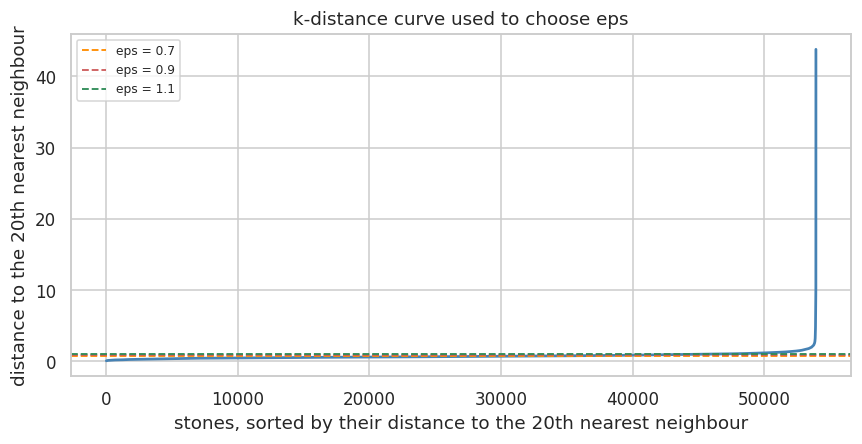

  50th percentile of the 20th-neighbour distance = 0.691
  80th percentile of the 20th-neighbour distance = 0.944
  90th percentile of the 20th-neighbour distance = 1.115
  95th percentile of the 20th-neighbour distance = 1.297
  99th percentile of the 20th-neighbour distance = 1.820


In [32]:
MIN_POINTS = 20
neighbour_model = NearestNeighbors(n_neighbors=MIN_POINTS + 1).fit(scaled_matrix)
neighbour_distances, _ = neighbour_model.kneighbors(scaled_matrix)
kth_distance = np.sort(neighbour_distances[:, MIN_POINTS])

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(np.arange(len(kth_distance)), kth_distance, color='steelblue', lw=1.8)
for eps_line, colour in [(0.7, 'darkorange'), (0.9, 'indianred'), (1.1, 'seagreen')]:
    ax.axhline(eps_line, color=colour, ls='--', lw=1.2, label=f'eps = {eps_line}')
ax.set_xlabel('stones, sorted by their distance to the 20th nearest neighbour')
ax.set_ylabel(f'distance to the {MIN_POINTS}th nearest neighbour')
ax.set_title('k-distance curve used to choose eps')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for percentile in [50, 80, 90, 95, 99]:
    print(f'  {percentile}th percentile of the {MIN_POINTS}th-neighbour distance = '
          f'{np.percentile(kth_distance, percentile):.3f}')

This cell sweeps eps rather than reporting a single run, because DBSCAN is very sensitive to
it.

In [33]:
dbscan_rows = []
for eps in [0.5, 0.7, 0.9, 1.1, 1.3, 1.5]:
    labels = DBSCAN(eps=eps, min_samples=MIN_POINTS).fit_predict(scaled_matrix)
    cluster_ids = set(labels) - {-1}
    sizes = pd.Series(labels[labels >= 0]).value_counts()
    dbscan_rows.append({
        'eps':               eps,
        'clusters':          len(cluster_ids),
        'noise_points':      int((labels == -1).sum()),
        'noise_pct':         100 * (labels == -1).mean(),
        'largest_cluster_pct': 100 * sizes.iloc[0] / len(labels) if len(cluster_ids) else 0.0,
    })
dbscan_sweep = pd.DataFrame(dbscan_rows).set_index('eps')
display(dbscan_sweep.round(2))

DBSCAN_EPS = 0.9
dbscan_labels = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_POINTS).fit_predict(scaled_matrix)
diamonds_df['dbscan_cluster'] = dbscan_labels
print(f'At eps = {DBSCAN_EPS}: {len(set(dbscan_labels) - {-1})} clusters, '
      f'{int((dbscan_labels == -1).sum())} noise points '
      f'({100 * (dbscan_labels == -1).mean():.2f}%)')

,clusters,noise_points,noise_pct,largest_cluster_pct
eps,,,,
0.5,142,35530,65.87,1.86
0.7,10,16219,30.07,36.34
0.9,7,5803,10.76,88.73
1.1,2,1914,3.55,96.41
1.3,1,813,1.51,98.49
1.5,1,384,0.71,99.29


At eps = 0.9: 7 clusters, 5803 noise points (10.76%)


This cell shows the DBSCAN result on the same PCA projection, and how the result moves with
eps.

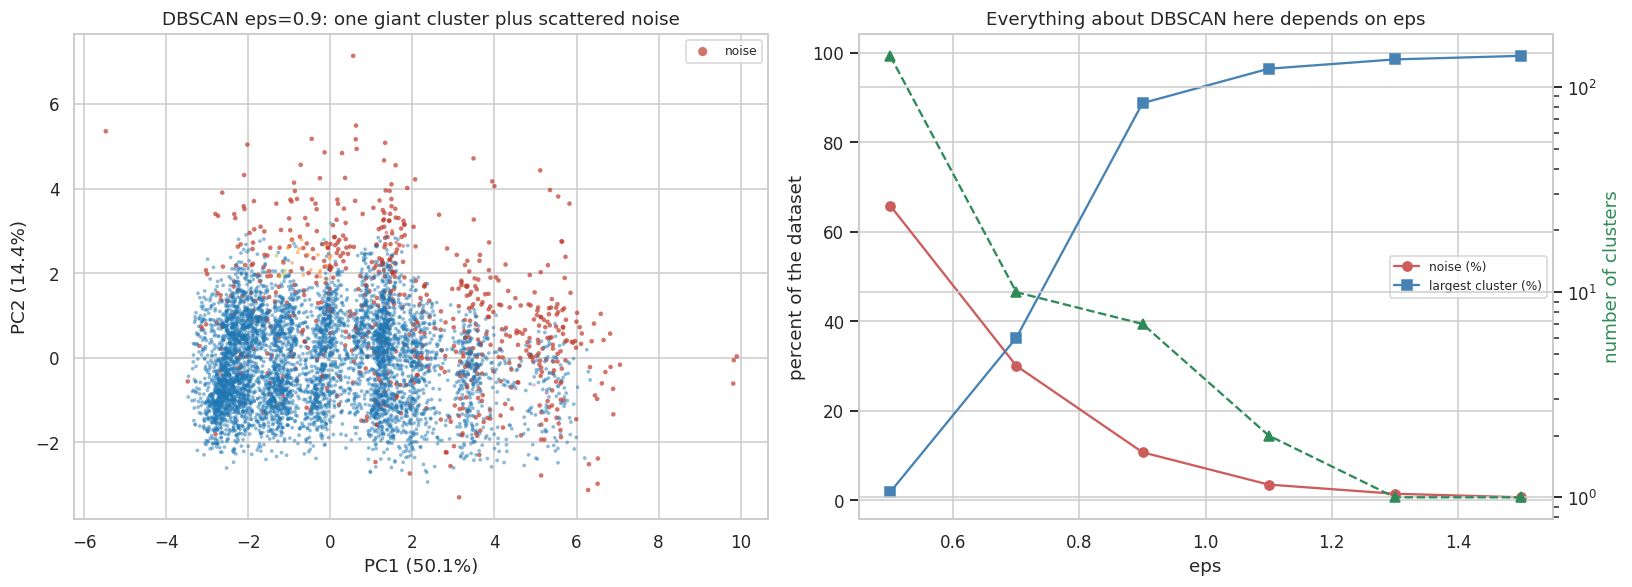

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

noise_mask = dbscan_labels[plot_sample] == -1
axes[0].scatter(scores[plot_sample][noise_mask, 0], scores[plot_sample][noise_mask, 1],
                s=9, color='#c0392b', alpha=0.7, label='noise', edgecolors='none')
axes[0].scatter(scores[plot_sample][~noise_mask, 0], scores[plot_sample][~noise_mask, 1],
                s=6, c=dbscan_labels[plot_sample][~noise_mask], cmap='tab10', alpha=0.5,
                edgecolors='none')
axes[0].set_xlabel(f'PC1 ({explained_ratio[0] * 100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_ratio[1] * 100:.1f}%)')
axes[0].set_title(f'DBSCAN eps={DBSCAN_EPS}: one giant cluster plus scattered noise')
axes[0].legend(fontsize=8, markerscale=2)

axes[1].plot(dbscan_sweep.index, dbscan_sweep['noise_pct'], 'o-', color='indianred',
             label='noise (%)')
axes[1].plot(dbscan_sweep.index, dbscan_sweep['largest_cluster_pct'], 's-', color='steelblue',
             label='largest cluster (%)')
secondary = axes[1].twinx()
secondary.plot(dbscan_sweep.index, dbscan_sweep['clusters'], '^--', color='seagreen',
               label='number of clusters')
secondary.set_ylabel('number of clusters', color='seagreen')
secondary.set_yscale('log')
axes[1].set_xlabel('eps')
axes[1].set_ylabel('percent of the dataset')
axes[1].set_title('Everything about DBSCAN here depends on eps')
axes[1].legend(fontsize=8, loc='center right')
plt.tight_layout()
plt.show()

This cell profiles the DBSCAN clusters and scores the partition with the same metrics used for
K-Means.

In [35]:
dbscan_core = dbscan_labels >= 0
dbscan_profile = diamonds_df[dbscan_core].groupby(dbscan_labels[dbscan_core]).agg(
    n=('carat', 'size'),
    carat=('carat', 'mean'),
    price=('price', 'mean'),
    depth=('depth', 'mean'),
    table=('table', 'mean'),
    cut_rank=('cut_rank', 'mean'),
    color_rank=('color_rank', 'mean'),
    clarity_rank=('clarity_rank', 'mean'))
dbscan_profile['share_of_data_%'] = 100 * dbscan_profile['n'] / len(diamonds_df)
print('DBSCAN clusters at eps =', DBSCAN_EPS, '(label -1, the noise, excluded)')
display(dbscan_profile.round(2))

noise_stones = diamonds_df[dbscan_labels == -1]
print(f'The {len(noise_stones)} noise points: mean carat {noise_stones["carat"].mean():.2f}, '
      f'mean price {noise_stones["price"].mean():,.0f}, '
      f'{100 * (noise_stones["carat"] > 2).mean():.1f}% above 2 carat')
print(f'They contain {len(set(noise_stones.index) & set(defective_rows))} '
      f'of the {len(defective_rows)} physically defective records from section 2')

metric_sample = np.random.RandomState(RANDOM_STATE).choice(
    np.where(dbscan_core)[0], min(10000, int(dbscan_core.sum())), replace=False)
print('\nQuality of the DBSCAN partition, computed on the non-noise points only:')
print('  silhouette        ', round(silhouette_score(scaled_matrix[metric_sample],
                                                     dbscan_labels[metric_sample]), 4))
print('  Davies-Bouldin    ', round(davies_bouldin_score(scaled_matrix[dbscan_core],
                                                         dbscan_labels[dbscan_core]), 4))
print('  Calinski-Harabasz ', round(calinski_harabasz_score(scaled_matrix[dbscan_core],
                                                            dbscan_labels[dbscan_core]), 1))
print('  (for comparison, K-Means at k=4 scored silhouette',
      round(model_selection.loc[CHOSEN_K, 'silhouette'], 4), ')')

DBSCAN clusters at eps = 0.9 (label -1, the noise, excluded)


,n,carat,price,depth,table,cut_rank,color_rank,clarity_rank,share_of_data_%
0,47860,0.75,3558.49,61.80,57.20,3.08,3.45,3.08,88.73
1,173,0.57,1912.66,59.92,61.29,1.00,4.03,3.67,0.32
2,22,1.01,5155.27,58.15,61.00,1.00,5.05,1.86,0.04
3,22,1.51,9211.23,60.03,60.09,2.00,1.32,2.59,0.04
4,8,2.04,12362.25,62.74,57.38,2.00,0.00,2.00,0.01
5,29,0.50,1218.90,65.08,57.96,0.00,4.76,2.17,0.05
6,23,0.69,2458.35,57.92,60.92,1.00,4.91,2.35,0.04


The 5803 noise points: mean carat 1.21, mean price 7,063, 14.8% above 2 carat
They contain 27 of the 27 physically defective records from section 2

Quality of the DBSCAN partition, computed on the non-noise points only:


  silhouette         -0.0551
  Davies-Bouldin     1.0007
  Calinski-Harabasz  68.5
  (for comparison, K-Means at k=4 scored silhouette 0.2366 )


What DBSCAN found, and why it is a negative result.
There is no stable answer. At eps = 0.5 it produces 142 clusters and calls 65.9 percent of the
data noise. At eps = 0.9 it produces 7 clusters, but one of them holds 88.7 percent of the
stones. At eps = 1.3 everything merges into a single cluster with 1.5 percent noise. Between
those settings the number of clusters falls from 142 to 1 without ever passing through a stable
plateau.

That pattern is the diagnosis. DBSCAN assumes clusters are separated by sparse regions, and it
is telling me there are none: the density falls off smoothly from the middle of the cloud
outwards, so as I widen eps the whole dataset simply absorbs itself. This is consistent with
the PCA picture and with the weak silhouette. It is a real finding rather than a failed run,
and it is the clearest evidence in the notebook that this data is a continuum.

Do its clusters have a real-world interpretation?
Only one of them does, and the other six are an artefact worth understanding. Cluster 0 holds
47,860 stones, 88.7 percent of the file, with a mean of 0.75 carats at $3,558 - it is simply
"the diamond market", the whole continuous cloud absorbed into one blob, and it has no
interpretation beyond that. The remaining six clusters hold between 8 and 173 stones each.
Reading their profiles, every one of them has a constant cut rank: exactly 1.00 in clusters 1,
2 and 6, exactly 2.00 in clusters 3 and 4, exactly 0.00 in cluster 5, and cluster 4
additionally has a colour rank of exactly 0.00. These are not density-separated regions of
diamond space. They are pockets created by my own ordinal encoding: stones that share an
identical combination of discrete grades coincide exactly in three of the ten coordinates,
which makes them artificially close and lets DBSCAN chain them into a tiny cluster. DBSCAN
found structure in my encoding rather than in the diamonds, so these six are not market
segments.

The metrics confirm it.
The silhouette of the DBSCAN partition is -0.055, which is negative: on average a stone is
closer to a cluster it was not assigned to than to its own. Its Calinski-Harabasz score is 68.5
against 17,509 for K-Means at k = 4. By every measure this is a worse partition than the one I
already described as weak.

But the noise label is the most useful output in this section.
The 5,803 points DBSCAN refused to assign contain all 27 of the physically defective records
from section 2, while being only 10.8 percent of the data. DBSCAN was not designed as an
anomaly detector and I gave it no information about the errors, yet its rejection set found
every one of them. That is a genuine result, and it anticipates section 5: what it shares with
LOF is that both judge a point by the density of its immediate neighbourhood, and broken
records land where nothing else lands.

Strengths and weaknesses.
DBSCAN's strengths are genuine even when the partition is poor: it did not require me to choose
k, it marked noise explicitly and that noise was informative, and it would have found non-
spherical shapes if any existed. Its weaknesses are on display: it is extremely sensitive to
eps, it struggles when density varies, its clusters here reflect my encoding rather than the
domain, and of the two methods that can run on all 53,940 stones it is much the slower - the
runtime table in section 6.5 times both, and DBSCAN comes out several times slower than K-Means
at full size, with its cost growing considerably faster than n. The noise label is also useful
in its own right, and I compare it against the anomaly detectors in section 6.

4.3  Hierarchical clustering

Mathematical intuition.
Agglomerative clustering starts with every point as its own cluster and repeatedly merges the
two closest clusters, producing a tree. What "closest" means is set by the linkage: single
linkage uses the nearest pair, complete linkage the farthest pair, average linkage the mean
pairwise distance, and Ward's linkage merges the pair that increases the total within-cluster
sum of squares by the least. I use Ward because it matches the squared-error geometry that
K-Means also uses, which makes the two comparable. Cutting the dendrogram at a height gives a
partition.

Assumptions.
It assumes the data has a nested structure worth reading as a tree, and that merges are
irreversible - once two clusters join they never separate, so an early mistake propagates
upward. The lecture also warns that noise and chaining can strongly affect the result, which is
a real concern given section 2.

A practical constraint.
Agglomerative clustering needs the pairwise distance matrix, which is O(n^2) in memory. For
53,940 stones that is about 23 GB, which does not fit. I therefore run it on a random subsample
of 5,000 stones, roughly 190 MB, and say so rather than quietly changing the dataset. This is
itself part of the scalability comparison the brief asks for in section 6.

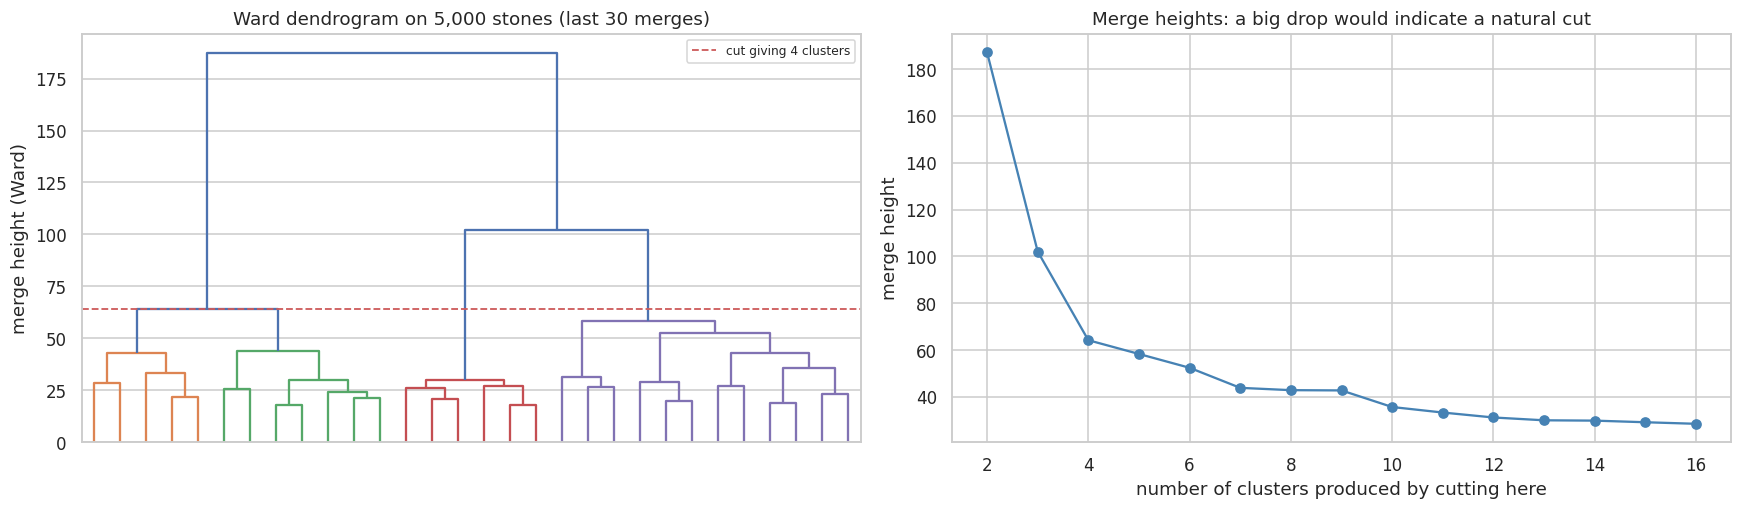

,silhouette,sizes
k,,
2,0.300518,"[2510, 2490]"
3,0.257389,"[2510, 1881, 609]"
4,0.172140,"[1881, 1361, 1149, 609]"
5,0.142059,"[1361, 1345, 1149, 609, 536]"
6,0.149170,"[1361, 1149, 1038, 609, 536, 307]"


In [36]:
HIERARCHY_SIZE = 5000
hierarchy_sample = np.random.RandomState(RANDOM_STATE).choice(len(scaled_matrix),
                                                              HIERARCHY_SIZE, replace=False)
hierarchy_matrix = scaled_matrix[hierarchy_sample]

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

ward_tree = linkage(hierarchy_matrix, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
dendrogram(ward_tree, truncate_mode='lastp', p=30, ax=axes[0],
           color_threshold=ward_tree[-3, 2], no_labels=True)
axes[0].axhline(ward_tree[-3, 2], color='indianred', ls='--', lw=1.2,
                label='cut giving 4 clusters')
axes[0].set_ylabel('merge height (Ward)')
axes[0].set_title(f'Ward dendrogram on {HIERARCHY_SIZE:,} stones (last 30 merges)')
axes[0].legend(fontsize=8)

merge_heights = ward_tree[-15:, 2][::-1]
axes[1].plot(range(2, len(merge_heights) + 2), merge_heights, 'o-', color='steelblue')
axes[1].set_xlabel('number of clusters produced by cutting here')
axes[1].set_ylabel('merge height')
axes[1].set_title('Merge heights: a big drop would indicate a natural cut')
plt.tight_layout()
plt.show()

hierarchy_rows = []
for k in range(2, 7):
    labels = fcluster(ward_tree, k, criterion='maxclust')
    hierarchy_rows.append({'k': k, 'silhouette': silhouette_score(hierarchy_matrix, labels),
                           'sizes': sorted(pd.Series(labels).value_counts().tolist(),
                                           reverse=True)})
display(pd.DataFrame(hierarchy_rows).set_index('k'))

This cell compares the three partitions on exactly the same 5,000 stones with the adjusted Rand
index, and plots them side by side.

,adjusted_rand
pair,
K-Means vs hierarchical,0.4904
K-Means vs DBSCAN,0.0588
hierarchical vs DBSCAN,0.2441


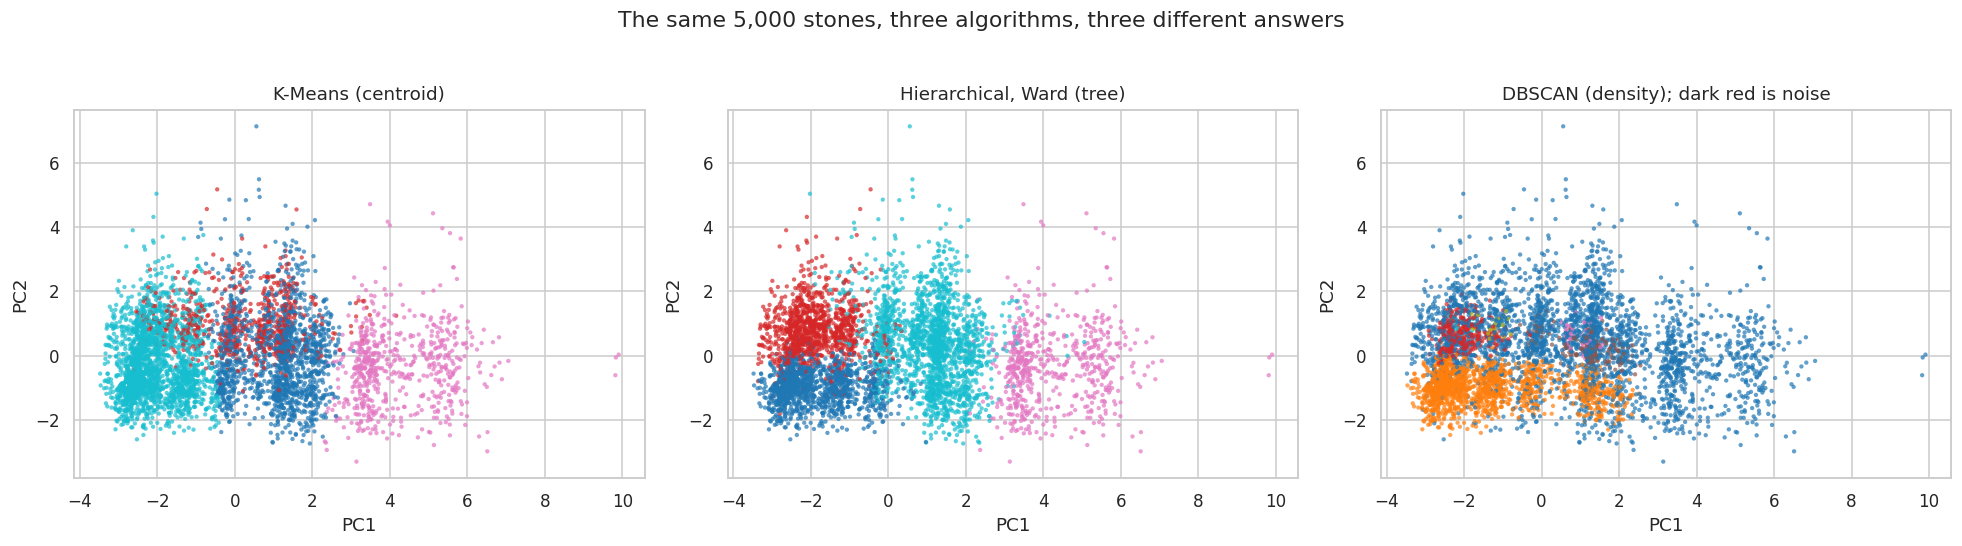

In [37]:
kmeans_on_sample = KMeans(n_clusters=CHOSEN_K, n_init=10,
                          random_state=RANDOM_STATE).fit_predict(hierarchy_matrix)
ward_on_sample = fcluster(ward_tree, CHOSEN_K, criterion='maxclust')
dbscan_on_sample = DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_POINTS).fit_predict(hierarchy_matrix)

agreement = pd.DataFrame([
    {'pair': 'K-Means vs hierarchical',
     'adjusted_rand': adjusted_rand_score(kmeans_on_sample, ward_on_sample)},
    {'pair': 'K-Means vs DBSCAN',
     'adjusted_rand': adjusted_rand_score(kmeans_on_sample, dbscan_on_sample)},
    {'pair': 'hierarchical vs DBSCAN',
     'adjusted_rand': adjusted_rand_score(ward_on_sample, dbscan_on_sample)},
]).set_index('pair')
display(agreement.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
sample_scores = scores[hierarchy_sample]
for ax, (labels, title) in zip(axes, [
        (kmeans_on_sample, 'K-Means (centroid)'),
        (ward_on_sample, 'Hierarchical, Ward (tree)'),
        (dbscan_on_sample, 'DBSCAN (density); dark red is noise')]):
    ax.scatter(sample_scores[:, 0], sample_scores[:, 1], c=labels, cmap='tab10', s=8,
               alpha=0.7, edgecolors='none')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
plt.suptitle('The same 5,000 stones, three algorithms, three different answers', y=1.03)
plt.tight_layout()
plt.show()

This cell profiles the Ward clusters so that they can be read in domain terms.

In [38]:
ward_profile = diamonds_df.iloc[hierarchy_sample].groupby(ward_on_sample).agg(
    n=('carat', 'size'),
    carat=('carat', 'mean'),
    price=('price', 'mean'),
    depth=('depth', 'mean'),
    table=('table', 'mean'),
    cut_rank=('cut_rank', 'mean'),
    color_rank=('color_rank', 'mean'),
    clarity_rank=('clarity_rank', 'mean'))
print(f'Ward clusters at k = {CHOSEN_K}, on the {HIERARCHY_SIZE:,}-stone subsample')
display(ward_profile.round(2))

print('Share of each cut grade inside each Ward cluster:')
display(pd.crosstab(ward_on_sample, diamonds_df.iloc[hierarchy_sample]['cut'],
                    normalize='index').round(3))

Ward clusters at k = 4, on the 5,000-stone subsample


,n,carat,price,depth,table,cut_rank,color_rank,clarity_rank
1,1361,0.45,1405.40,61.77,55.74,3.91,3.60,3.95
2,1149,0.40,1001.91,61.71,58.07,2.34,3.88,3.40
3,609,1.77,12422.91,61.60,58.25,2.72,2.37,2.36
4,1881,0.98,4761.81,61.89,58.01,2.53,3.33,2.33


Share of each cut grade inside each Ward cluster:


cut,Fair,Good,Ideal,Premium,Very Good
row_0,,,,,
1,0.000,0.000,0.939,0.029,0.032
2,0.011,0.138,0.031,0.440,0.380
3,0.026,0.102,0.250,0.378,0.245
4,0.071,0.130,0.259,0.285,0.255


What hierarchical clustering found.
The dendrogram has no dominant gap. The merge heights decline smoothly, so there is no height
at which cutting is obviously right, which agrees with the elbow and the k-distance curve. Its
silhouette is 0.301 at k = 2 and falls to 0.172 at k = 4, the same shape as the K-Means curve
and at the same weak level.

Do its clusters have a real-world interpretation?
Yes, and interestingly a different one from K-Means on the same data. Ward produced: a group of
1,361 small stones averaging 0.45 carats at $1,405 which is 93.9 percent Ideal cut; a second
group of 1,149 stones of almost the same size, 0.40 carats at $1,002, but only 3.1 percent
Ideal and mostly Premium and Very Good; a middle group of 1,881 stones around 0.98 carats at
$4,762; and 609 large stones averaging 1.77 carats at $12,423.

The contrast with K-Means is the point. K-Means cut the data into three price tiers plus one
badly cut group. Ward split the small stones in two by cut quality while leaving the middle and
the top as single blocks. Both are defensible commercial readings - "cheap-and-perfectly-cut
versus cheap-and-ordinary" is a real distinction a retailer would recognise - and the data
supports neither over the other. Two algorithms with the same squared-error objective, run on
identical stones, chose different axes to divide a continuum along, which is precisely why
their adjusted Rand index is 0.49 rather than 1.

Strengths and weaknesses.
Its strength is that it gives the whole nesting at once rather than one partition, so I can see
that the four-cluster solution sits inside the two-cluster one and judge the structure at
several scales without refitting. Its weaknesses are that it cannot be run on the full dataset
at all, that Ward's linkage builds in the same spherical, equal-size preference as K-Means, and
that merges are irreversible.

Agreement between the three methods.
On identical data, K-Means and Ward agree moderately, with an adjusted Rand index of 0.490,
which is unsurprising since both optimise a squared-error criterion. Both agree far less with
DBSCAN: 0.059 against K-Means and 0.244 against Ward, where 0 is chance agreement. Three
reasonable algorithms produce three different answers on the same 5,000 stones, which is the
cleanest demonstration in this notebook that, as the lecture puts it, similarity is a modelling
choice and not an objective fact.

4.4  Evaluating the clusters

The brief asks me to use clustering metrics and specifically to compare the average variance
inside each cluster against the global variance, and then to judge whether that metric is
suitable.

,within_cluster_variance,ratio_to_global,variance_explained
k,,,
2,0.6638,0.6638,0.3362
3,0.5987,0.5987,0.4013
4,0.5531,0.5531,0.4469
5,0.5131,0.5131,0.4869
6,0.4678,0.4678,0.5322
7,0.4266,0.4266,0.5734
8,0.4013,0.4013,0.5987
9,0.4047,0.4047,0.5953
10,0.3747,0.3747,0.6253


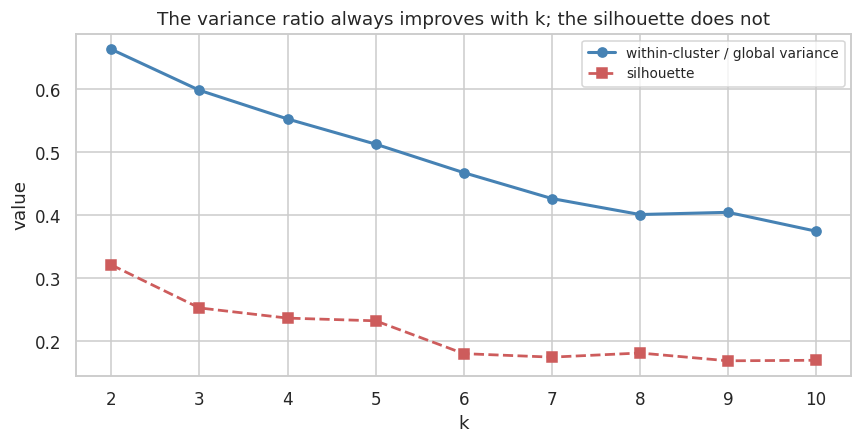

Global mean variance on the standardised scale: 1.0


In [39]:
global_variance = scaled_matrix.var(axis=0).mean()
variance_rows = []
for k in range(2, 11):
    labels = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(scaled_matrix)
    within = np.mean([scaled_matrix[labels == c].var(axis=0).mean() for c in np.unique(labels)])
    variance_rows.append({'k': k, 'within_cluster_variance': within,
                          'ratio_to_global': within / global_variance,
                          'variance_explained': 1 - within / global_variance})
variance_comparison = pd.DataFrame(variance_rows).set_index('k')
display(variance_comparison.round(4))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(variance_comparison.index, variance_comparison['ratio_to_global'], 'o-',
        color='steelblue', lw=2, label='within-cluster / global variance')
ax.plot(model_selection.index, model_selection['silhouette'], 's--', color='indianred',
        lw=1.8, label='silhouette')
ax.set_xlabel('k')
ax.set_ylabel('value')
ax.set_title('The variance ratio always improves with k; the silhouette does not')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Global mean variance on the standardised scale:', round(float(global_variance), 4))

Is the within-cluster versus global variance metric suitable?

No, not on its own, and the table shows exactly why.
The ratio falls steadily as k grows: 0.664 at k = 2, 0.553 at k = 4, 0.468 at k = 6 and 0.375
at k = 10. It keeps falling, and it reaches zero when every stone is its own cluster. A
quantity that improves as I add clusters cannot be used to choose the number of clusters,
because its optimum is always the most complicated model available. (The one exception in the
table, a rise from 0.4013 at k = 8 to 0.4047 at k = 9, is not a counter-example: that is
K-Means settling into a worse local optimum, which shows the criterion is noisy as well as
monotone.)

There is a second and deeper problem, which the lecture raises directly in the slide on using
ANOVA after clustering. The ratio is a comparison of between-cluster to within-cluster
variance, and K-Means built the clusters by minimising precisely that within-cluster variance.
So a good score is guaranteed by construction. It is not independent validation; it measures
how hard the optimiser worked, not whether the structure is real. It describes a partition; it
does not confirm one.

What I use instead.
Three alternatives, which is also why I computed all of them above:

The silhouette, s = (b - a) / max(a, b), compares each point's average distance to its own
cluster against its distance to the nearest other cluster. Because it balances cohesion against
separation it does not reward splitting for its own sake, and it correctly declines as k rises
here.

Davies-Bouldin measures cluster overlap relative to compactness and Calinski-Harabasz is a
between-to-within dispersion ratio adjusted for the number of clusters. Both penalise over-
splitting, which is exactly what the variance ratio fails to do.

Stability is the third, and no internal index captures it: refitting on different seeds and on
half-samples and checking whether the same partition comes back. This one is the strongest of
the three, because a structure that does not reproduce is not a structure.

Applying them all gives a consistent and unflattering answer. Every index points at k = 2 with
a silhouette near 0.32, which means the partition is weak however it is measured. The variance
ratio would have hidden that by rewarding me for using more clusters.

4.5  Clustering the feature space

Here I cluster the transpose of the data matrix, so that the objects being grouped are the ten
features rather than the 53,940 stones. Correlation is the natural similarity between two
features, so I use the distance 1 - |correlation|: two features are close when they carry the
same information, whatever the sign.

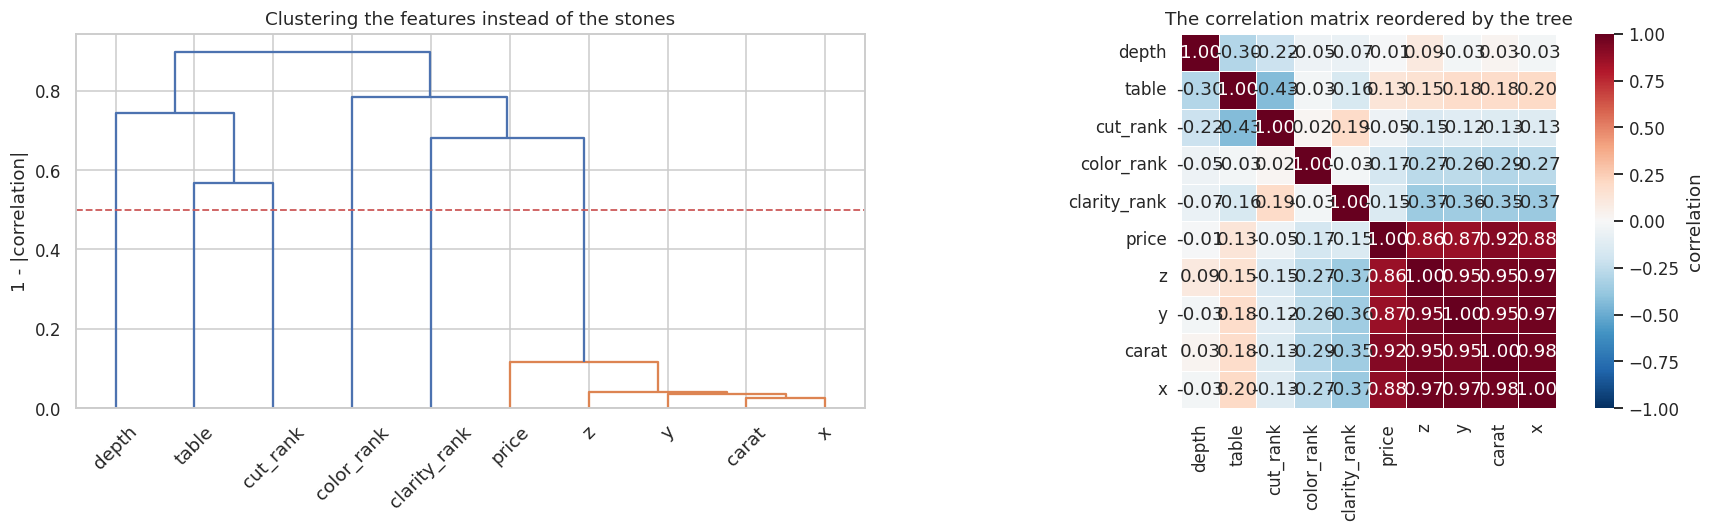

k = 2:  {carat, price, x, y, z, color_rank, clarity_rank}   |   {depth, table, cut_rank}
k = 3:  {carat, price, x, y, z, clarity_rank}   |   {depth, table, cut_rank}   |   {color_rank}
k = 4:  {carat, price, x, y, z, clarity_rank}   |   {depth}   |   {table, cut_rank}   |   {color_rank}


In [40]:
from scipy.spatial.distance import squareform

feature_correlation = pd.DataFrame(scaled_matrix, columns=FEATURES).corr()
feature_distance = 1 - feature_correlation.abs()
feature_tree = linkage(squareform(feature_distance.to_numpy(), checks=False), method='average')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
dendrogram(feature_tree, labels=FEATURES, ax=axes[0], color_threshold=0.5)
axes[0].axhline(0.5, color='indianred', ls='--', lw=1.2)
axes[0].set_ylabel('1 - |correlation|')
axes[0].set_title('Clustering the features instead of the stones')
axes[0].tick_params(axis='x', rotation=45)

order = dendrogram(feature_tree, no_plot=True)['leaves']
sns.heatmap(feature_correlation.iloc[order, order], annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'correlation'})
axes[1].set_title('The correlation matrix reordered by the tree')
plt.tight_layout()
plt.show()

for k in [2, 3, 4]:
    membership = fcluster(feature_tree, k, criterion='maxclust')
    groups = {}
    for feature_name, group_id in zip(FEATURES, membership):
        groups.setdefault(group_id, []).append(feature_name)
    formatted = '   |   '.join('{' + ', '.join(names) + '}' for names in groups.values())
    print(f'k = {k}:  {formatted}')

This cell regresses each feature on the other nine. The R^2 measures directly how much of that
feature is already carried by the rest.

In [41]:
from sklearn.linear_model import LinearRegression

redundancy_rows = []
for index, feature_name in enumerate(FEATURES):
    others = [j for j in range(len(FEATURES)) if j != index]
    model = LinearRegression().fit(scaled_matrix[:, others], scaled_matrix[:, index])
    redundancy_rows.append({
        'feature': feature_name,
        'R2_from_the_other_nine': model.score(scaled_matrix[:, others], scaled_matrix[:, index]),
        'max_abs_corr_with_another': feature_correlation[feature_name].drop(feature_name).abs().max(),
    })
redundancy = pd.DataFrame(redundancy_rows).set_index('feature').sort_values(
    'R2_from_the_other_nine', ascending=False)
display(redundancy.round(4))

,R2_from_the_other_nine,max_abs_corr_with_another
feature,,
x,0.9826,0.9751
carat,0.9747,0.9751
z,0.9575,0.9708
y,0.9511,0.9747
price,0.9070,0.9216
depth,0.4212,0.2958
clarity_rank,0.4078,0.3720
table,0.3684,0.4334
cut_rank,0.3316,0.4334


What clustering the feature space revealed

What information it gives.
Clustering the samples answers "which stones resemble each other"; clustering the features
answers "which measurements are saying the same thing". That second question is about the
design of the dataset rather than its contents, and it is answered once for the whole file
instead of per row.

Groups of related or redundant features.
The tree splits cleanly into two blocks at k = 2. The first is {carat, price, x, y, z} together
with the two stone-quality grades, and the second is {depth, table, cut_rank}. The
interpretation is immediate: the first block is how big and how valuable the stone is, the
second is how it was cut. The regression table sharpens this. x is 98.3 percent predictable
from the other nine features, carat 97.5 percent, z 95.8 percent and y 95.1 percent, so those
columns are almost pure duplication. At k = 4 the size block stays welded together while depth
splits off entirely on its own and table pairs with cut_rank, which is sensible because table
width is one of the things a cut grade is judged on.

Features that appear isolated.
color_rank is the first feature to break away: it is still inside the large block at k = 2, but
from k = 3 onwards it stands entirely alone. Its largest absolute correlation with anything
else is 0.291 and only 24 percent of it is recoverable from the other nine columns, the lowest
figure in the table. depth is the second isolate. Both findings match the Cramer's V values
from section 2, where the three grades were nearly independent of one another.

Did this show me anything the sample clustering did not?
Yes, and it is the most useful result in this section. Clustering the stones produced three
price tiers, which PC1 had already told me. Clustering the features told me why PC1 dominates -
five of my ten columns are one measurement wearing five hats - and it identified precisely
which columns could be dropped with almost no loss and which could not be dropped at all.
Sample clustering describes the rows; feature clustering criticises the columns. It is also the
only analysis in the notebook that points at a concrete action: a model built on this data
should keep carat and discard x, y and z.

Where clustering features is particularly useful.
Anywhere features are numerous, cheap to record and likely to overlap. In genomics, co-
expressed genes group into modules that act together. In sensor networks and IoT, clustering
the channels shows which sensors are redundant, which is directly a question about how many to
install. In finance, clustering returns groups instruments that move together, which is the
basis of risk factor models. In survey design, clustering items reveals which questions are
asking the same thing twice. In each case the payoff is the same as here: it tells you about
the measuring instrument rather than about the thing measured.

4.6  Discussion of the clustering results

Why different algorithms produce different clusters.
Because each one encodes a different definition of what a cluster is, and the data does not
contain a structure strong enough to force them to agree. K-Means defines a cluster as a set of
points near a common centre and must assign every point; DBSCAN defines it as a connected dense
region and may refuse to assign a point at all; Ward defines it as a merge that costs the least
additional squared error. On this data those three definitions gave adjusted Rand indices of
0.490, 0.059 and 0.244 against one another. When data contains well separated groups, all three
find them and agree. Disagreement of this size is evidence about the data, not about the
algorithms.

Sensitivity to hyperparameters.
The three methods are not equally fragile, and that is worth stating precisely. K-Means is very
stable with respect to its initialisation, with adjusted Rand indices of 0.960 to 0.996 across
seeds, but only moderately stable with respect to the sample, where half-sample refits gave
0.960, 0.513 and 0.628. So its fragility is not in the optimiser; it is in the choice of k and
in the fact that the boundaries it draws are not pinned down by the data. DBSCAN was the
opposite: holding MinPts at 20 and moving eps from 0.5 to 1.3 took the result from 142 clusters
with 66 percent noise to a single cluster with 1.5 percent noise. Hierarchical clustering is
sensitive to the choice of linkage: single linkage produces a visibly different tree, because
it chains through the continuum.

Cluster geometry.
The PCA projections show why nothing worked cleanly. The cloud is a single wedge that broadens
as stones get larger, with the badly cut stones forming a thin arm off one side. It is
elongated, of varying density, and has no gaps. K-Means imposed spherical cells on it, which is
why its boundaries fall in the middle of dense regions where no boundary belongs.

Density-based against centroid-based.
This dataset is a clean illustration of the trade-off. The centroid approach always returns an
answer, which is convenient and also dangerous, because it returns exactly as confident-looking
an answer on structureless data as on real clusters. The density approach can report that there
is nothing there, which is what DBSCAN effectively did, and that is the more useful answer -
but it needs eps, and choosing eps on data with smoothly varying density is close to
impossible. Neither dominates: the centroid method gave me a usable commercial segmentation,
and the density method gave me the correct scientific conclusion.

Situations where clustering may fail.
This dataset demonstrates several at once. It fails when the variation is continuous rather
than grouped, as here, where clusters do not exist and any partition is a convenience. It fails
when density varies smoothly, which breaks DBSCAN's single-eps assumption. It fails when
features are on different scales, which I avoided by standardising. It fails when the geometry
does not match the assumed shape. And it fails quietly when someone reports k = 4 without
mentioning that the silhouette was 0.237, which is the failure mode I have tried hardest to
avoid here.

One result from this section that turned out to matter later.
DBSCAN's noise label - the 5,803 stones it refused to place in any cluster - contains all 27 of
the physically defective records. A clustering algorithm, given no information about data
quality, produced a better error-detection signal than Isolation Forest manages in section 5.
That is the clearest illustration of the lecture's remark that small or isolated groups can
signal unusual behaviour. The caveat the lecture attaches holds here too: 5,776 of those 5,803
stones are perfectly fine, so rare is not the same as wrong.

My overall conclusion for this section.
The most defensible reading is that the diamonds dataset does not contain natural clusters.
What it contains is one dominant continuous gradient of size and value, plus one genuinely
distinguishable minority of badly cut stones. The k = 4 partition is a useful commercial
description and serves to label price tiers, but it is not discovered structure, and the
cluster labels are not ground truth for anything downstream.

5  Multi-Dimensional Anomaly Detection

This is the main part of the assignment. I apply the Z-score, Isolation Forest and LOF, and I
add a fourth method from the lecture, PCA reconstruction error, because it connects directly to
section 3 and because it behaves differently from the other three.

How I judge the methods

There is no pre-labelled anomaly column, which is a requirement of the assignment, so nothing
tells me which stones are "really" anomalous. But section 2 gave me something almost as useful
and entirely independent of any algorithm: 27 records that are defective for physical reasons.
A diamond cannot have a dimension of zero millimetres, cannot be 58.9 mm wide and 8.09 mm long,
and cannot have its carat weight sitting in the depth column. I derived those 27 rows from
gemmology and arithmetic, never from a statistical score.

That gives me a partial reference set. Its scope is exact. It is not a ground truth of
anomalies: there are certainly unusual stones outside it, and missing these 27 does not by
itself make a method wrong. It is a set of records that any method claiming to find data-
quality problems ought to rank highly. I use it to ask a specific question - does this method
find the broken records, or does it find something else - and the answer turns out to separate
the methods sharply.

Throughout I flag a fixed budget of 1 percent of the stones, 539 of 53,940, so that the methods
are compared on equal terms. Comparing methods that flag different numbers of points would
confound sensitivity with threshold choice.

In [42]:
defective_set = set(defective_rows)
CONTAMINATION = 0.01
FLAG_BUDGET = int(CONTAMINATION * len(diamonds_df))

print('Physically defective records identified in section 2:', len(defective_set))
print('Flag budget for every method:', FLAG_BUDGET, 'stones '
      f'({CONTAMINATION:.0%} of the dataset)')

def top_flagged(score_vector, budget=FLAG_BUDGET):
    mask = np.zeros(len(score_vector), dtype=bool)
    mask[np.argsort(score_vector)[-budget:]] = True
    return mask

def defective_found(mask):
    return len(defective_set & set(np.where(mask)[0]))

Physically defective records identified in section 2: 27
Flag budget for every method: 539 stones (1% of the dataset)


5.1  The Z-score method

The method.
For each feature I compute z = (x - mu) / sigma and call a point anomalous when |z| exceeds a
threshold, conventionally 3. Applied feature by feature this is a univariate detector. The
lecture also lists the multivariate version, the Mahalanobis distance d^2 = (x - mu)T the
inverse covariance matrix (x - mu), which replaces the sphere with the covariance ellipsoid, so
I run both and compare them.

In [43]:
z_scores = np.abs(scaled_matrix)

print('Rows flagged on at least one feature:')
for threshold in [2, 2.5, 3, 3.5, 4]:
    flagged = (z_scores > threshold).any(axis=1)
    print(f'  |z| > {threshold}: {int(flagged.sum()):6d} rows ({100 * flagged.mean():5.2f}%)')

print('\nCount of |z| > 3 per feature:')
for index, feature_name in enumerate(FEATURES):
    print(f'  {feature_name:14s} {int((z_scores[:, index] > 3).sum()):5d}')

Rows flagged on at least one feature:
  |z| > 2:  12057 rows (22.35%)
  |z| > 2.5:   5286 rows ( 9.80%)
  |z| > 3:   2350 rows ( 4.36%)
  |z| > 3.5:   1010 rows ( 1.87%)
  |z| > 4:    347 rows ( 0.64%)

Count of |z| > 3 per feature:
  carat            439
  depth            685
  table            336
  price           1206
  x                 43
  y                 34
  z                 55
  cut_rank           0
  color_rank         0
  clarity_rank       0


This cell tests the Gaussian assumption rather than trusting it, with D'Agostino's test and
with Q-Q plots.

,skewness,kurtosis,p_value,gaussian?
feature,,,,
carat,1.116615,1.256408,0.0,no
depth,-0.082292,5.738771,0.0,no
table,0.796874,2.801486,0.0,no
price,1.618350,2.177383,0.0,no
x,0.378666,-0.618215,0.0,no
y,2.434099,91.205991,0.0,no
z,1.522380,47.082143,0.0,no


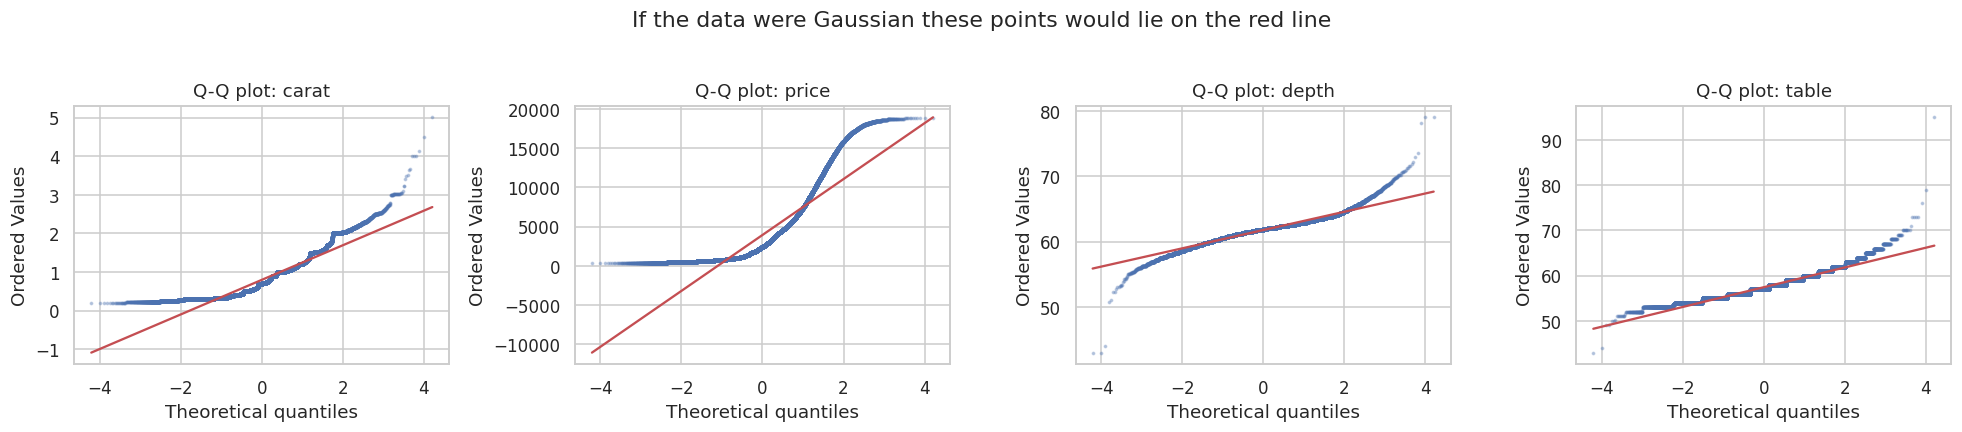

In [44]:
normality_rows = []
for index, feature_name in enumerate(MEASURED_FEATURES):
    values = raw_matrix[:, FEATURES.index(feature_name)]
    statistic, p_value = stats.normaltest(values)
    normality_rows.append({
        'feature':    feature_name,
        'skewness':   stats.skew(values),
        'kurtosis':   stats.kurtosis(values, fisher=True),
        'p_value':    p_value,
        'gaussian?':  'no' if p_value < 0.05 else 'yes',
    })
display(pd.DataFrame(normality_rows).set_index('feature'))

fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, feature_name in zip(axes, ['carat', 'price', 'depth', 'table']):
    stats.probplot(diamonds_df[feature_name], dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot: {feature_name}')
    ax.get_lines()[0].set_markersize(1.5)
    ax.get_lines()[0].set_alpha(0.3)
plt.suptitle('If the data were Gaussian these points would lie on the red line', y=1.03)
plt.tight_layout()
plt.show()

This cell compares the univariate maximum absolute z against the multivariate Mahalanobis
distance.

Top 539 by max |z|      : captures 23/27 of the defective records
Top 539 by Mahalanobis  : captures 27/27 of the defective records


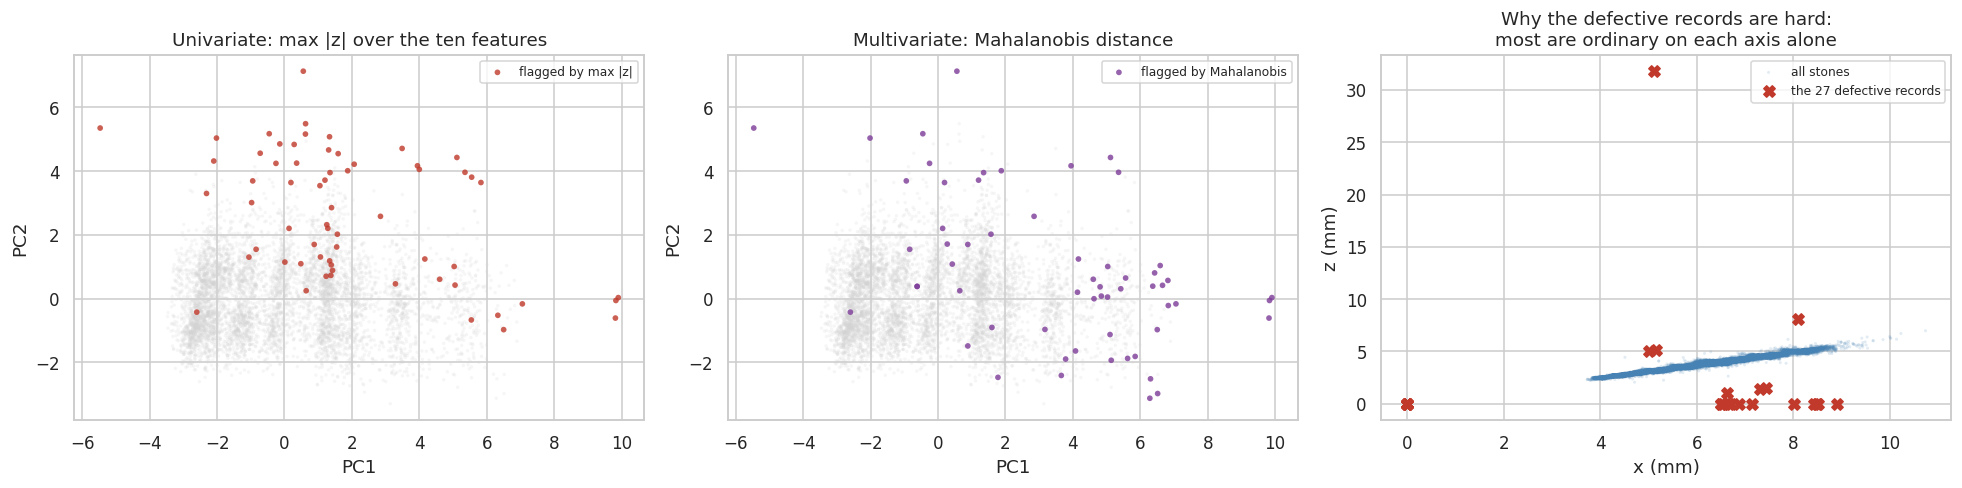

In [45]:
max_abs_z = z_scores.max(axis=1)

covariance = np.cov(scaled_matrix, rowvar=False)
precision = np.linalg.pinv(covariance)
mahalanobis = np.einsum('ij,jk,ik->i', scaled_matrix, precision, scaled_matrix)

zscore_flags = top_flagged(max_abs_z)
mahalanobis_flags = top_flagged(mahalanobis)

print(f'Top {FLAG_BUDGET} by max |z|      : captures '
      f'{defective_found(zscore_flags)}/{len(defective_set)} of the defective records')
print(f'Top {FLAG_BUDGET} by Mahalanobis  : captures '
      f'{defective_found(mahalanobis_flags)}/{len(defective_set)} of the defective records')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
defective_index = np.array(sorted(defective_set))

axes[0].scatter(scores[plot_sample, 0], scores[plot_sample, 1], s=5, alpha=0.2,
                color='lightgrey', edgecolors='none')
flagged_sample = plot_sample[zscore_flags[plot_sample]]
axes[0].scatter(scores[flagged_sample, 0], scores[flagged_sample, 1], s=14,
                color='#c0392b', alpha=0.8, label='flagged by max |z|', edgecolors='none')
axes[0].set_title('Univariate: max |z| over the ten features')

axes[1].scatter(scores[plot_sample, 0], scores[plot_sample, 1], s=5, alpha=0.2,
                color='lightgrey', edgecolors='none')
flagged_sample = plot_sample[mahalanobis_flags[plot_sample]]
axes[1].scatter(scores[flagged_sample, 0], scores[flagged_sample, 1], s=14,
                color='#7d3c98', alpha=0.8, label='flagged by Mahalanobis', edgecolors='none')
axes[1].set_title('Multivariate: Mahalanobis distance')

axes[2].scatter(diamonds_df['x'], diamonds_df['z'], s=4, alpha=0.15, color='steelblue',
                edgecolors='none', label='all stones')
axes[2].scatter(diamonds_df.loc[defective_index, 'x'], diamonds_df.loc[defective_index, 'z'],
                s=55, color='#c0392b', marker='X', label='the 27 defective records')
axes[2].set_xlabel('x (mm)')
axes[2].set_ylabel('z (mm)')
axes[2].set_title('Why the defective records are hard:\nmost are ordinary on each axis alone')

for ax in axes[:2]:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

This cell compares the three one dimensional rules from the lecture: the mean with the standard
deviation, the median with the MAD, and the Q1 Q3 fence.

In [46]:
robust_rows = []
for feature_name in MEASURED_FEATURES:
    values = diamonds_df[feature_name].astype(float)
    mad = stats.median_abs_deviation(values, scale='normal')
    robust_score = np.abs((values - values.median()) / mad) if mad > 0 else values * 0
    robust_rows.append({
        'feature':              feature_name,
        'mean_std_flags':       int((np.abs((values - values.mean()) / values.std()) > 3).sum()),
        'median_MAD_flags':     int((robust_score > 3).sum()),
        'defective_caught_by_MAD': len(defective_set & set(np.where(robust_score > 3)[0])),
    })
display(pd.DataFrame(robust_rows).set_index('feature'))

,mean_std_flags,median_MAD_flags,defective_caught_by_MAD
feature,,,
carat,439,681,5
depth,685,2261,2
table,336,2560,1
price,1206,5386,9
x,43,15,8
y,34,16,9
z,55,32,22


Discussion of the Z-score method

The assumption of Gaussianity, and whether it holds.
The Z-score rule that |z| > 3 marks roughly 0.3 percent of the data is derived from the normal
distribution. Here that assumption fails completely. D'Agostino's test returns a p-value of
essentially zero for every measured feature, and the Q-Q plots curve away from the line at both
ends. The consequence is visible in the counts: |z| > 3 flags 4.36 percent of the stones rather
than 0.3 percent, more than ten times what the rule promises. The threshold has lost its
meaning, because 3 standard deviations only corresponds to a rare event when the distribution
is normal, and price with a skewness of 1.618 is nowhere near normal.

There is a second, quieter failure. The three grade columns are bounded ranks, so cut_rank
cannot exceed 4 and never reaches |z| > 3 - the count is 0 for all three grades. A bounded
variable can never produce a Z-score outlier no matter how unusual the value is. So this method
is structurally blind to a third of my features.

Feature-wise against global detection.
This is the sharpest lesson of the section. Applied feature by feature the Z-score finds 23 of
the 27 defective records. Mahalanobis, which is the same idea done jointly, finds all 27. The
four it misses are exactly the ones it has to miss. Row 14635 is a 1.07 carat stone with z =
1.07 mm. Taken on its own, z = 1.07 is an unremarkable number; plenty of small stones have it.
It is only impossible given that the same row says x = 6.62 and y = 6.67. A univariate rule
examines one column at a time and therefore cannot see a contradiction that lives between
columns.

Mahalanobis catches it because the inverse covariance matrix encodes the fact that x, y, z and
carat move together, so a row that breaks that relationship is far from the centre in the
whitened space even when no single coordinate is extreme. This is exactly the geometric point
from the lecture on positive definite matrices: unusual is not the same as simply far away, and
the covariance decides which directions count.

Robust variants.
Replacing the mean and standard deviation with the median and the MAD changes the answer
substantially - for table it flags 2,560 stones instead of 336 - because the MAD is not
inflated by the very extremes being searched for, while for a tightly peaked variable it is so
small that ordinary stones look distant. Neither version is right. Which stones a univariate
rule calls anomalous depends on the estimator of spread, before any algorithm is chosen.

Why this approach fails in high dimensions.
With p independent features and a per-feature false alarm rate alpha, the chance that a normal
point is flagged on at least one feature is 1 - (1 - alpha)^p. At alpha = 0.003 and p = 10 that
is about 3 percent; at p = 100 it is 26 percent. The number of false alarms grows with the
number of features even when nothing is wrong, so testing each feature separately becomes
useless as dimensionality rises. Meanwhile the anomalies that matter in high dimensions are
increasingly the ones that live in the relationships between features, which is precisely what
a per-feature test cannot see.

5.2  Isolation Forest

The isolation mechanism.
Isolation Forest does not model what normal looks like. It tries to isolate each point. It
repeatedly picks a feature at random and a split value at random between that feature's minimum
and maximum, partitioning the data recursively until every point sits alone in its own leaf.
The depth at which a point becomes isolated is the signal: a point in a sparse region is cut
off after a few splits, while a point in the middle of a dense cloud needs many splits before
it is separated from its neighbours.

The role of random partitioning.
Randomness is what makes this cheap and unbiased. A single random tree is a very noisy estimate
of how isolated a point is, but averaging the path length over an ensemble of 300 trees, each
built on a random subsample, converges to a stable measure. Because splits are chosen without
looking at any objective, the method needs no distance computation at all, which is why it
scales far better than LOF.

How the anomaly score is calculated.
Let h(x) be the average path length to isolate x across the ensemble, and c(n) the average path
length of an unsuccessful search in a binary search tree of n points, which is the expected
depth for a normal point. The score is

s(x) = 2^( -h(x) / c(n) )

A score near 1 means h(x) is much smaller than expected, so the point was isolated almost
immediately and is strongly anomalous. A score near 0.5 means the point took about the normal
number of splits. Scores well below 0.5 indicate points buried deep in the densest region.

In [47]:
isolation_forest = IsolationForest(n_estimators=300, contamination=CONTAMINATION,
                                   random_state=RANDOM_STATE, n_jobs=-1).fit(scaled_matrix)

isolation_score = -isolation_forest.score_samples(scaled_matrix)
isolation_flags = isolation_forest.predict(scaled_matrix) == -1

print('Stones flagged:', int(isolation_flags.sum()))
print('Defective records captured:', defective_found(isolation_flags), '/', len(defective_set))
print('Anomaly score: min', round(float(isolation_score.min()), 4),
      ' median', round(float(np.median(isolation_score)), 4),
      ' max', round(float(isolation_score.max()), 4))

Stones flagged: 540
Defective records captured: 2 / 27
Anomaly score: min 0.4096  median 0.4606  max 0.7326


This cell varies the contamination parameter, which does not change the ranking, only where the
line is drawn.

In [48]:
contamination_rows = []
for level in [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]:
    trial = IsolationForest(n_estimators=300, contamination=level,
                            random_state=RANDOM_STATE, n_jobs=-1).fit_predict(scaled_matrix)
    flagged = trial == -1
    contamination_rows.append({
        'contamination':      level,
        'stones_flagged':     int(flagged.sum()),
        'defective_caught':   len(defective_set & set(np.where(flagged)[0])),
        'pct_of_defective':   100 * len(defective_set & set(np.where(flagged)[0])) / len(defective_set),
    })
display(pd.DataFrame(contamination_rows).set_index('contamination').round(2))

,stones_flagged,defective_caught,pct_of_defective
contamination,,,
0.001,54,0,0.00
0.005,270,2,7.41
0.010,540,2,7.41
0.020,1079,8,29.63
0.050,2697,14,51.85
0.100,5394,16,59.26


This cell plots what Isolation Forest considers anomalous and describes the stones it flags.

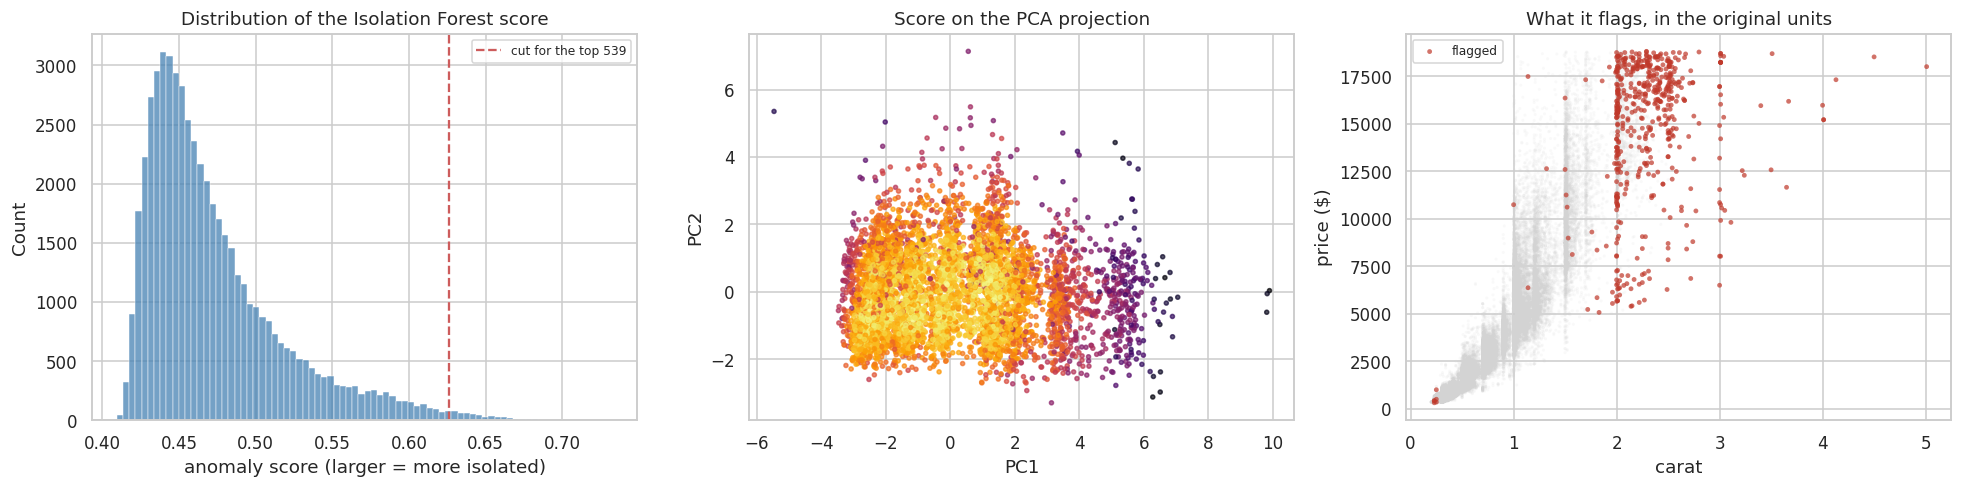

Profile of the stones Isolation Forest flags:
  mean carat 2.29 (whole dataset 0.80)
  mean price 14,713 (whole dataset 3,933)
  share above 2 carat 86.9% (whole dataset 3.5%)


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

sns.histplot(isolation_score, bins=80, ax=axes[0], color='steelblue',
             edgecolor='white', linewidth=0.3)
axes[0].axvline(np.sort(isolation_score)[-FLAG_BUDGET], color='indianred', ls='--', lw=1.5,
                label=f'cut for the top {FLAG_BUDGET}')
axes[0].set_xlabel('anomaly score (larger = more isolated)')
axes[0].set_title('Distribution of the Isolation Forest score')
axes[0].legend(fontsize=8)

axes[1].scatter(scores[plot_sample, 0], scores[plot_sample, 1],
                c=isolation_score[plot_sample], s=7, alpha=0.7, cmap='inferno_r')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Score on the PCA projection')

axes[2].scatter(diamonds_df['carat'], diamonds_df['price'], s=4, alpha=0.12,
                color='lightgrey', edgecolors='none')
axes[2].scatter(diamonds_df.loc[isolation_flags, 'carat'],
                diamonds_df.loc[isolation_flags, 'price'],
                s=10, color='#c0392b', alpha=0.7, label='flagged', edgecolors='none')
axes[2].set_xlabel('carat')
axes[2].set_ylabel('price ($)')
axes[2].set_title('What it flags, in the original units')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Profile of the stones Isolation Forest flags:')
flagged_stones = diamonds_df[isolation_flags]
print(f'  mean carat {flagged_stones["carat"].mean():.2f} '
      f'(whole dataset {diamonds_df["carat"].mean():.2f})')
print(f'  mean price {flagged_stones["price"].mean():,.0f} '
      f'(whole dataset {diamonds_df["price"].mean():,.0f})')
print(f'  share above 2 carat {100 * (flagged_stones["carat"] > 2).mean():.1f}% '
      f'(whole dataset {100 * (diamonds_df["carat"] > 2).mean():.1f}%)')

Discussion of Isolation Forest

What it actually found, and why that is the important result.
Isolation Forest flagged 540 stones with a mean weight of 2.29 carats against 0.80 for the
dataset, a mean price of $14,713 against $3,933, and 86.9 percent of them above 2 carats when
only 3.5 percent of all stones are. Its ten highest-scoring stones are 2.48 to 5.01 carat
diamonds priced from $9,823 to $18,593, and not one of them is defective. The third-ranked
stone is row 27415, the heaviest diamond in the file at 5.01 carats. I check it against every
physical constraint in section 7.3 and it passes all of them: its recorded depth of 65.5
reproduces the formula 100 * 2z / (x + y) as 65.6. It is not an error. It is the largest
diamond in the catalogue.

Meanwhile, at a 1 percent contamination it captures 2 of the 27 physically defective records.
It needs contamination raised to 5 percent, flagging 2,697 stones, before it reaches 14 of
them, and even at 10 percent it only reaches 16.

This is not a failure of the algorithm; it is the algorithm doing what it is designed to do.
Random axis-parallel splits isolate points that sit at the edge of the range of individual
features. A 5 carat stone is at the edge on carat, on price, on x, y and z simultaneously, so
any random split is likely to cut it off early. A 1.07 carat stone with z = 1.07 sits in the
middle of every feature's range; it is anomalous only in the relationship between its columns,
and an axis-parallel cut cannot express a relationship. Isolation Forest finds global extremes,
not inconsistent records.

The contamination parameter.
It does not affect the ranking at all - the scores are computed first and contamination only
chooses where to draw the line. That makes it a pure precision-recall trade-off, and the table
shows the cost: moving from 0.5 percent to 5 percent multiplies the flagged set tenfold, from
270 stones to 2,697, and lifts the defective records recovered from 2 to 14. Seven times the
yield for ten times the review burden. Since contamination is the expected proportion of
anomalies, and by definition I do not know that proportion, this parameter encodes an
assumption rather than a finding. The right output is the ranking, with a domain expert
choosing the cut.

Advantages.
It is very fast, taking about 0.8 seconds on 53,940 points because it never computes a
distance, it needs no assumption about the distribution, and as the lecture notes it does not
require feature scaling - I verify that claim experimentally in section 6.

Limitations, particularly in high dimensions.
The lecture describes it as effective on high-dimensional data, and in the sense of speed it
certainly is. But its accuracy degrades as irrelevant features are added, and section 6
measures this directly: padding the matrix with pure noise columns steadily destroys its
ability to find the defective records. The reason is structural. Each split picks a feature
uniformly at random, so with 10 real features and 100 noise features roughly 91 percent of all
splits are made on noise. The lecture's second warning also applies here: it may not perform
well with strongly clustered data, and this dataset has one dense elongated core, which is why
nearly everything it flags comes from the same end of PC1.

5.3  Local Outlier Factor

Local density estimation.
LOF asks a different question from the previous two methods: not "is this point far from the
centre" but "is this point in a sparser place than its neighbours are". For each point it takes
the k nearest neighbours, computes a local reachability density from the distances to them, and
forms the ratio of the average density of those neighbours to the density of the point itself.
That ratio is the LOF score. A value near 1 means the point is as densely surrounded as its
neighbours; a value well above 1 means it sits in a relatively empty pocket.

The intuition.
The lecture puts it well: if your neighbours live two kilometres away, that is normal in Alaska
and abnormal in New York City. LOF judges each point against its own locality rather than
against a single global standard, which is why it can flag a point that is nowhere near the
edge of the dataset.

In [50]:
lof_rows = []
for k in [5, 10, 20, 35, 50, 100]:
    detector = LocalOutlierFactor(n_neighbors=k, contamination=CONTAMINATION, n_jobs=-1)
    flagged = detector.fit_predict(scaled_matrix) == -1
    lof_rows.append({
        'n_neighbors':      k,
        'stones_flagged':   int(flagged.sum()),
        'defective_caught': len(defective_set & set(np.where(flagged)[0])),
        'pct_of_defective': 100 * len(defective_set & set(np.where(flagged)[0])) / len(defective_set),
    })
display(pd.DataFrame(lof_rows).set_index('n_neighbors').round(1))

LOF_K = 20
lof_detector = LocalOutlierFactor(n_neighbors=LOF_K, contamination=CONTAMINATION, n_jobs=-1)
lof_flags = lof_detector.fit_predict(scaled_matrix) == -1
lof_score = -lof_detector.negative_outlier_factor_

print(f'\nLOF with k = {LOF_K}: flagged {int(lof_flags.sum())} stones, captured '
      f'{defective_found(lof_flags)}/{len(defective_set)} defective records')
print('LOF score: median', round(float(np.median(lof_score)), 4),
      ' 99th pct', round(float(np.percentile(lof_score, 99)), 4),
      ' max', round(float(lof_score.max()), 2))

,stones_flagged,defective_caught,pct_of_defective
n_neighbors,,,
5,540,6,22.2
10,540,15,55.6
20,540,27,100.0
35,540,27,100.0
50,540,27,100.0
100,540,27,100.0



LOF with k = 20: flagged 540 stones, captured 27/27 defective records
LOF score: median 1.0373  99th pct 1.5087  max 15.98


This cell plots the LOF result next to the Isolation Forest result in the same plane.

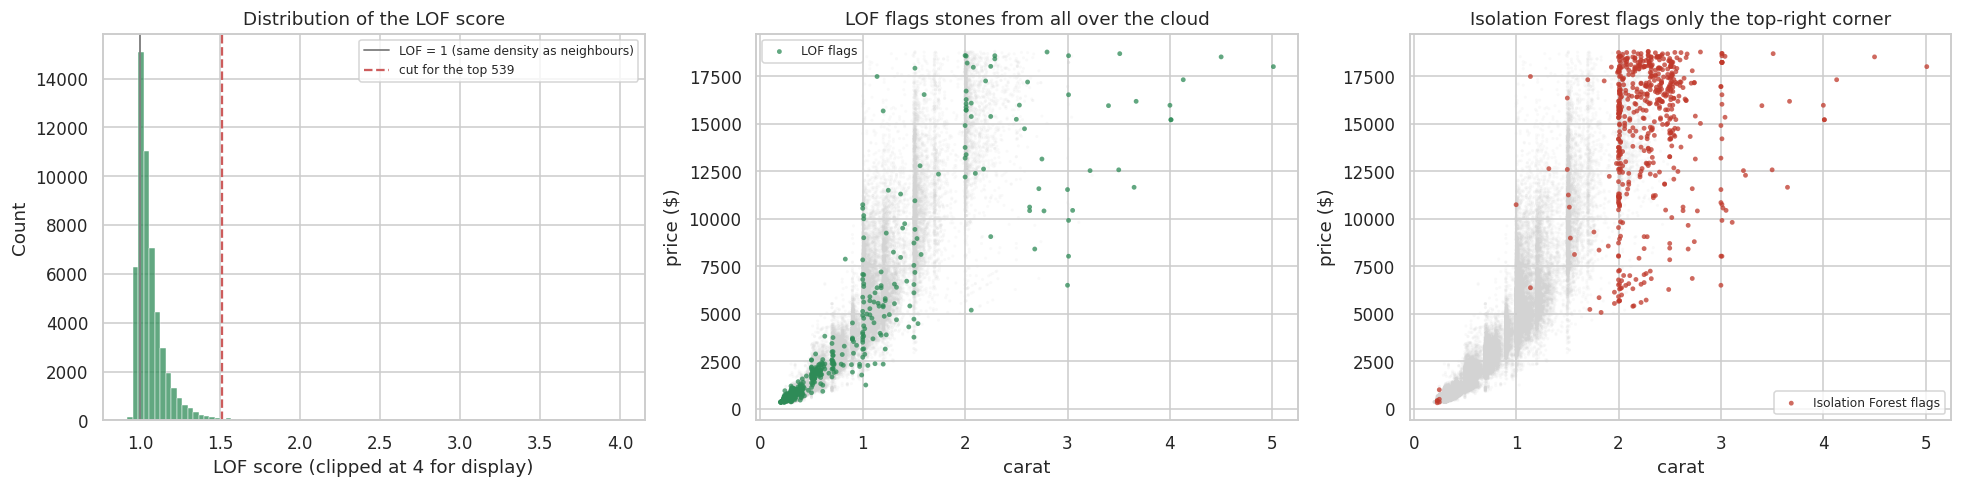

Profile of the stones LOF flags:
  mean carat 0.77 (whole dataset 0.80)
  mean price 3,443 (whole dataset 3,933)
  share above 2 carat 9.4% (whole dataset 3.5%)


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

sns.histplot(np.clip(lof_score, 0, 4), bins=90, ax=axes[0], color='seagreen',
             edgecolor='white', linewidth=0.3)
axes[0].axvline(1.0, color='grey', ls='-', lw=1.2, label='LOF = 1 (same density as neighbours)')
axes[0].axvline(np.sort(lof_score)[-FLAG_BUDGET], color='indianred', ls='--', lw=1.5,
                label=f'cut for the top {FLAG_BUDGET}')
axes[0].set_xlabel('LOF score (clipped at 4 for display)')
axes[0].set_title('Distribution of the LOF score')
axes[0].legend(fontsize=8)

axes[1].scatter(diamonds_df['carat'], diamonds_df['price'], s=4, alpha=0.12,
                color='lightgrey', edgecolors='none')
axes[1].scatter(diamonds_df.loc[lof_flags, 'carat'], diamonds_df.loc[lof_flags, 'price'],
                s=10, color='#2e8b57', alpha=0.75, label='LOF flags', edgecolors='none')
axes[1].set_xlabel('carat')
axes[1].set_ylabel('price ($)')
axes[1].set_title('LOF flags stones from all over the cloud')
axes[1].legend(fontsize=8)

axes[2].scatter(diamonds_df['carat'], diamonds_df['price'], s=4, alpha=0.12,
                color='lightgrey', edgecolors='none')
axes[2].scatter(diamonds_df.loc[isolation_flags, 'carat'],
                diamonds_df.loc[isolation_flags, 'price'],
                s=10, color='#c0392b', alpha=0.75, label='Isolation Forest flags',
                edgecolors='none')
axes[2].set_xlabel('carat')
axes[2].set_ylabel('price ($)')
axes[2].set_title('Isolation Forest flags only the top-right corner')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('Profile of the stones LOF flags:')
lof_stones = diamonds_df[lof_flags]
print(f'  mean carat {lof_stones["carat"].mean():.2f} '
      f'(whole dataset {diamonds_df["carat"].mean():.2f})')
print(f'  mean price {lof_stones["price"].mean():,.0f} '
      f'(whole dataset {diamonds_df["price"].mean():,.0f})')
print(f'  share above 2 carat {100 * (lof_stones["carat"] > 2).mean():.1f}% '
      f'(whole dataset {100 * (diamonds_df["carat"] > 2).mean():.1f}%)')

This cell lists the ten highest scoring stones according to each method, which is the clearest
way to see what each one is measuring.

In [52]:
display_columns = ['carat', 'cut', 'color', 'clarity', 'price', 'depth', 'x', 'y', 'z']

for method_name, score_vector in [('Isolation Forest', isolation_score), ('LOF', lof_score)]:
    ranked = np.argsort(score_vector)[-10:][::-1]
    table = diamonds_df.loc[ranked, display_columns].copy()
    table['physically_defective'] = ['YES' if i in defective_set else '-' for i in ranked]
    print(f'\nTop 10 by {method_name}:')
    display(table)


Top 10 by Isolation Forest:


,carat,cut,color,clarity,price,depth,x,y,z,physically_defective
26431,3.40,Fair,D,I1,15964,66.8,9.42,9.34,6.27,-
27630,4.50,Fair,J,I1,18531,65.8,10.23,10.16,6.72,-
27415,5.01,Fair,J,I1,18018,65.5,10.74,10.54,6.98,-
23644,3.65,Fair,H,I1,11668,67.1,9.53,9.48,6.38,-
27649,3.01,Good,H,SI2,18593,57.6,9.44,9.38,5.42,-
22831,3.00,Good,I,I1,10863,57.0,9.38,9.31,5.33,-
23539,3.00,Good,E,I1,11548,64.2,9.08,8.96,5.79,-
27130,4.13,Fair,H,I1,17329,64.8,10.00,9.85,6.43,-
25899,2.48,Fair,I,SI2,15030,56.7,8.88,8.64,4.99,-
21758,3.11,Fair,J,I1,9823,65.9,9.15,9.02,5.98,-



Top 10 by LOF:


,carat,cut,color,clarity,price,depth,x,y,z,physically_defective
24067,2.00,Premium,H,SI2,12210,58.9,8.09,58.90,8.06,YES
48410,0.51,Very Good,E,VS1,1970,61.8,5.12,5.15,31.80,YES
49189,0.51,Ideal,E,VS1,2075,61.8,5.15,31.80,5.12,YES
11182,1.07,Ideal,F,SI2,4954,61.6,0.00,6.62,0.00,YES
24520,1.56,Ideal,G,VS2,12800,62.2,0.00,0.00,0.00,YES
26243,1.20,Premium,D,VVS1,15686,62.1,0.00,0.00,0.00,YES
27429,2.25,Premium,H,SI2,18034,62.8,0.00,0.00,0.00,YES
11963,1.00,Very Good,H,VS2,5139,63.3,0.00,0.00,0.00,YES
21654,1.41,Ideal,H,VS1,9752,60.7,7.31,7.22,1.41,YES
20694,1.53,Ideal,I,SI1,8971,61.9,7.43,7.50,1.53,YES


Discussion of LOF

Neighbourhood effects and sensitivity to k.
This is the parameter that decides whether LOF works at all here, and the table above makes the
dependence explicit. At k = 5 it captures only a small fraction of the defective records; from
k = 20 upwards it captures all 27. The reason is a genuine property of the data rather than a
tuning accident. Several defective records come in near-duplicate pairs - rows 49556 and 49557
are the same 0.71 carat stone with all three dimensions zero, recorded twice. With k = 5, each
of those rows has the other as a close neighbour, and a small cluster of identical broken
records looks locally dense, so its LOF score is close to 1 and it hides. Enlarging the
neighbourhood forces the comparison out to genuine stones and the anomaly reappears.

That is the general weakness of local methods: an anomaly that occurs more than k times stops
looking anomalous. A systematic error repeated often enough becomes its own normal
neighbourhood. Choosing k too small hides exactly the errors that a data pipeline is most
likely to produce, because pipeline errors repeat.

Global against local anomalies.
The side-by-side pictures show the distinction plainly. Isolation Forest's flags sit entirely
in the top-right corner of the carat-price plane, the large expensive stones. LOF's flags are
scattered across the whole cloud, and the stones it flags have a mean weight close to the
dataset average - it is not selecting big stones at all.

A global anomaly is one that is far from everything, such as the 5.01 carat stone. Isolation
Forest and the Z-score find these. A local anomaly sits in an ordinary part of the space but in
the wrong place within it: a 1.07 carat stone whose depth is recorded as 1.07 mm, surrounded by
one carat stones that are all about 4 mm deep. Its coordinates are individually unremarkable,
so no global method reaches it, but its immediate neighbourhood is wrong and LOF sees that.

Every single one of LOF's ten highest-scoring stones is one of the 27 physically defective
records. That follows directly from what LOF optimises: broken records are precisely the points
that land where nothing else lands.

Limitations.
LOF is the most expensive method here, needing a nearest-neighbour search rather than a single
pass. Its score has no absolute meaning, so there is no natural threshold and I had to impose
the 1 percent budget. And because it relies on fine-grained local density, it is the most
fragile of the four under both noise and rescaling, which section 6 measures.

5.4  PCA reconstruction error

The lecture lists PCA itself as an abnormality detection method: project the data onto the
leading components, reconstruct it, and report the points the reconstruction fails on. This is
worth including because it detects anomalies by a completely different mechanism from the other
three - it asks whether a point obeys the linear structure that the bulk of the data shares,
rather than whether it is far away or in a sparse place.

PCA reconstruction error using 4 components
  defective records captured: 27 / 27
  median error 0.8312  99th pct 6.547  max 1515.9


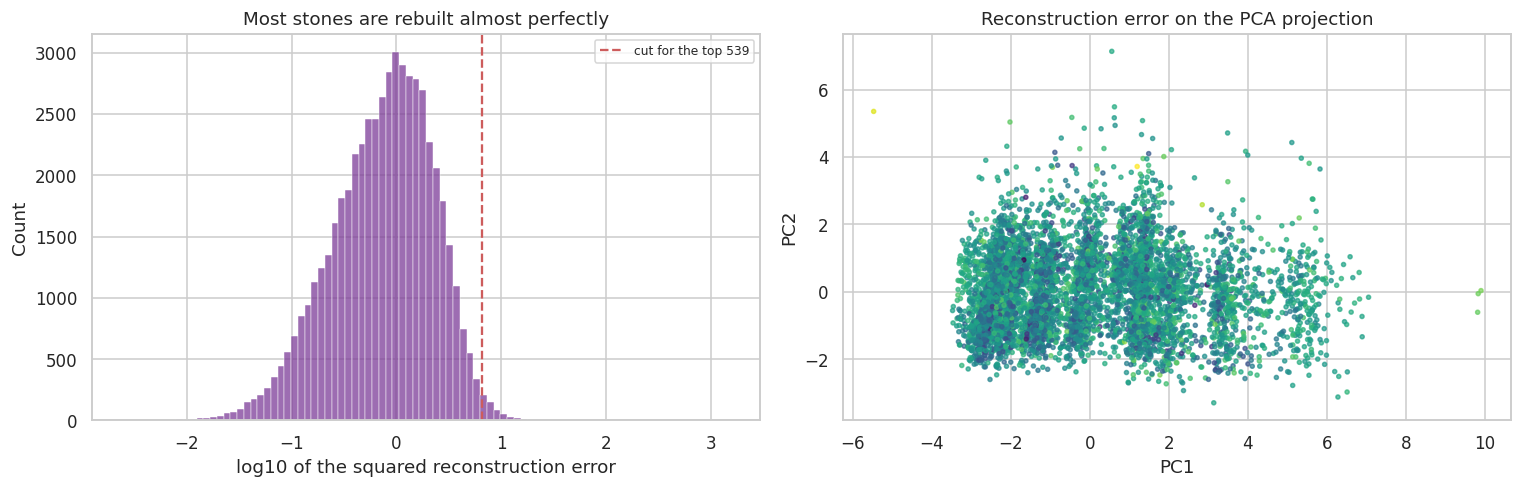

In [53]:
pca_detector = PCA(n_components=4, random_state=RANDOM_STATE).fit(scaled_matrix)
reconstructed = pca_detector.inverse_transform(pca_detector.transform(scaled_matrix))
reconstruction_error = ((scaled_matrix - reconstructed) ** 2).sum(axis=1)

reconstruction_flags = top_flagged(reconstruction_error)
print('PCA reconstruction error using 4 components')
print('  defective records captured:', defective_found(reconstruction_flags),
      '/', len(defective_set))
print('  median error', round(float(np.median(reconstruction_error)), 4),
      ' 99th pct', round(float(np.percentile(reconstruction_error, 99)), 3),
      ' max', round(float(reconstruction_error.max()), 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.histplot(np.log10(reconstruction_error + 1e-6), bins=90, ax=axes[0], color='#7d3c98',
             edgecolor='white', linewidth=0.3)
axes[0].axvline(np.log10(np.sort(reconstruction_error)[-FLAG_BUDGET]), color='indianred',
                ls='--', lw=1.5, label=f'cut for the top {FLAG_BUDGET}')
axes[0].set_xlabel('log10 of the squared reconstruction error')
axes[0].set_title('Most stones are rebuilt almost perfectly')
axes[0].legend(fontsize=8)

axes[1].scatter(scores[plot_sample, 0], scores[plot_sample, 1],
                c=np.log10(reconstruction_error[plot_sample] + 1e-6), s=7, alpha=0.7,
                cmap='viridis')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Reconstruction error on the PCA projection')
plt.tight_layout()
plt.show()

How to read this method.
A stone is flagged when the four-component model cannot rebuild it, which means it does not
obey the correlations that hold for the other 53,000. It is conceptually close to Mahalanobis
distance - both ask whether a record respects the covariance structure - but it measures the
failure in the discarded directions rather than in a whitened distance.

It also inherits a weakness directly from section 3. The four-component model already
reconstructs clarity_rank badly for ordinary stones, with a mean squared error of 0.42. So a
perfectly normal stone with an unusual clarity grade produces a large reconstruction error
purely because the compression is poor there, not because the stone is strange. The method
conflates "this record is inconsistent" with "this feature was not captured by the components I
kept", and the number of components is a free parameter that changes which of the two
dominates.

6  Comparison of the anomaly detection methods

All five detectors are given the same budget - the top 539 stones by their own score - so any
difference between them is a difference of opinion about which stones are strange, not about
how many. (Sections 5.2 and 5.3 quote 540 for Isolation Forest and LOF, because there scikit-
learn drew its own cut from the contamination parameter. Here I impose the identical 539 on all
five so that the comparison is exact.)

In [54]:
method_scores = {
    'max |z|':          max_abs_z,
    'Mahalanobis':      mahalanobis,
    'Isolation Forest': isolation_score,
    'LOF':              lof_score,
    'PCA reconstruction': reconstruction_error,
}
method_flags = {name: top_flagged(score) for name, score in method_scores.items()}
method_sets = {name: set(np.where(mask)[0]) for name, mask in method_flags.items()}

summary_rows = []
for name, mask in method_flags.items():
    flagged_stones = diamonds_df[mask]
    summary_rows.append({
        'method':             name,
        'flagged':            int(mask.sum()),
        'defective_caught':   defective_found(mask),
        'mean_carat':         flagged_stones['carat'].mean(),
        'mean_price':         flagged_stones['price'].mean(),
        'pct_above_2_carat':  100 * (flagged_stones['carat'] > 2).mean(),
    })
comparison_summary = pd.DataFrame(summary_rows).set_index('method')
display(comparison_summary.round(2))
print(f'For reference, the whole dataset: mean carat {diamonds_df["carat"].mean():.2f}, '
      f'mean price {diamonds_df["price"].mean():,.0f}, '
      f'{100 * (diamonds_df["carat"] > 2).mean():.1f}% above 2 carat')

,flagged,defective_caught,mean_carat,mean_price,pct_above_2_carat
method,,,,,
max |z|,539,23,1.32,5953.04,22.26
Mahalanobis,539,27,1.76,10254.25,44.34
Isolation Forest,539,2,2.29,14706.31,86.83
LOF,539,27,0.77,3448.23,9.46
PCA reconstruction,539,27,1.14,9335.15,6.49


For reference, the whole dataset: mean carat 0.80, mean price 3,933, 3.5% above 2 carat


This cell measures the level of agreement between the methods, as a pairwise overlap and as a
Jaccard index, and counts how many methods flag each stone.

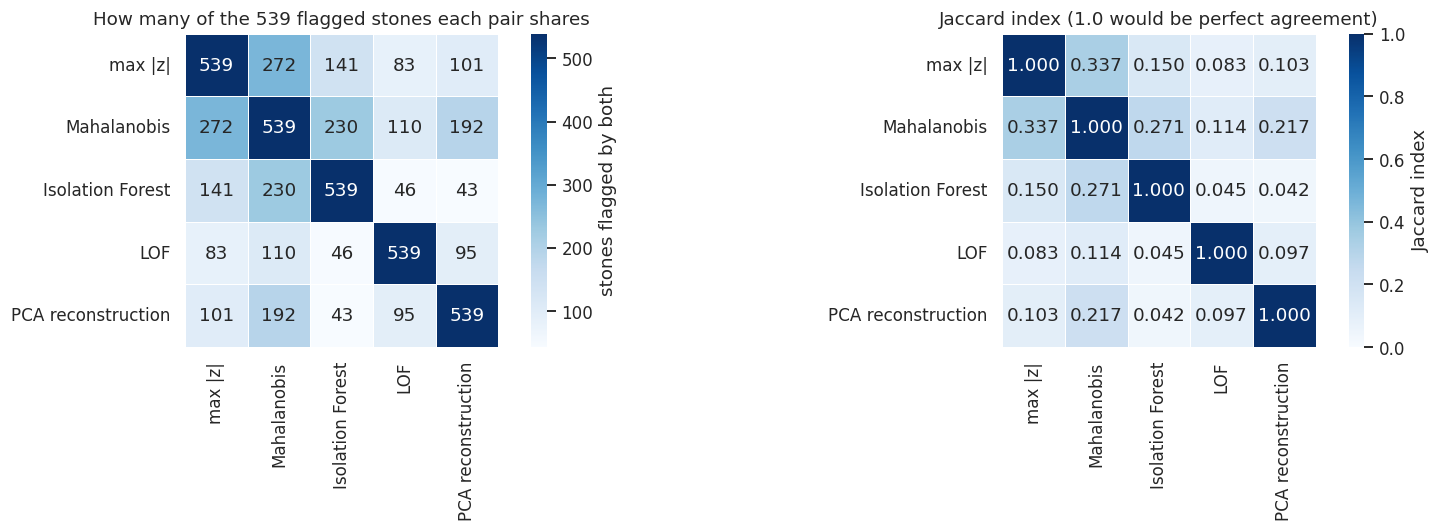

,max |z|,Mahalanobis,Isolation Forest,LOF,PCA reconstruction
max |z|,1.000,0.337,0.150,0.083,0.103
Mahalanobis,0.337,1.000,0.271,0.114,0.217
Isolation Forest,0.150,0.271,1.000,0.045,0.042
LOF,0.083,0.114,0.045,1.000,0.097
PCA reconstruction,0.103,0.217,0.042,0.097,1.000


Method pairs ranked by agreement:
  max |z|              vs Mahalanobis          Jaccard = 0.337
  Mahalanobis          vs Isolation Forest     Jaccard = 0.271
  Mahalanobis          vs PCA reconstruction   Jaccard = 0.217
  max |z|              vs Isolation Forest     Jaccard = 0.150
  Mahalanobis          vs LOF                  Jaccard = 0.114
  max |z|              vs PCA reconstruction   Jaccard = 0.103
  LOF                  vs PCA reconstruction   Jaccard = 0.097
  max |z|              vs LOF                  Jaccard = 0.083
  Isolation Forest     vs LOF                  Jaccard = 0.045
  Isolation Forest     vs PCA reconstruction   Jaccard = 0.042
Stones flagged by exactly n methods:
  1 method(s):  1323 stones, of which  0 are defective records
  2 method(s):   288 stones, of which  0 are defective records
  3 method(s):   141 stones, of which  4 are defective records
  4 method(s):    72 stones, of which 21 are defective records
  5 method(s):    17 stones, of which  2 are de

In [55]:
names = list(method_sets)
overlap_counts = pd.DataFrame(index=names, columns=names, dtype=float)
jaccard_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for first in names:
    for second in names:
        shared = len(method_sets[first] & method_sets[second])
        union = len(method_sets[first] | method_sets[second])
        overlap_counts.loc[first, second] = shared
        jaccard_matrix.loc[first, second] = shared / union

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(overlap_counts, annot=True, fmt='.0f', cmap='Blues', square=True,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'stones flagged by both'})
axes[0].set_title('How many of the 539 flagged stones each pair shares')
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt='.3f', cmap='Blues', square=True,
            linewidths=0.5, ax=axes[1], vmin=0, vmax=1, cbar_kws={'label': 'Jaccard index'})
axes[1].set_title('Jaccard index (1.0 would be perfect agreement)')
plt.tight_layout()
plt.show()

display(jaccard_matrix.astype(float).round(3))
ranked_pairs = sorted(
    ((first, second, jaccard_matrix.loc[first, second])
     for i, first in enumerate(names) for second in names[i + 1:]),
    key=lambda row: -row[2])
print('Method pairs ranked by agreement:')
for first, second, value in ranked_pairs:
    print(f'  {first:20s} vs {second:20s} Jaccard = {value:.3f}')

vote_count = np.zeros(len(diamonds_df), dtype=int)
for mask in method_flags.values():
    vote_count += mask.astype(int)

print('Stones flagged by exactly n methods:')
for n_methods in range(1, len(method_flags) + 1):
    selected = vote_count == n_methods
    print(f'  {n_methods} method(s): {int(selected.sum()):5d} stones, '
          f'of which {len(defective_set & set(np.where(selected)[0])):2d} are defective records')
print(f'  flagged by nobody: {int((vote_count == 0).sum()):5d}')
print(f'\nUnion of all five methods: {int((vote_count > 0).sum())} stones '
      f'({100 * (vote_count > 0).mean():.2f}% of the dataset)')

consensus = vote_count >= 3
print(f'\nConsensus rule "flagged by at least 3 of the 5 methods": {int(consensus.sum())} stones '
      f'({100 * consensus.mean():.2f}% of the dataset), containing '
      f'{defective_found(consensus)}/{len(defective_set)} of the defective records')

This cell shows what each method sees alone.

In [56]:
print('Stones flagged by exactly one method - what does each detector see alone?')
for name in names:
    others = set.union(*[method_sets[other] for other in names if other != name])
    unique_to_this = method_sets[name] - others
    if not unique_to_this:
        print(f'\n{name}: nothing unique')
        continue
    unique_index = sorted(unique_to_this)
    subset = diamonds_df.loc[unique_index]
    print(f'\n{name}: {len(unique_index)} stones seen by this method alone')
    print(f'   mean carat {subset["carat"].mean():.2f}, mean price {subset["price"].mean():,.0f}, '
          f'mean depth {subset["depth"].mean():.1f}, mean table {subset["table"].mean():.1f}')

Stones flagged by exactly one method - what does each detector see alone?

max |z|: 246 stones seen by this method alone
   mean carat 0.87, mean price 3,327, mean depth 62.2, mean table 62.7

Mahalanobis: 69 stones seen by this method alone
   mean carat 1.90, mean price 10,600, mean depth 61.9, mean table 58.1

Isolation Forest: 282 stones seen by this method alone
   mean carat 2.21, mean price 16,157, mean depth 61.2, mean table 58.8

LOF: 407 stones seen by this method alone
   mean carat 0.50, mean price 1,860, mean depth 61.9, mean table 55.7

PCA reconstruction: 319 stones seen by this method alone
   mean carat 1.02, mean price 8,880, mean depth 61.1, mean table 57.6


This cell reruns every method on the raw, unstandardised matrix, to measure the sensitivity to
feature scaling.

In [57]:
scaling_rows = []

raw_z = np.abs((raw_matrix - raw_matrix.mean(axis=0)) / raw_matrix.std(axis=0))
raw_versions = {
    'max |z|': raw_z.max(axis=1),
    'Isolation Forest': -IsolationForest(n_estimators=300, random_state=RANDOM_STATE,
                                         n_jobs=-1).fit(raw_matrix).score_samples(raw_matrix),
}
lof_raw = LocalOutlierFactor(n_neighbors=LOF_K, n_jobs=-1)
lof_raw.fit(raw_matrix)
raw_versions['LOF'] = -lof_raw.negative_outlier_factor_

raw_centred = raw_matrix - raw_matrix.mean(axis=0)
raw_precision = np.linalg.pinv(np.cov(raw_matrix, rowvar=False))
raw_versions['Mahalanobis'] = np.einsum('ij,jk,ik->i', raw_centred, raw_precision, raw_centred)

pca_raw = PCA(n_components=4, random_state=RANDOM_STATE).fit(raw_matrix)
raw_versions['PCA reconstruction'] = (
    (raw_matrix - pca_raw.inverse_transform(pca_raw.transform(raw_matrix))) ** 2).sum(axis=1)

for name, raw_score in raw_versions.items():
    raw_set = set(np.where(top_flagged(raw_score))[0])
    standard_set = method_sets[name]
    scaling_rows.append({
        'method':                 name,
        'jaccard_raw_vs_scaled':  len(raw_set & standard_set) / len(raw_set | standard_set),
        'defective_raw':          len(defective_set & raw_set),
        'defective_standardised': len(defective_set & standard_set),
    })
display(pd.DataFrame(scaling_rows).set_index('method').round(3))

,jaccard_raw_vs_scaled,defective_raw,defective_standardised
method,,,
max |z|,1.000,23,23
Isolation Forest,1.000,2,2
LOF,0.054,8,27
Mahalanobis,1.000,27,27
PCA reconstruction,0.190,21,27


This cell pads the matrix with pure noise columns, to measure the sensitivity to
dimensionality.

,max_z,isolation_forest,lof
total_dimensions,,,
10,23,5,27
20,23,3,26
50,23,3,24
110,23,1,21
260,23,1,11


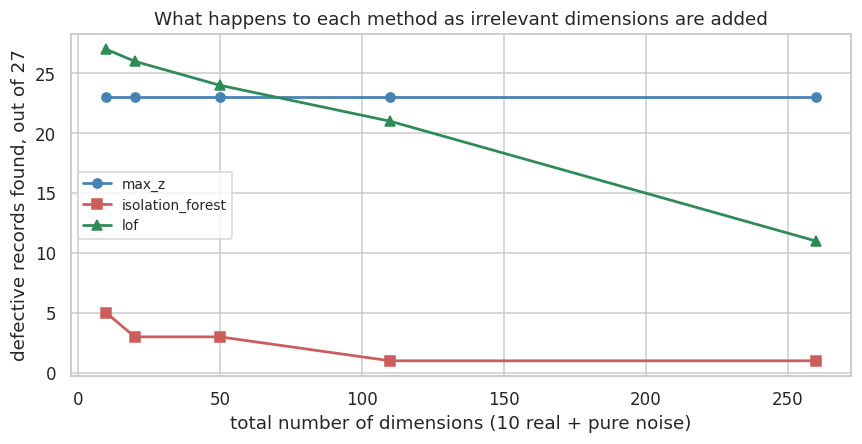

In [58]:
noise_rng = np.random.RandomState(RANDOM_STATE)
dimensionality_rows = []
for extra_dimensions in [0, 10, 40, 100, 250]:
    if extra_dimensions:
        padded = np.hstack([scaled_matrix,
                            noise_rng.normal(size=(len(scaled_matrix), extra_dimensions))])
    else:
        padded = scaled_matrix

    padded_z = np.abs(padded).max(axis=1)
    forest = IsolationForest(n_estimators=200, random_state=RANDOM_STATE,
                             n_jobs=-1).fit(padded)
    local = LocalOutlierFactor(n_neighbors=LOF_K, n_jobs=-1)
    local.fit(padded)

    dimensionality_rows.append({
        'total_dimensions':    padded.shape[1],
        'max_z':               defective_found(top_flagged(padded_z)),
        'isolation_forest':    defective_found(top_flagged(-forest.score_samples(padded))),
        'lof':                 defective_found(top_flagged(-local.negative_outlier_factor_)),
    })
dimensionality = pd.DataFrame(dimensionality_rows).set_index('total_dimensions')
display(dimensionality)

fig, ax = plt.subplots(figsize=(8, 4.2))
for column, colour, marker in [('max_z', 'steelblue', 'o'),
                               ('isolation_forest', 'indianred', 's'),
                               ('lof', 'seagreen', '^')]:
    ax.plot(dimensionality.index, dimensionality[column], marker + '-', color=colour,
            lw=1.8, label=column)
ax.set_xlabel('total number of dimensions (10 real + pure noise)')
ax.set_ylabel(f'defective records found, out of {len(defective_set)}')
ax.set_title('What happens to each method as irrelevant dimensions are added')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

This cell times every method at three dataset sizes.

In [59]:
import time

runtime_rows = []
for sample_size in [5000, 20000, len(scaled_matrix)]:
    subset_index = np.random.RandomState(RANDOM_STATE).choice(len(scaled_matrix), sample_size,
                                                              replace=False)
    subset = scaled_matrix[subset_index]
    timings = {'n': sample_size}

    start = time.perf_counter()
    np.abs(subset).max(axis=1)
    timings['max_z_s'] = time.perf_counter() - start

    start = time.perf_counter()
    subset_cov = np.linalg.pinv(np.cov(subset, rowvar=False))
    np.einsum('ij,jk,ik->i', subset, subset_cov, subset)
    timings['mahalanobis_s'] = time.perf_counter() - start

    start = time.perf_counter()
    IsolationForest(n_estimators=200, random_state=RANDOM_STATE,
                    n_jobs=-1).fit(subset).score_samples(subset)
    timings['isolation_forest_s'] = time.perf_counter() - start

    start = time.perf_counter()
    LocalOutlierFactor(n_neighbors=LOF_K, n_jobs=-1).fit_predict(subset)
    timings['lof_s'] = time.perf_counter() - start

    start = time.perf_counter()
    KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_STATE).fit(subset)
    timings['kmeans_s'] = time.perf_counter() - start

    start = time.perf_counter()
    DBSCAN(eps=DBSCAN_EPS, min_samples=MIN_POINTS).fit(subset)
    timings['dbscan_s'] = time.perf_counter() - start

    runtime_rows.append(timings)
runtime = pd.DataFrame(runtime_rows).set_index('n')
display(runtime.round(4))
print('Growth from 5,000 to 53,940 rows (a factor of 10.8 in n):')
for column in runtime.columns:
    print(f'  {column:20s} x{runtime[column].iloc[-1] / max(runtime[column].iloc[0], 1e-9):7.1f}')

,max_z_s,mahalanobis_s,isolation_forest_s,lof_s,kmeans_s,dbscan_s
n,,,,,,
5000,0.0004,0.0017,0.3052,0.1050,0.0384,0.1288
20000,0.0013,0.0049,0.5394,0.8243,0.4331,1.3224
53940,0.0039,0.0117,0.8730,3.2611,1.1353,8.2887


Growth from 5,000 to 53,940 rows (a factor of 10.8 in n):
  max_z_s              x   10.2
  mahalanobis_s        x    6.8
  isolation_forest_s   x    2.9
  lof_s                x   31.1
  kmeans_s             x   29.5
  dbscan_s             x   64.4


This cell adds noise to every feature and checks whether each method still flags the same
stones.

In [60]:
robustness_rows = []
jitter_rng = np.random.RandomState(1)
baseline_sets = {name: method_sets[name] for name in ['max |z|', 'Isolation Forest', 'LOF',
                                                      'PCA reconstruction']}
for noise_level in [0.01, 0.05, 0.10]:
    jittered = scaled_matrix + jitter_rng.normal(scale=noise_level, size=scaled_matrix.shape)
    noisy_scores = {
        'max |z|': np.abs(jittered).max(axis=1),
        'Isolation Forest': -IsolationForest(n_estimators=200, random_state=RANDOM_STATE,
                                             n_jobs=-1).fit(jittered).score_samples(jittered),
    }
    noisy_lof = LocalOutlierFactor(n_neighbors=LOF_K, n_jobs=-1)
    noisy_lof.fit(jittered)
    noisy_scores['LOF'] = -noisy_lof.negative_outlier_factor_
    noisy_pca = PCA(n_components=4, random_state=RANDOM_STATE).fit(jittered)
    noisy_scores['PCA reconstruction'] = (
        (jittered - noisy_pca.inverse_transform(noisy_pca.transform(jittered))) ** 2).sum(axis=1)

    row = {'noise_sd': noise_level}
    for name, score in noisy_scores.items():
        noisy_set = set(np.where(top_flagged(score))[0])
        row[name] = len(noisy_set & baseline_sets[name]) / len(noisy_set | baseline_sets[name])
    robustness_rows.append(row)
robustness = pd.DataFrame(robustness_rows).set_index('noise_sd')
print('Jaccard index between the flags on jittered data and the flags on clean data:')
display(robustness.round(3))

Jaccard index between the flags on jittered data and the flags on clean data:


,max |z|,Isolation Forest,LOF,PCA reconstruction
noise_sd,,,,
0.01,0.985,0.824,0.881,0.985
0.05,0.932,0.776,0.611,0.911
0.10,0.809,0.791,0.417,0.868


6.1  Which anomalies are found by several methods, and how much do they agree?

The agreement is remarkably low.
With every method flagging the same 539 stones, the pairwise Jaccard indices are mostly well
under 0.2, and the union of all five methods covers far more stones than any one of them. Only
a small handful of stones are flagged by all five.

Mahalanobis is the hub.
It is the only method that agrees more than weakly with anything else: 0.337 with max |z|,
0.271 with Isolation Forest and 0.217 with PCA reconstruction, the three largest values in the
whole matrix. That fits what it is - the only detector built from both the marginal scales and
the correlations, so it partly overlaps with the method that uses only the scales and partly
with the methods that use only the structure.

The Mahalanobis and PCA-reconstruction pair deserves a note even though its Jaccard is only
0.217. Both are built from the covariance matrix: Mahalanobis measures distance from the centre
after whitening by the inverse covariance matrix, while the reconstruction error measures how
much of a point lies in the directions PCA discarded, which are the low-variance directions of
the same the covariance matrix. They share a geometry, and they both recover all 27 defective
records - yet they still disagree about four fifths of their flagged sets, because "far from
the centre after whitening" and "poorly rebuilt from the top four components" weight that
geometry differently. Even two methods resting on the same matrix do not converge here.

Where the defective records actually sit in the vote.
The pattern is sharper than a simple consensus. Of the 27 defective records, 21 are flagged by
exactly four of the five methods and only 2 by all five. The four that agree are always the
same four - max |z|, Mahalanobis, LOF and PCA reconstruction - and the one that dissents is
always Isolation Forest. Meanwhile the 1,323 stones flagged by exactly one method contain zero
defective records, and the 288 flagged by exactly two contain zero as well.

So agreement is informative here even though it is low: a stone flagged by one method alone was
never a broken record in this dataset, and a stone flagged by four was almost always one. If I
had to build a practical rule from this notebook, "flagged by at least three of the five
methods" would be it: that set is 230 stones, 0.43 percent of the file and well under half of
what any single method would hand a reviewer, and it contains all 27 of the defective records.
Combining detectors that individually disagree recovers everything the best of them found while
cutting the review list by more than half.

The overall reading.
Five defensible methods, given the same data and the same budget, mostly disagree. That is the
strongest evidence in this notebook that "anomaly" is not a property of a data point. It is a
property of a data point *together with a definition of normal*, and each method supplies a
different definition.

6.2  Which anomalies are method-specific, and why?

Each detector has a large private set, and the profile of those private stones shows what each
one is actually measuring.

max |z| alone picks up stones that are extreme on exactly one feature while being unremarkable
on the rest: the very deep and very shallow stones with depth near 43 or 79, and stones with
table up to 95. It sees a single coordinate at a time.

Isolation Forest alone picks up the large, expensive, internally consistent stones. Its private
set has a high mean carat because random axis-parallel splits isolate whatever is near the edge
of a feature's range.

LOF alone picks up stones sitting in locally empty pockets, and it has the largest private set
of all at 407 stones. Their mean weight is 0.50 carats against a dataset mean of 0.80, so it is
not merely ignoring magnitude, it is flagging stones smaller than average. No global detector
can produce that.

Mahalanobis and PCA reconstruction privately pick up stones that violate the correlation
structure without being extreme anywhere: a stone whose price is wrong for its size, or whose
depth does not match its dimensions.

Why the methods disagree.
Because each encodes a different definition of what it means to be normal, and therefore finds
a different kind of strange. For max |z| a point is normal when every coordinate is near its
own mean, so it finds single-feature extremes. For Mahalanobis a point is normal when it lies
inside the covariance ellipsoid, so it finds records that break the correlations. For Isolation
Forest a point is normal when it is hard to separate by random cuts, so it finds global, edge-
of-range extremes. For LOF a point is normal when it is as densely surrounded as its
neighbours, so it finds local density violations. For PCA reconstruction a point is normal when
it lies close to the leading subspace, so it finds records off the main linear structure.

The lecture on positive definite matrices frames this exactly: under a Euclidean view point A
may look further away, while under the covariance view point B crosses lower density contours
and is more unusual. Unusual is not the same as far. Each of these five methods draws its
"equally unusual" contour in a different shape - a box, an ellipsoid, a set of axis-parallel
cuts, a density ratio, a linear subspace - and the flagged sets are simply those contours
intersected with the same data.

6.3  Sensitivity to feature scaling

The results split the methods into three groups.

Completely invariant: max |z| and Mahalanobis.
The Jaccard index between the raw and the standardised runs is 1.000 for the Z-score, because
dividing each column by its own standard deviation is the Z-score. Mahalanobis is invariant for
a deeper reason: the inverse covariance matrix already contains the scales, so any linear
rescaling of the features cancels out of the quadratic form.

Also completely invariant: Isolation Forest.
Its Jaccard index between the raw and the standardised runs is 1.000 - it flagged precisely the
same 539 stones either way. The mechanism explains why exactly rather than approximately: every
split is drawn between a single feature's own minimum and maximum, and the path length counts
splits rather than distances, so no comparison between two features' units ever occurs. Any
affine rescaling of a column - which is exactly what standardising is - leaves the tree
structure unchanged. The lecture states that Isolation Forest does not require feature scaling,
and this experiment confirms it exactly rather than approximately. The invariance is to
rescaling only. A non-linear monotone transform such as a logarithm would move where uniform
random splits fall, and would change the forest. What is demonstrated here is invariance to
rescaling, not to arbitrary reparameterisation.

Catastrophically sensitive: LOF, and badly affected: PCA reconstruction. LOF's Jaccard between
raw and standardised is 0.054, meaning the two runs share almost nothing, and the number of
defective records it recovers falls from 27 to 8. The reason is that LOF uses Euclidean
distance, and on the raw matrix price has a variance of about 15.9 million while z has 0.5.
Distance in the raw space is therefore almost exactly distance in price, so LOF stops being a
ten-dimensional method and silently becomes a one-dimensional detector of unusual prices. PCA
reconstruction fails the same way for the same reason - its Jaccard is 0.190 and it drops from
27 to 21 - which section 3 already predicted when unscaled PC1 explained 100 percent of the
variance.

The practical lesson.
Scaling is not a preprocessing detail; for the distance-based methods it determines what the
method is measuring. A published result from LOF without a stated scaling choice is
uninterpretable.

6.4  Sensitivity to dimensionality

I tested this by padding the ten real features with pure Gaussian noise columns that contain no
information, and asking how many defective records each method still recovers.

Isolation Forest degrades fastest and most severely, which is the opposite of what its
reputation suggests. It falls from 5 defective records at 10 dimensions to 1 at 110 and stays
there. The cause is structural rather than statistical: each node picks a splitting feature
uniformly at random, so with 10 real features and 250 noise columns about 96 percent of all
splits are made on noise. The ensemble spends nearly all its capacity isolating points along
meaningless axes. Its speed in high dimensions is genuine; its accuracy depends entirely on
most of those dimensions being informative, and nothing in the algorithm notices when they are
not.

LOF degrades gradually, from 27 down to 26, 24, 21 and finally 11 at 260 dimensions. That is
real damage, but it still recovers eleven times as many defective records at 260 dimensions as
Isolation Forest does. The reason it survives as long as it does is that the signal here is
spread across several of the ten real features at once: a stone with all three dimensions equal
to zero is displaced in many coordinates simultaneously, so its distance to its neighbours
stays large even as noise is piled on. Distance concentration is real and I measure it directly
in section 7, but it erodes LOF rather than destroying it.

max |z| does not degrade at all, holding at 23 across every dimensionality I tested, and it is
worth being clear about why, because it is not a sign of quality. The defective records it
catches are caught because of genuinely enormous z-scores - y = 58.90 is about 46 standard
deviations out - and a standard normal noise column essentially never produces a value that
large. So the top 539 by max |z| is unchanged. The method is stable here only because its hits
are so extreme, and its blind spot is unchanged too: it still misses the same 4 records at
every dimensionality. Stability is not the same as accuracy.

The experiment measures one specific case. It adds independent noise, which is the mildest kind
of irrelevant dimension. Correlated nuisance dimensions would hurt Mahalanobis and PCA
reconstruction far more, because they distort the covariance matrix itself, and I did not test
that case.

6.5  Runtime and scalability

The timing table shows three different complexity classes.

max |z| and Mahalanobis are effectively free.
Both are a single pass over the matrix, O(n*p) and O(n*p^2), and Mahalanobis needs one p x p
inversion that does not depend on n at all. On 53,940 stones they take a few milliseconds.

Isolation Forest is cheap and grows sub-linearly.
Multiplying n by 10.8 multiplies its runtime by under 3. That is not a measurement artefact: it
never computes a distance, and it builds each tree on a subsample of fixed size, 256 rows by
default, so beyond a few thousand rows its cost is driven by the number of trees rather than by
the number of rows.

LOF is the expensive detector, and the only one of the four that grows faster than n. Its
runtime grows roughly twice as fast as the dataset does. It needs a nearest-neighbour query for
every point, which with a KD-tree in 10 dimensions is about O(n log n) with a large constant.
In higher dimensions the tree stops helping and the cost approaches O(n^2), which would make
LOF unusable on this data at, say, 100 features.

I also timed the two clustering methods in the same table, because section 4 claimed DBSCAN was
the slower of them. It is, by several times at full size, and both grow distinctly faster than
n. Hierarchical clustering does not appear in the table at all, because its O(n^2) distance
matrix cannot be built at this size - which is its own answer to the scalability question.

Scalability beyond this dataset.
For a stream of millions of records, max |z| or Mahalanobis is the cheap first filter and
Isolation Forest the main detector. LOF would have to run on a sample or on a pre-filtered
subset - which matters, because LOF is the method that actually found the errors here. The
cheapest methods and the most accurate one are not the same, and that tension is the real
scalability finding rather than any particular number of seconds.

6.6  Robustness to noise

Adding Gaussian jitter to every feature and re-running each method shows how stable the flag
sets are.

PCA reconstruction and max |z| are the most robust.
At a jitter of 0.10 standard deviations they still retain 0.868 and 0.809 of their original
flag sets. Both depend on a few large quantities - a coordinate far from the mean, or a large
component outside the leading subspace - and small jitter rarely moves a point across those
lines.

Isolation Forest is moderately robust, moving from 0.824 to 0.776 to 0.791 as the jitter grows
tenfold. The striking part is how flat that is: it loses nearly as much at the smallest noise
level as at the largest, which says most of its instability comes from the randomness of the
ensemble itself rather than from the jitter I added.

LOF is the most fragile by a wide margin, falling from 0.881 to 0.611 to 0.417 as the jitter
grows. At the highest level it shares under half its flags with the clean run. That is inherent
to what it measures: the LOF score is a ratio of local densities estimated from a handful of
nearest neighbours, and jitter changes exactly those distances. Noise does not just add error
to the score, it changes who the neighbours are.

This is the trade-off that runs through the whole section. LOF is the method that found all 27
defective records, and it is also the method whose answer is least stable. The methods that
were robust were robust partly because they were not sensitive enough to see the errors in the
first place.

6.7  Interpretability

max |z| is the most interpretable.
The output is a sentence: "this stone's table width is 4.3 standard deviations above the mean".
Anyone can check it and anyone can argue with it.

Mahalanobis is interpretable with effort.
The score is a single number, but explaining why it is large requires decomposing the quadratic
form. I can say "this stone's depth is inconsistent with its x, y and z", which is meaningful,
but it takes work to produce.

PCA reconstruction is moderately interpretable, because I can report which features the model
failed to rebuild, and that points at the offending column.

Isolation Forest is weakly interpretable.
The score is an averaged path length over 300 random trees. I can say a stone was easy to
isolate, but not on which feature, because no single tree is the explanation. In practice I
read its output by inspecting the flagged stones, which is how I discovered it was selecting
large stones - the algorithm did not tell me that.

LOF is the least interpretable.
The score is a ratio of density estimates and has no natural units. A LOF of 15.98 is not 15.98
of anything. It is also not comparable across datasets, or even across regions of the same
dataset. It was the most accurate method here and the hardest to justify to somebody who has
not studied it, which is exactly the trade-off the assignment asks about between
interpretability and performance.

6.8  False positives and false negatives, explained without jargon

Imagine the retailer uses one of these systems to review its catalogue. Every day it hands a
buyer a list of stones to check by hand.

A false positive is a stone the system flags that turns out to be fine. The clearest example in
this dataset is the 5.01 carat diamond in row 27415. Isolation Forest ranks it among the most
anomalous stones in the entire file. But there is nothing wrong with it: it is simply the
biggest diamond in the shop. Its measurements agree with each other perfectly. Flagging it
wastes a specialist's time, and if it happens often enough people stop reading the alerts -
which is the real damage, because then a genuine problem goes unread too. In this dataset false
positives are the common case: Isolation Forest's list of 540 stones consists almost entirely
of expensive stones that are perfectly genuine.

A false negative is a broken record the system lets through.
Row 27429 is a 2.25 carat diamond listed at $18,034 whose length, width and depth are all
recorded as zero millimetres. Somebody forgot to measure it and the system stored zeros.
Isolation Forest does not flag it, because zero is not at the edge of any single column -
plenty of the file's smallest values sit near there. So this record silently enters whatever
comes next. If that is a pricing model, the model learns that a stone of no size can be worth
$18,000. If it is a website, a customer sees a diamond with no dimensions. If it is an
inventory audit, an $18,000 asset is never checked.

Which error is worse depends on what the list is for, and that is the point. For a one-off
data-cleaning pass before building a model, false negatives are much worse: a bad record left
in the training data corrupts everything downstream, while a false positive only costs a few
minutes of someone's attention. Here LOF is the right choice: it found all 27 broken records,
and most of its list being fine is a price worth paying. For a daily alert that a busy person
must act on, false positives are worse, because an alert list that is mostly noise gets ignored
within a week, and a system everyone ignores catches nothing at all.

The limit of any single score.
A single number cannot separate the two kinds of stone, because the 5.01 carat diamond and the
zero-dimension record are both unusual - they are just unusual in different ways, and only one
of them is wrong. Telling them apart needed knowledge from outside the data: that a diamond
cannot be zero millimetres thick. No algorithm in this notebook could have supplied that.

7  Critical Analysis and Reflection

7.1  Why anomaly detection is fundamentally ill-defined

The assignment opens by saying that in an ill-defined problem, finding an answer is only part
of the task. Having run five methods I can be specific about where the ill-definition actually
lives, because it is not a shortage of algorithms or of data.

There is no definition of "normal" in the data.
Every method here had to supply one, and each supplied a different one: near the mean on every
axis, inside the covariance ellipsoid, hard to isolate by random cuts, as dense as your
neighbours, close to the leading subspace. Those are five different geometries and they
produced five largely disjoint answers, with pairwise Jaccard indices mostly under 0.2 on
identical data with an identical budget. Nothing in the data chooses between them. The choice
comes from outside.

"Anomalous" and "wrong" are different properties, and only one of them is in the file. The 5.01
carat diamond and the record with all three dimensions equal to zero are both unusual. One is
the finest stone in the catalogue and one is a measurement somebody failed to take. No
statistic separates them, because statistically they are both simply rare. I separated them
using gemmology - a diamond cannot be zero millimetres thick - and that knowledge is not
recoverable from the numbers at any sample size.

The threshold is unknowable in principle.
Isolation Forest asks for a contamination parameter, the expected proportion of anomalies.
Knowing that proportion would already mean knowing a great deal about the anomalies. The real
input is a cost ratio, which is a business decision rather than a statistical one.

Anomalies are rare, so validation is weak.
The 27 defective records are 0.05 percent of the file. Any estimate of how well a method
performs on them rests on 27 observations, and I found those 27 by hand. There may be a further
class of error in this dataset that I did not think to look for, and no experiment in this
notebook would reveal it. That is a permanent condition of unlabelled anomaly detection.

Each of these four points is measured, not asserted.
The disagreement between the methods, the dependence on scaling, and the dependence on k were
all measured above.

7.2  The curse of dimensionality, and why distance loses meaning

The clearest way to see the problem is to measure it, so I compute the relative contrast,
(d_max - d_min) / d_min, between a query point and a reference set as the dimension grows. If
the nearest point is barely closer than the farthest, then "nearest neighbour" has stopped
carrying information.

,mean_nearest,mean_farthest,relative_contrast
dimension,,,
2,0.011,1.046,137.617
5,0.152,1.501,9.596
10,0.470,1.931,3.201
25,1.210,2.747,1.282
50,2.075,3.603,0.740
100,3.274,4.820,0.473
250,5.662,7.207,0.273
500,8.336,9.876,0.185


,relative_contrast
dimensions,
10,24.733
20,3.496
60,0.956
210,0.367
510,0.215


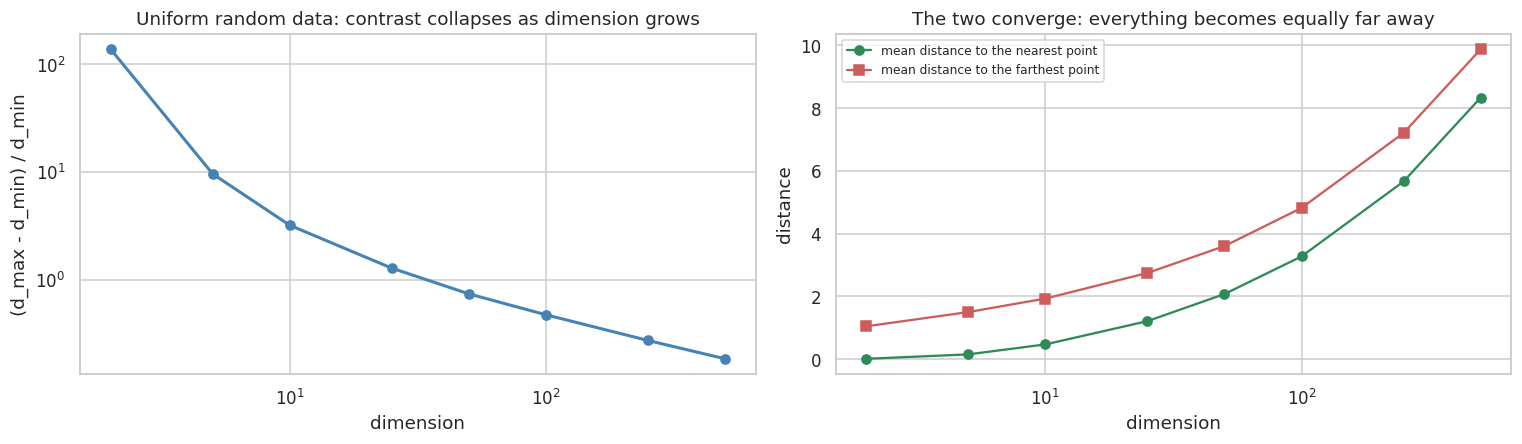

In [61]:
from scipy.spatial.distance import cdist

concentration_rng = np.random.RandomState(RANDOM_STATE)
concentration_rows = []
for dimension in [2, 5, 10, 25, 50, 100, 250, 500]:
    reference = concentration_rng.uniform(size=(2000, dimension))
    queries = concentration_rng.uniform(size=(200, dimension))
    distances = cdist(queries, reference)
    nearest, farthest = distances.min(axis=1), distances.max(axis=1)
    concentration_rows.append({
        'dimension':          dimension,
        'mean_nearest':       nearest.mean(),
        'mean_farthest':      farthest.mean(),
        'relative_contrast':  float(np.mean((farthest - nearest) / nearest)),
    })
concentration = pd.DataFrame(concentration_rows).set_index('dimension')
display(concentration.round(3))

padded_rows = []
concentration_sample = scaled_matrix[concentration_rng.choice(len(scaled_matrix), 3000,
                                                              replace=False)]
for extra in [0, 10, 50, 200, 500]:
    padded = (np.hstack([concentration_sample,
                         concentration_rng.normal(size=(3000, extra))])
              if extra else concentration_sample)
    distances = cdist(padded[:300], padded[300:])
    nearest, farthest = distances.min(axis=1), distances.max(axis=1)
    padded_rows.append({'dimensions': padded.shape[1],
                        'relative_contrast': float(np.mean((farthest - nearest) / nearest))})
padded_contrast = pd.DataFrame(padded_rows).set_index('dimensions')
display(padded_contrast.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].plot(concentration.index, concentration['relative_contrast'], 'o-',
             color='steelblue', lw=2)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('dimension')
axes[0].set_ylabel('(d_max - d_min) / d_min')
axes[0].set_title('Uniform random data: contrast collapses as dimension grows')

axes[1].plot(concentration.index, concentration['mean_nearest'], 'o-', color='seagreen',
             label='mean distance to the nearest point')
axes[1].plot(concentration.index, concentration['mean_farthest'], 's-', color='indianred',
             label='mean distance to the farthest point')
axes[1].set_xscale('log')
axes[1].set_xlabel('dimension')
axes[1].set_ylabel('distance')
axes[1].set_title('The two converge: everything becomes equally far away')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

What the measurement shows.
I use one quantity throughout, the relative contrast (d_max - d_min) / d_min, which says how
much further the farthest point is than the nearest, as a fraction of the nearest distance. In
2 dimensions it is 137.6, so the farthest point is well over a hundred times further away and
"near" and "far" are completely different states. By 10 dimensions it has fallen to 3.2, by 100
to 0.47, and by 500 to 0.185 - at that point the farthest point in the whole reference set is
only about 19 percent further away than the closest one. The second panel shows the mechanism
directly: the nearest and farthest distances both grow, but they grow towards each other.

Why this breaks distance-based anomaly detection.
LOF's score is a ratio of local densities built out of neighbour distances. If all distances
converge to the same value, that ratio converges to 1 for every point, and the score stops
distinguishing anything. The same applies to k-NN distance methods and to DBSCAN, whose eps is
a distance threshold - when all distances are nearly equal, there is no eps that separates
dense from sparse.

There is a second, subtler effect. In high dimensions almost all the volume of a region sits
near its boundary, so every point is close to the edge in some direction. Being extreme in at
least one coordinate becomes the normal condition rather than a rare one, which is the
geometric version of the multiple-comparisons problem from section 5.1.

Why my dataset avoided the worst of it.
At 10 dimensions the relative contrast on the actual diamonds matrix is 24.7, which is
comfortable - distances still mean something. This is why LOF worked so well here, and why that
success does not generalise. Padding the same data to 60 dimensions drops the contrast below 1,
and to 510 dimensions drops it to 0.215. My results are a report from the low-dimensional end,
where distance-based methods are at their best.

7.3  Noise or a genuine anomaly?

The lecture separates two kinds of uncertainty, and that distinction turns out to be exactly
the right tool for this question.

Aleatory uncertainty is the inherent variability of the thing being measured. Diamonds
genuinely vary in size, and a small number of them are genuinely enormous. Nothing is wrong,
nothing can be fixed, and more data would not reduce it. The long right tail of price and carat
in section 2 is aleatory: 3,540 stones beyond the IQR fence, all real.

Epistemic uncertainty is a lack of knowledge, and the lecture lists measurement errors and data
collection errors as its sources. A stone recorded with a depth of zero millimetres is
epistemic: the true value exists, somebody failed to record it, and better collection would
eliminate it entirely.

That distinction is what separates a genuine anomaly from noise here, and it is not a
statistical distinction at all. A genuine anomaly is an observation that really is unusual -
the process produced something rare. Noise is an observation that is unusual only because the
recording failed. Both look identical in the numbers. Only knowledge of the process tells them
apart.

The example the brief asks for

Row 27415: a 5.01 carat, Fair cut, J colour, I1 clarity diamond priced at $18,018. This stone
is flagged as anomalous by Isolation Forest, where it ranks third out of 53,940, and by max |z|.
On any purely statistical reading it is one of the most extreme records in the dataset. It
is the heaviest stone in the file, its price of $18,018 puts it in the most expensive 0.6
percent, and its length of 10.74 mm is the largest x in the dataset. (Its y and z are the
largest of any correctly measured stone; the only larger values anywhere are the 58.90 and
31.80 belonging to the decimal-point errors.)

And it is completely legitimate.
Every internal check passes. Its recorded depth of 65.5 reproduces the formula 100 * 2z / (x +
y) as 65.6, agreeing to within 0.1 of a percentage point. Its x and y differ by 1.9 percent,
exactly as a round brilliant should. Its price is consistent with its weight. It is even
commercially coherent: it is graded Fair cut with I1 clarity and J colour, which is precisely
the trade a cutter makes on a very large piece of rough - you accept poorer proportions and
visible inclusions rather than cut away weight that is worth more than the improvement.

So this record is a true positive as an outlier and a false positive as an error. It is
statistically extreme and factually correct. Any system that hands this stone to a data cleaner
is wasting their time, and a system that automatically removed extreme values would delete the
single most valuable stone in the inventory.

Contrast it with row 27429, a 2.25 carat diamond at $18,034 with x = y = z = 0. Its price is
almost identical to row 27415's, and in a one-dimensional view of price the two are
indistinguishable. One is the best stone in the catalogue; the other is a missing measurement
stored as a number. The difference is invisible to statistics and obvious to a gemmologist.

7.4  The risks of assuming a Gaussian distribution

Section 5.1 tested the assumption and it failed for every measured feature, with a p-value of
essentially zero from D'Agostino's test. The consequences are specific rather than vague.

The threshold stops meaning what it says.
The |z| > 3 rule promises about 0.3 percent of the data. On this dataset it flags 4.36 percent,
fourteen times more. Anyone budgeting review capacity from the textbook figure would be
overwhelmed. The failure is asymmetric, too: it over-flags in the direction of the skew and
under-flags against it, so on a right-skewed variable like price the rule treats ordinary
expensive stones as anomalies while a suspiciously cheap stone has to be far more extreme
before it is noticed.

Anomalies that get incorrectly identified (false positives).
Everything in a heavy tail. On a skewed distribution a Gaussian model places the +3sigma
boundary far too close to the centre, so the thousands of legitimately large and expensive
stones are flagged. Multimodal data is worse: if the data has two populations - and the
lecture's "multi population distribution" slide lists data misalignment, corrupt data and
different groups as reasons this happens - then a single Gaussian puts its mean between the two
modes, and the most typical points of each mode can score as unusual while the genuinely empty
region in the middle scores as normal.

Anomalies that get missed (false negatives).
Three kinds, and they are the dangerous ones.

The first kind is anomalies inside the bulk. A Gaussian model only measures distance from the
mean, so an impossible value that happens to sit near the middle of a feature's range is
invisible. Row 14635, the 1.07 carat stone with z = 1.07 mm, is exactly this: 1.07 mm is an
ordinary number for depth, and no univariate Gaussian rule will ever flag it.

The second kind is anomalies in bounded variables. cut_rank, color_rank and clarity_rank
produced zero points with |z| > 3, because a variable bounded between 0 and 7 cannot reach
three standard deviations. The method is structurally blind to a third of my features.

The third kind is anomalies hidden by inflated variance. The standard deviation is computed
from the same data that contains the anomalies, so a few extreme values enlarge sigma and raise
the threshold for everything else. Section 2 showed the strength of this effect: a single
record moved the correlation between x and y from 0.9749 to 0.9934. Outliers mask each other.

What to do instead, and this notebook demonstrates all of it: use robust estimators such as the
median and MAD, which the lecture lists; work on a transformed scale where the assumption is
closer to true, since log(price) has a skewness of 0.115 against 1.618 raw; or drop the
distributional assumption entirely, as Isolation Forest and LOF do.

7.5  Why a picture after dimensionality reduction can mislead

Section 3 already measured the core problem: the two-dimensional PCA projection carries 64.4
percent of the variance but preserves only 13.5 percent of each stone's twenty nearest
neighbours. Here I measure what that does specifically to anomalies.

The 27 defective records, by the percentile of their 20-neighbour distance:
  in the full 10-dimensional space : 99.96th percentile
  in the 2-D PCA picture           : 81.84th percentile

Defective records that are in the top 1% in 10-D but NOT in the top 1% in 2-D: 17 of 27


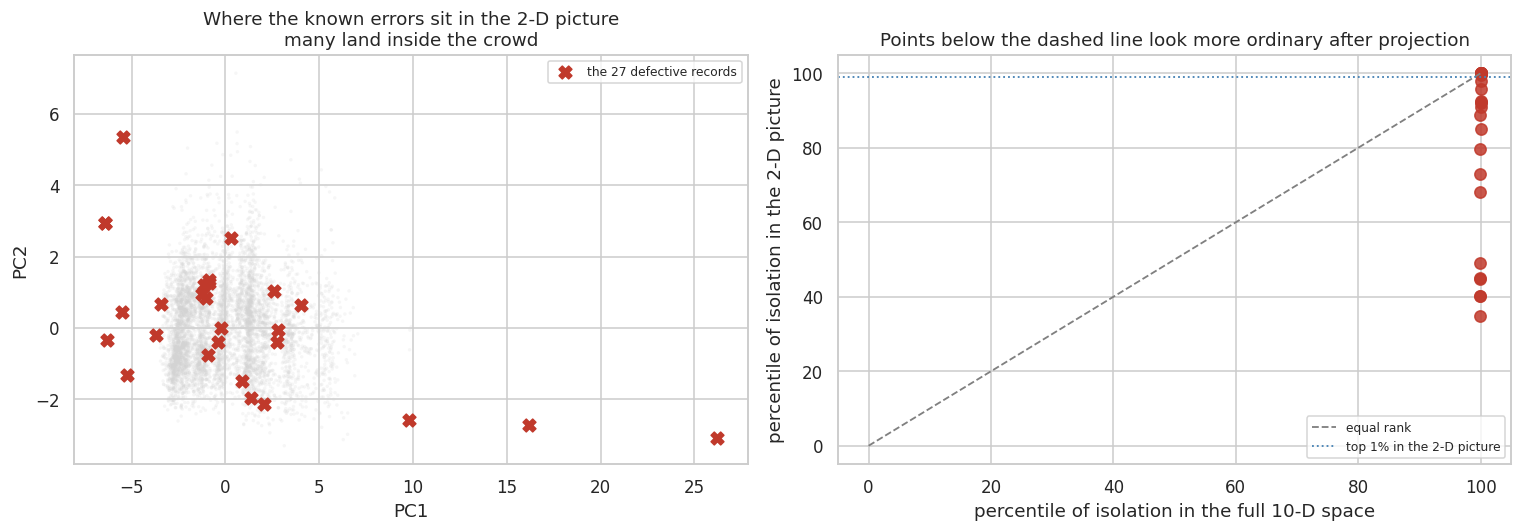

In [62]:
from scipy.spatial import cKDTree

def mean_neighbour_distance(points, k=20):
    tree = cKDTree(points)
    distances, _ = tree.query(points, k=k + 1)
    return distances[:, 1:].mean(axis=1)

two_dimensional = scores[:, :2]
distance_full = mean_neighbour_distance(scaled_matrix)
distance_projected = mean_neighbour_distance(two_dimensional)

rank_full = pd.Series(distance_full).rank(pct=True)
rank_projected = pd.Series(distance_projected).rank(pct=True)

print('The 27 defective records, by the percentile of their 20-neighbour distance:')
print(f'  in the full 10-dimensional space : {100 * rank_full[defective_index].mean():.2f}th percentile')
print(f'  in the 2-D PCA picture           : {100 * rank_projected[defective_index].mean():.2f}th percentile')

hidden_by_projection = [i for i in defective_index
                        if rank_projected[i] < 0.99 <= rank_full[i]]
print(f'\nDefective records that are in the top 1% in 10-D but NOT in the top 1% in 2-D: '
      f'{len(hidden_by_projection)} of {len(defective_index)}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(scores[plot_sample, 0], scores[plot_sample, 1], s=5, alpha=0.2,
                color='lightgrey', edgecolors='none')
axes[0].scatter(scores[defective_index, 0], scores[defective_index, 1], s=70,
                color='#c0392b', marker='X', label='the 27 defective records')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Where the known errors sit in the 2-D picture\nmany land inside the crowd')
axes[0].legend(fontsize=8)

axes[1].scatter(rank_full[defective_index] * 100, rank_projected[defective_index] * 100,
                s=55, color='#c0392b', alpha=0.85)
axes[1].plot([0, 100], [0, 100], color='grey', ls='--', lw=1.2, label='equal rank')
axes[1].axhline(99, color='steelblue', ls=':', lw=1.2, label='top 1% in the 2-D picture')
axes[1].set_xlabel('percentile of isolation in the full 10-D space')
axes[1].set_ylabel('percentile of isolation in the 2-D picture')
axes[1].set_title('Points below the dashed line look more ordinary after projection')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

What the measurement shows.
In the full ten-dimensional space the 27 defective records sit at the 99.96th percentile of
isolation - they are almost the most isolated points in the dataset. In the two-dimensional PCA
picture the same 27 records fall to roughly the 82nd percentile, which is unremarkable. Most of
them stop being in the top one percent at all. A reader shown only the projection would
conclude that these records are ordinary.

Why projection hides anomalies.
PCA keeps the directions of largest variance and discards the rest. But an anomaly is very
often anomalous in precisely a low-variance direction, because low-variance directions are
where the tight relationships live. The relationship "z is about 0.6 times x" holds so
consistently across 53,940 stones that it is a direction of almost no variance - and it is
exactly the direction in which row 14635 is broken. PCA discards that direction first. The
stones that violate the strongest rules in the data are the ones the projection is most likely
to hide. This is the same insight PCA reconstruction error exploits in section 5.4, seen from
the other side: the discarded subspace is where the errors live, which is why looking at the
residual works and why looking at the picture does not.

Projection can also invent structure.
Two points far apart in 10-D can land on top of each other in 2-D, since a projection can only
collapse distances, never expand them. So apparent clusters in a PCA plot may be several
distinct groups overlapping, and an apparent gap is real while an apparent crowd may not be.
Non-linear methods like t-SNE and UMAP are worse in a different way: their parameters strongly
affect the apparent cluster sizes and separations, and distances between clusters in a t-SNE
plot are not meaningful at all.

The practical rule I drew from this.
Use projections to communicate and to form hypotheses, never to decide. Every anomaly score in
section 5 was computed in the full ten-dimensional space, and the projections were used only to
display the results. Running LOF on the 2-D scores instead would have missed most of the errors
it actually found.

7.6  Ethical considerations

The real-world consequences of false alarms

A false alarm is cheap once and expensive repeatedly. In this dataset Isolation Forest's list
of 540 stones consists almost entirely of large, genuine, correctly recorded diamonds. A buyer
asked to check that list finds nothing wrong on the first day, nothing on the second, and by
the second week has stopped reading it. This is alarm fatigue, and it is the main way anomaly
detection systems fail in practice: not by breaking, but by being switched off in the mind of
the person receiving the output.

The arithmetic is worth stating plainly, because it is unintuitive. Suppose a system is applied
to a million transactions of which 100 are fraudulent, and it catches 99 percent of fraud with
a 1 percent false alarm rate. It produces 99 true alarms and about 10,000 false ones, so fewer
than 1 percent of the alerts are real. A reviewer who treats every alert seriously is wasting
99 percent of their time, and a reviewer who does not is not reviewing. When anomalies are
rare, even an excellent false alarm rate produces a useless alert list. Too many false alarms
make a system ineffective long before they make it inaccurate.

Surveillance

The benefits are real. Detecting unusual patterns can find a failing bridge sensor, a
contaminated water supply, or a coordinated fraud ring no individual transaction would reveal.

The risks are structural rather than accidental. First, anomaly detection defines deviation
from the majority, so being unusual becomes the trigger - and in a surveillance context,
"unusual" maps onto minority behaviour: an unusual work schedule, an unusual travel pattern, an
unusual religious observance. The system does not know the difference between suspicious and
merely uncommon, any more than my methods could tell the largest diamond from the broken
record. Second, surveillance systems produce feedback loops: flagged people are watched more,
watching generates more data, and more data generates more flags. Third, the cost of a false
positive is paid by the person flagged and the benefit is collected by the operator, so the
people deciding the threshold are not the people who bear the consequences of it.

Medical applications

Both errors are serious and they are not symmetric.

Classifying a healthy patient as anomalous causes real harm: further tests that carry their own
risks, weeks of fear, sometimes treatment for a condition that would never have caused
symptoms. Over-diagnosis is a documented consequence of screening programmes, not a
hypothetical one.

Classifying a sick patient as normal is worse in the individual case: a missed diagnosis delays
treatment and a false reassurance may stop the patient seeking help at all.

There is a subtler problem that this notebook illustrates directly. A model of "normal" built
on a population that is mostly one group encodes that group as the standard. Physiological
reference ranges have historically been derived from narrow samples, and patients outside them
are then flagged as abnormal for being unrepresented rather than unwell. My Z-score analysis
failed on the bounded grade columns for a structurally similar reason: the method assumed a
shape the data did not have and was then confidently wrong.

Cybersecurity

Here the asymmetry runs the other way from the diamond case, and the two errors compare as
follows.

Missing a genuine attack can be unbounded. An intrusion that goes undetected gives an attacker
time to move laterally, escalate privileges and exfiltrate data, and the lecture's point about
reducing dwell time is exactly this: the cost grows with the time undetected, so a missed
detection is not a single event but a compounding one.

Flagging legitimate activity as malicious has a bounded direct cost - an analyst's time, a
blocked login, a frustrated employee - but an unbounded indirect one, because it is the route
to alarm fatigue. A team that receives 500 alerts a day of which 3 are real will eventually
miss the 3. So the two errors are not independent: raising sensitivity to reduce false
negatives increases false positives, which degrades the human response, which increases false
negatives again.

This is why the output of an anomaly detector should be a ranking with a threshold chosen from
an explicit cost ratio, rather than a binary label. It is also why I reported my methods at a
fixed budget of 539 stones and discussed what each one spent that budget on.

Privacy, bias, fairness, and what "abnormal" does to people

Privacy.
Anomaly detection needs the individual record; you cannot ask whether one person is unusual
from aggregates alone. So these systems drive collection of granular personal data, and they
are re-identifying by nature: a person who is an outlier in the data is a person who is easy to
pick out of it.

Bias.
The model learns normal from the training data. If a group is under-represented, its members
are more likely to be flagged - not because anything is wrong with them, but because there were
fewer of them. This is a mathematical property, not an implementation bug, and it is precisely
the LOF k-sensitivity result from section 5.3 seen from the other side: a pattern occurring
fewer than k times looks anomalous, and a pattern occurring often enough looks normal even when
it is wrong. A systematic error repeated at scale becomes the new normal, while a minority that
is perfectly correct gets flagged.

Fairness.
Because the rule is "unlike the majority", the burden of being flagged falls systematically on
minorities, and it does so while looking neutral. There is no protected attribute in my ten
columns and the method still concentrated its attention on a specific, identifiable
subpopulation. Removing the sensitive attribute does not remove the effect, since correlated
features reconstruct it.

The consequences of the label itself.
Being called abnormal by a system is different from being called abnormal by a person. It
carries an appearance of objectivity that is hard to argue with, it is rarely explainable - I
could not say why LOF gave a stone a score of 15.98 beyond "its neighbourhood was sparse" - and
it tends to persist and propagate between systems. A person denied a loan, flagged at a border,
or referred for investigation on the basis of an anomaly score often cannot see the score,
cannot contest the model, and cannot know which features drove it.

My concrete conclusion from this notebook is narrow but firm. I have five defensible methods
that disagree with each other on the same data, whose outputs shift completely if I rescale a
column, and that cannot distinguish the best diamond in the catalogue from a missing
measurement. Given that, an anomaly score should be treated as a prompt for a human to look,
and never as a finding in itself. Where the subject of the score is a person rather than a
diamond, that distinction stops being a methodological preference and becomes an ethical
requirement.

8  Final Visualization Dashboard (bonus)

A single panel that brings together the PCA view, the clustering, the anomaly detection and the
correlation structure, followed by a pairplot and a small interactive explorer.

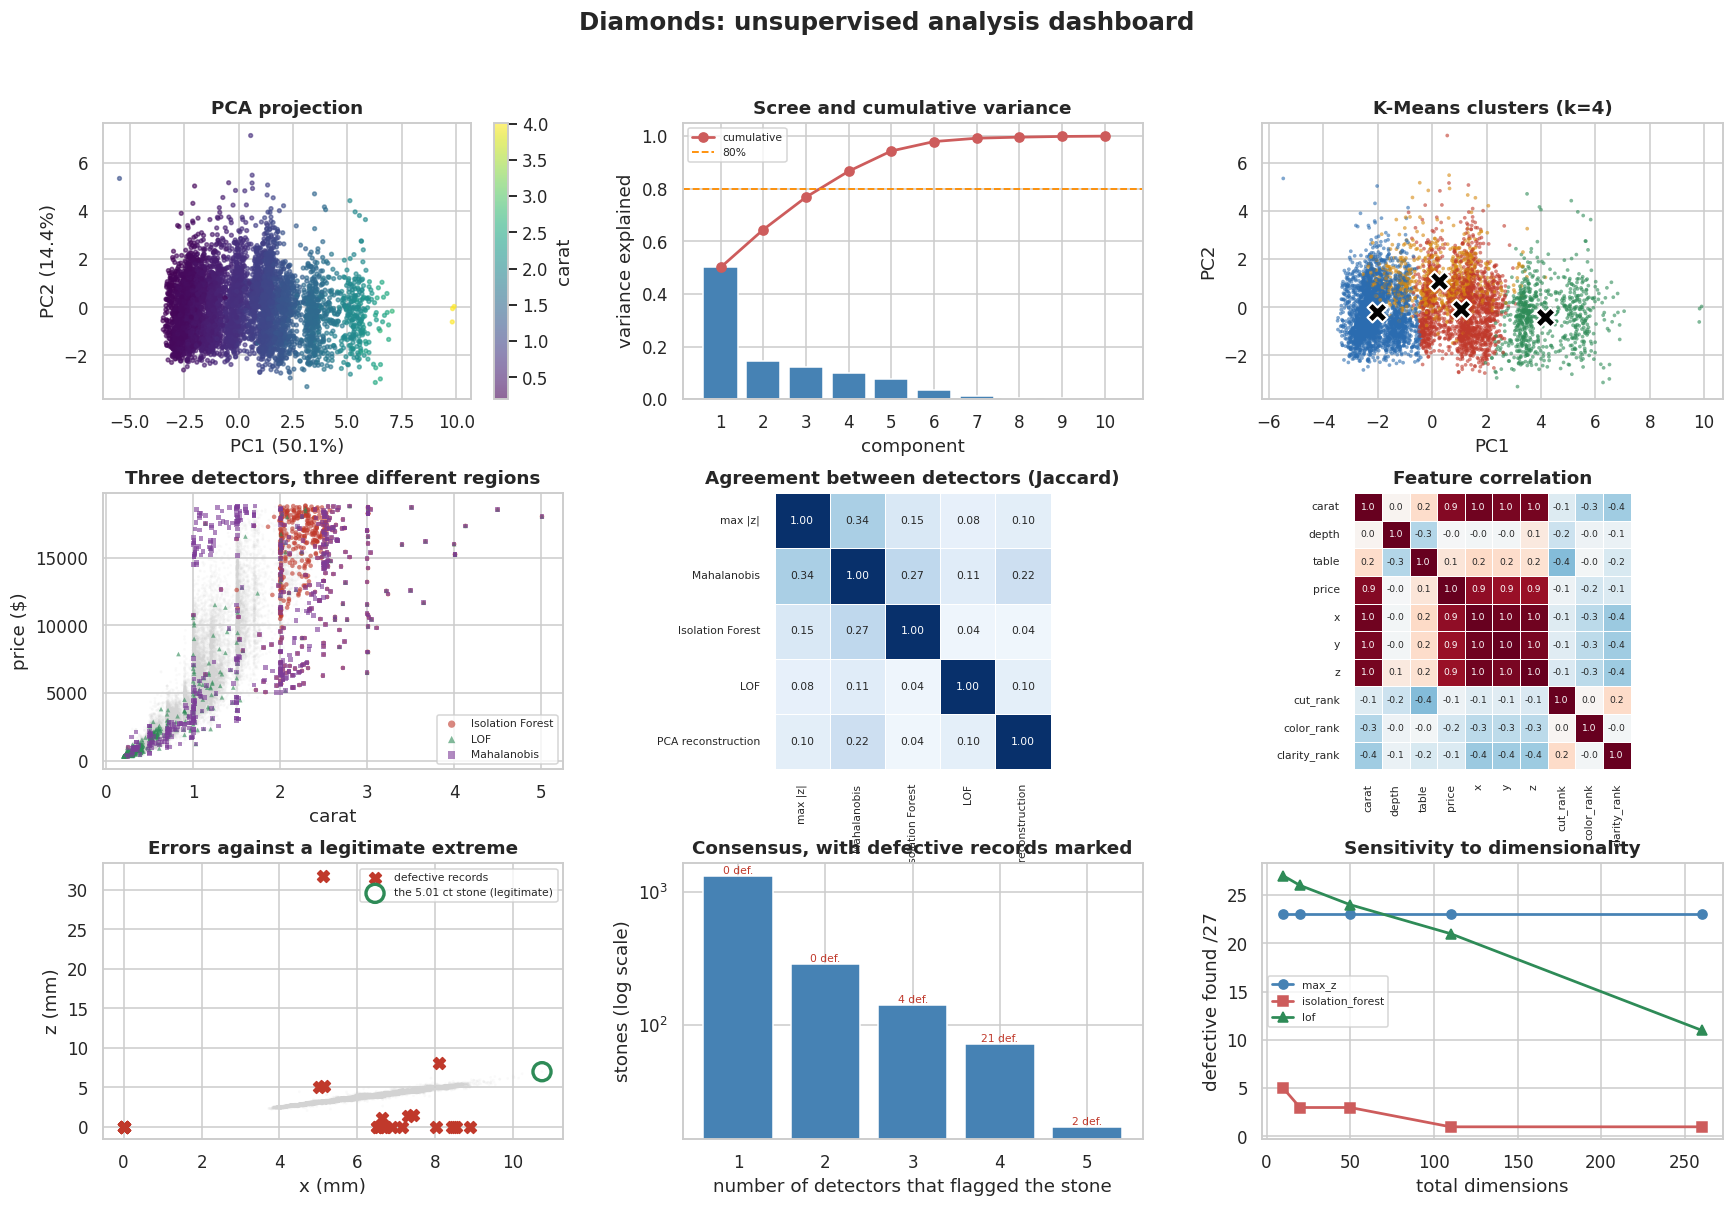

In [63]:
fig = plt.figure(figsize=(19, 12))
grid = fig.add_gridspec(3, 3, hspace=0.34, wspace=0.26)

ax = fig.add_subplot(grid[0, 0])
picture = ax.scatter(scores[plot_sample, 0], scores[plot_sample, 1],
                     c=diamonds_df['carat'].to_numpy()[plot_sample], s=6, alpha=0.6,
                     cmap='viridis')
fig.colorbar(picture, ax=ax, label='carat')
ax.set_xlabel(f'PC1 ({explained_ratio[0] * 100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_ratio[1] * 100:.1f}%)')
ax.set_title('PCA projection', fontweight='bold')

ax = fig.add_subplot(grid[0, 1])
component_axis = np.arange(1, len(explained_ratio) + 1)
ax.bar(component_axis, explained_ratio, color='steelblue', edgecolor='white')
ax.plot(component_axis, cumulative_ratio, 'o-', color='indianred', lw=1.8,
        label='cumulative')
ax.axhline(0.8, color='darkorange', ls='--', lw=1.2, label='80%')
ax.set_xticks(component_axis)
ax.set_xlabel('component')
ax.set_ylabel('variance explained')
ax.set_title('Scree and cumulative variance', fontweight='bold')
ax.legend(fontsize=7)

ax = fig.add_subplot(grid[0, 2])
ax.scatter(scores[plot_sample, 0], scores[plot_sample, 1],
           c=palette[kmeans_model.labels_[plot_sample]], s=6, alpha=0.6, edgecolors='none')
ax.scatter(centroids_in_pc[:, 0], centroids_in_pc[:, 1], marker='X', s=170, c='black',
           edgecolors='white', linewidths=1.4, zorder=5)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means clusters (k={CHOSEN_K})', fontweight='bold')

ax = fig.add_subplot(grid[1, 0])
ax.scatter(diamonds_df['carat'], diamonds_df['price'], s=3, alpha=0.1, color='lightgrey',
           edgecolors='none')
for name, colour, marker in [('Isolation Forest', '#c0392b', 'o'),
                             ('LOF', '#2e8b57', '^'),
                             ('Mahalanobis', '#7d3c98', 's')]:
    mask = method_flags[name]
    ax.scatter(diamonds_df.loc[mask, 'carat'], diamonds_df.loc[mask, 'price'],
               s=9, alpha=0.6, color=colour, marker=marker, label=name, edgecolors='none')
ax.set_xlabel('carat')
ax.set_ylabel('price ($)')
ax.set_title('Three detectors, three different regions', fontweight='bold')
ax.legend(fontsize=7, markerscale=1.6)

ax = fig.add_subplot(grid[1, 1])
sns.heatmap(jaccard_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            square=True, linewidths=0.5, ax=ax, cbar=False,
            annot_kws={'size': 7})
ax.set_title('Agreement between detectors (Jaccard)', fontweight='bold')
ax.tick_params(axis='both', labelsize=7)

ax = fig.add_subplot(grid[1, 2])
sns.heatmap(correlation, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, ax=ax, cbar=False, annot=True, fmt='.1f',
            annot_kws={'size': 6})
ax.set_title('Feature correlation', fontweight='bold')
ax.tick_params(axis='both', labelsize=7)

ax = fig.add_subplot(grid[2, 0])
ax.scatter(diamonds_df['x'], diamonds_df['z'], s=3, alpha=0.1, color='lightgrey',
           edgecolors='none')
ax.scatter(diamonds_df.loc[defective_index, 'x'], diamonds_df.loc[defective_index, 'z'],
           s=60, color='#c0392b', marker='X', label='defective records', zorder=5)
biggest = diamonds_df['carat'].idxmax()
ax.scatter(diamonds_df.loc[biggest, 'x'], diamonds_df.loc[biggest, 'z'], s=140,
           facecolors='none', edgecolors='#2e8b57', linewidths=2.2,
           label='the 5.01 ct stone (legitimate)', zorder=6)
ax.set_xlabel('x (mm)')
ax.set_ylabel('z (mm)')
ax.set_title('Errors against a legitimate extreme', fontweight='bold')
ax.legend(fontsize=7)

ax = fig.add_subplot(grid[2, 1])
vote_summary = pd.Series(vote_count[vote_count > 0]).value_counts().sort_index()
bars = ax.bar(vote_summary.index, vote_summary.to_numpy(), color='steelblue',
              edgecolor='white')
for n_methods in vote_summary.index:
    caught = len(defective_set & set(np.where(vote_count == n_methods)[0]))
    ax.text(n_methods, vote_summary[n_methods], f'{caught} def.', ha='center',
            va='bottom', fontsize=7, color='#c0392b')
ax.set_yscale('log')
ax.set_xlabel('number of detectors that flagged the stone')
ax.set_ylabel('stones (log scale)')
ax.set_title('Consensus, with defective records marked', fontweight='bold')

ax = fig.add_subplot(grid[2, 2])
for column, colour, marker in [('max_z', 'steelblue', 'o'),
                               ('isolation_forest', 'indianred', 's'),
                               ('lof', 'seagreen', '^')]:
    ax.plot(dimensionality.index, dimensionality[column], marker + '-', color=colour,
            lw=1.8, label=column)
ax.set_xlabel('total dimensions')
ax.set_ylabel(f'defective found /{len(defective_set)}')
ax.set_title('Sensitivity to dimensionality', fontweight='bold')
ax.legend(fontsize=7)

fig.suptitle('Diamonds: unsupervised analysis dashboard', fontsize=16, fontweight='bold',
             y=0.965)
plt.show()

This cell draws the pairplot of the measured features with the defective records marked.

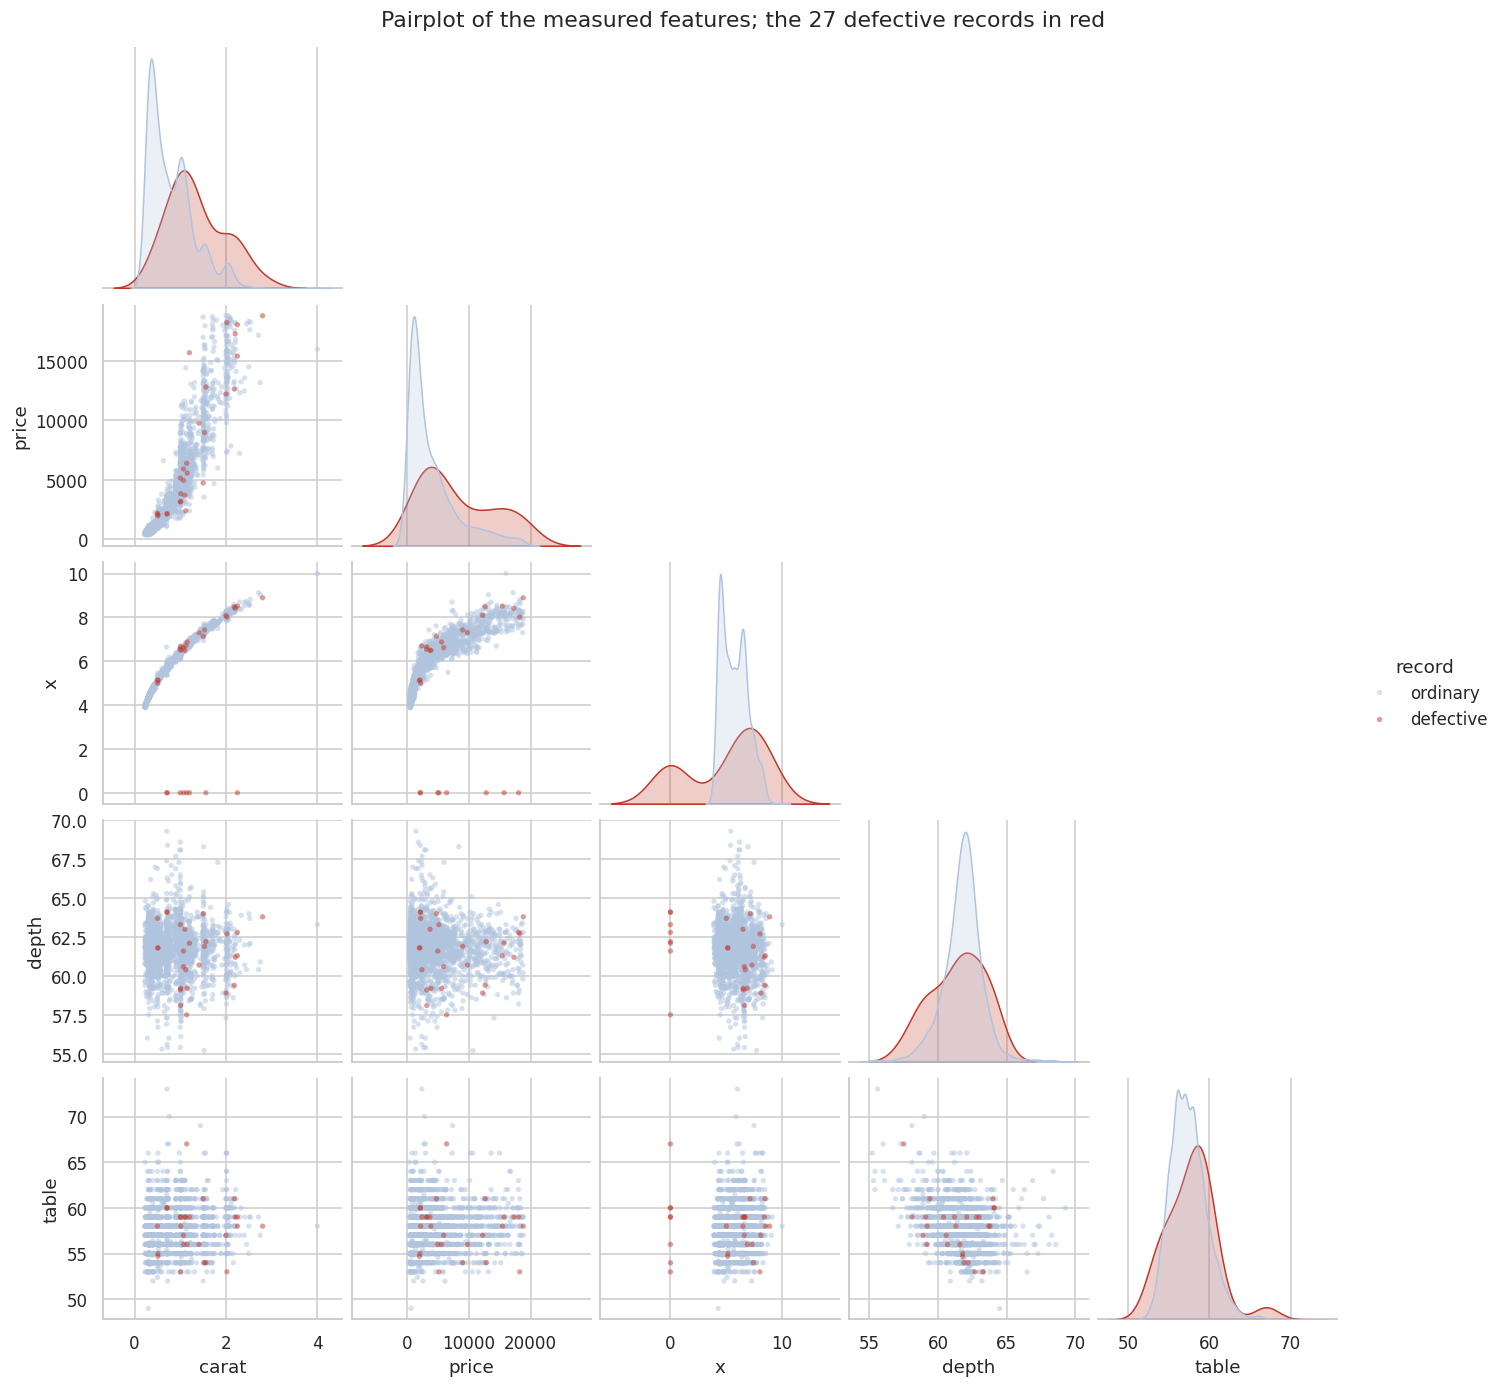

In [64]:
pairplot_sample = np.random.RandomState(RANDOM_STATE).choice(len(diamonds_df), 2500,
                                                             replace=False)
pairplot_features = ['carat', 'price', 'x', 'depth', 'table']

background = diamonds_df.loc[pairplot_sample, pairplot_features].copy()
background['record'] = 'ordinary'
flagged_records = diamonds_df.loc[defective_index, pairplot_features].copy()
flagged_records['record'] = 'defective'
pairplot_data = pd.concat([background, flagged_records])

grid = sns.pairplot(pairplot_data, hue='record', corner=True,
                    palette={'ordinary': '#b0c4de', 'defective': '#c0392b'},
                    plot_kws={'s': 12, 'alpha': 0.5, 'edgecolor': 'none'},
                    diag_kws={'common_norm': False})
grid.figure.suptitle('Pairplot of the measured features; the 27 defective records in red',
                     y=1.01)
plt.show()

This cell builds an interactive explorer for the anomalies. If ipywidgets is available it
renders sliders, and otherwise the same function can be called with arguments.

In [65]:
def explore_anomalies(method='LOF', top_n=15, min_carat=0.0, max_carat=5.1):
    score_vector = method_scores[method]
    within_range = ((diamonds_df['carat'] >= min_carat)
                    & (diamonds_df['carat'] <= max_carat)).to_numpy()
    eligible = np.where(within_range)[0]
    if len(eligible) == 0:
        print('No stones in that carat range.')
        return
    ranked = eligible[np.argsort(score_vector[eligible])[-top_n:][::-1]]

    table = diamonds_df.loc[ranked, ['carat', 'cut', 'color', 'clarity', 'price',
                                     'depth', 'table', 'x', 'y', 'z']].copy()
    table['score'] = np.round(score_vector[ranked], 3)
    table['defective'] = ['YES' if i in defective_set else '-' for i in ranked]

    print(f'{method}: top {top_n} stones with carat between {min_carat} and {max_carat}')
    print(f'{sum(1 for i in ranked if i in defective_set)} of them are known defective records')
    display(table)

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.scatter(scores[plot_sample, 0], scores[plot_sample, 1], s=5, alpha=0.18,
               color='lightgrey', edgecolors='none')
    ax.scatter(scores[ranked, 0], scores[ranked, 1], s=80, color='#c0392b', marker='X',
               zorder=5)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Where the top {top_n} {method} stones sit in the projection')
    plt.tight_layout()
    plt.show()

try:
    import ipywidgets as widgets
    from IPython.display import display as show_widget
    show_widget(widgets.interactive(
        explore_anomalies,
        method=widgets.Dropdown(options=list(method_scores), value='LOF', description='method'),
        top_n=widgets.IntSlider(value=15, min=5, max=40, step=5, description='top n'),
        min_carat=widgets.FloatSlider(value=0.0, min=0.0, max=5.0, step=0.1, description='min ct'),
        max_carat=widgets.FloatSlider(value=5.1, min=0.2, max=5.1, step=0.1, description='max ct'),
    ))
    print('Sliders active. Change the method or the carat range to explore.')
except ImportError:
    print('ipywidgets not installed, calling the function directly instead.')
    explore_anomalies(method='LOF', top_n=15)

interactive(children=(Dropdown(description='method', index=3, options=('max |z|', 'Mahalanobis', 'Isolation Fo…

Sliders active. Change the method or the carat range to explore.


This cell shows two fixed views from the explorer, so that the contrast is visible even when
the widgets are not rendered.

Isolation Forest: top 8 stones with carat between 0.0 and 5.1
0 of them are known defective records


,carat,cut,color,clarity,price,depth,table,x,y,z,score,defective
26431,3.40,Fair,D,I1,15964,66.8,52.0,9.42,9.34,6.27,0.733,-
27630,4.50,Fair,J,I1,18531,65.8,58.0,10.23,10.16,6.72,0.723,-
27415,5.01,Fair,J,I1,18018,65.5,59.0,10.74,10.54,6.98,0.718,-
23644,3.65,Fair,H,I1,11668,67.1,53.0,9.53,9.48,6.38,0.717,-
27649,3.01,Good,H,SI2,18593,57.6,64.0,9.44,9.38,5.42,0.713,-
22831,3.00,Good,I,I1,10863,57.0,64.0,9.38,9.31,5.33,0.710,-
23539,3.00,Good,E,I1,11548,64.2,65.0,9.08,8.96,5.79,0.707,-
27130,4.13,Fair,H,I1,17329,64.8,61.0,10.00,9.85,6.43,0.707,-


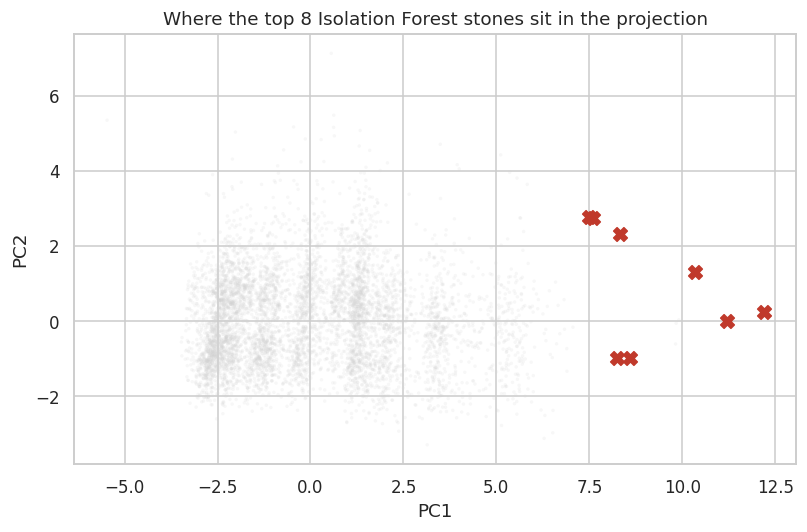

LOF: top 8 stones with carat between 0.0 and 5.1
8 of them are known defective records


,carat,cut,color,clarity,price,depth,table,x,y,z,score,defective
24067,2.00,Premium,H,SI2,12210,58.9,57.0,8.09,58.90,8.06,15.983,YES
48410,0.51,Very Good,E,VS1,1970,61.8,54.7,5.12,5.15,31.80,14.044,YES
49189,0.51,Ideal,E,VS1,2075,61.8,55.0,5.15,31.80,5.12,12.125,YES
11182,1.07,Ideal,F,SI2,4954,61.6,56.0,0.00,6.62,0.00,9.509,YES
24520,1.56,Ideal,G,VS2,12800,62.2,54.0,0.00,0.00,0.00,8.188,YES
26243,1.20,Premium,D,VVS1,15686,62.1,59.0,0.00,0.00,0.00,7.159,YES
27429,2.25,Premium,H,SI2,18034,62.8,59.0,0.00,0.00,0.00,6.979,YES
11963,1.00,Very Good,H,VS2,5139,63.3,53.0,0.00,0.00,0.00,6.357,YES


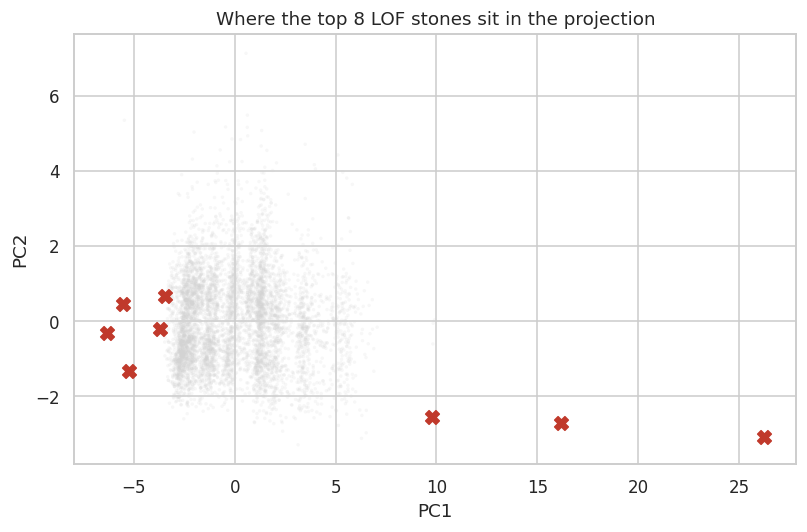

In [66]:
explore_anomalies(method='Isolation Forest', top_n=8)
explore_anomalies(method='LOF', top_n=8)

Summary

I analysed 53,940 diamonds with no labels of any kind, using clustering, PCA and five anomaly
detection methods. The findings are these.

The data has one dominant direction and little else.
Five of the ten features - carat, x, y, z and price - are one measurement recorded five times,
correlated above 0.86 internally, and PC1 collapses them into a single "size and value" axis
explaining 50.1 percent of the variance. The remaining features are close to independent, which
is why four components are needed for 80 percent and six for 95 percent. Clustering the feature
space confirmed this from the other direction and identified exactly which columns are
disposable.

There are no natural clusters.
Every criterion pointed at k = 2 with a silhouette of 0.32, the elbow was smooth, DBSCAN went
from 142 clusters to one without a stable plateau, and refitting K-Means on half-samples moved
real boundaries. The k = 4 partition is a usable commercial segmentation - three price tiers
plus a genuinely distinguishable group of badly cut stones - but it is not discovered
structure.

DBSCAN's rejects were a better error detector than one of the anomaly methods. The 5,803 stones
it labelled noise contained all 27 physically defective records, which no amount of tuning got
Isolation Forest to do.

The five anomaly detection methods answered different questions.
Isolation Forest found the biggest, most expensive stones, 86.9 percent of them above 2 carats,
and caught 2 of the 27 physically defective records. LOF found the defective records, all 27,
while flagging stones of entirely average size. Mahalanobis and PCA reconstruction, which are
two views of the same covariance geometry, also found all 27. Univariate Z-scores found 23 and
were structurally blind to the three bounded grade columns. Their pairwise agreement was mostly
below a Jaccard of 0.2.

The most useful thing I learned is that these disagreements were not noise. Each method has a
definition of normal built into it, and on data with no labels that definition is the answer
rather than an input to it. The 5.01 carat diamond and the record with all three dimensions
equal to zero are both extreme, and no method in this notebook could tell me that one is the
finest stone in the catalogue and the other is a missing measurement. That separation required
knowing what a diamond is, and it came from outside the data entirely.